In [ ]:
# CELL 1 — Restore and verify all four baseline models.
# No training. Does not recreate or change experimental splits.

from pathlib import Path, PurePosixPath
import hashlib
import json
import os
import shutil
import tempfile
import zipfile

INPUT = Path("/kaggle/input")
ROOT = Path("/kaggle/working/wheat_rice_journal")
ROOT.parent.mkdir(parents=True, exist_ok=True)

RUNS = [
    f"{crop}_{model}_baseline_seed42"
    for crop in ("wheat", "rice")
    for model in ("efficientnet_b0", "mobilenet_v2")
]

REQUIRED = [
    "splits/split_config.json",
    "data_audit/class_maps.json",
]
for run in RUNS:
    REQUIRED.extend(
        f"runs/{run}/{name}"
        for name in (
            "best_model.pt",
            "latest_checkpoint.pt",
            "config.json",
            "validation_summary.json",
            "training_log.csv",
        )
    )


def file_hash(path):
    h = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b""):
            h.update(block)
    return h.hexdigest()


def restore_verified_backup():
    print("CELL 1 STARTED — locating verified backup...", flush=True)
    source = None
    manifest_path = None
    staging = None
    prefix = "wheat_rice_journal/"

    try:
        # Locate an already-extracted backup.
        for candidate_manifest in sorted(INPUT.rglob("BACKUP_MANIFEST.json")):
            candidate = candidate_manifest.parent / "wheat_rice_journal"
            if all((candidate / name).is_file() for name in REQUIRED):
                source = candidate
                manifest_path = candidate_manifest
                break

        # Otherwise locate and extract the matching ZIP.
        if source is None:
            for archive_path in sorted(INPUT.rglob("*.zip")):
                with zipfile.ZipFile(archive_path) as archive:
                    names = set(archive.namelist())
                    if (
                        "BACKUP_MANIFEST.json" not in names
                        or not all(prefix + name in names for name in REQUIRED)
                    ):
                        continue

                    print("Found backup ZIP:", archive_path, flush=True)
                    staging = tempfile.TemporaryDirectory(
                        prefix="four_model_restore_", dir="/kaggle/working"
                    )
                    stage_root = Path(staging.name)

                    for member in archive.infolist():
                        if member.is_dir():
                            continue
                        if not (
                            member.filename.startswith(prefix)
                            or member.filename == "BACKUP_MANIFEST.json"
                        ):
                            continue

                        relative = PurePosixPath(member.filename)
                        if relative.is_absolute() or ".." in relative.parts:
                            raise RuntimeError("Invalid archive path.")

                        target = stage_root.joinpath(*relative.parts)
                        target.parent.mkdir(parents=True, exist_ok=True)
                        with archive.open(member) as src, target.open("wb") as dst:
                            shutil.copyfileobj(src, dst)

                    source = stage_root / "wheat_rice_journal"
                    manifest_path = stage_root / "BACKUP_MANIFEST.json"
                    break

        if source is None:
            raise FileNotFoundError(
                "Complete four-model backup with BACKUP_MANIFEST.json "
                "not found in attached inputs."
            )

        print("Backup located:", source, flush=True)
        manifest = json.loads(manifest_path.read_text())
        entries = manifest.get("sha256", {})

        if not all(prefix + name in entries for name in REQUIRED):
            raise RuntimeError("Backup manifest is incomplete.")

        print("Verifying all backup files...", flush=True)
        verified = {}

        for member, expected in entries.items():
            relative = PurePosixPath(member)
            if (
                relative.is_absolute()
                or ".." in relative.parts
                or len(relative.parts) < 2
                or relative.parts[0] != "wheat_rice_journal"
            ):
                raise RuntimeError(f"Invalid manifest entry: {member}")

            local_path = Path(*relative.parts[1:])
            source_file = source / local_path
            if not source_file.is_file() or file_hash(source_file) != expected:
                raise RuntimeError(f"Backup hash mismatch: {member}")
            verified[local_path] = expected

        config = json.loads(
            (source / "splits" / "split_config.json").read_text()
        )
        hashes = config.get("split_sha256", {})
        expected_splits = {
            f"{crop}_{part}.csv"
            for crop in ("wheat", "rice")
            for part in ("train", "validation", "test")
        }

        if not expected_splits.issubset(hashes):
            raise RuntimeError("Split configuration incomplete.")

        for name, expected in hashes.items():
            path = source / "splits" / name
            if not path.is_file() or file_hash(path) != expected:
                raise RuntimeError(f"Split verification failed: {name}")

        maps = json.loads(
            (source / "data_audit" / "class_maps.json").read_text()
        )
        for run in RUNS:
            crop = run.split("_")[0]
            run_config = json.loads(
                (source / "runs" / run / "config.json").read_text()
            )
            if (
                run_config.get("split_sha256") != hashes
                or run_config.get("class_map") != maps[crop]
            ):
                raise RuntimeError(f"Model configuration mismatch: {run}")

        # Stop before copying if an existing destination file differs.
        for relative, expected in verified.items():
            target = ROOT / relative
            if target.exists() and (
                not target.is_file() or file_hash(target) != expected
            ):
                raise RuntimeError(
                    f"Existing file differs: {relative}. Nothing overwritten."
                )

        restored = 0
        for relative, expected in verified.items():
            target = ROOT / relative
            if target.is_file():
                continue

            target.parent.mkdir(parents=True, exist_ok=True)
            temporary = target.with_name(target.name + ".restore_tmp")
            shutil.copyfile(source / relative, temporary)
            if file_hash(temporary) != expected:
                raise RuntimeError(f"Copy verification failed: {relative}")
            os.replace(temporary, target)
            restored += 1

        print(f"\nRESTORE COMPLETE — {restored} files restored.")
        print("All backup hashes and six split hashes verified.")

        for run in RUNS:
            summary = json.loads(
                (ROOT / "runs" / run / "validation_summary.json").read_text()
            )
            print(
                f"{run}: PRESENT | "
                f"validation macro-F1={summary['val_macro_f1']:.6f}"
            )

        import torch
        if not torch.cuda.is_available():
            raise RuntimeError(
                "Files restored, but GPU unavailable. "
                "Select a GPU accelerator before training."
            )

        print("GPU:", torch.cuda.get_device_name(0))
        print("CELL 1 COMPLETE — READY FOR DEGRADATION TRAINING")

    finally:
        if staging is not None:
            staging.cleanup()


restore_verified_backup()

In [ ]:
# CELL 2 — Degradation-aware EfficientNet-B0 + verified backup
# Requires Cell 1. Trains wheat, then rice.
# Baseline models and fixed splits are preserved.
# No test-set evaluation.

print("CELL 2 STARTED", flush=True)

from pathlib import Path
from io import BytesIO
import gc
import hashlib
import json
import os
import random
import socket
import time
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from IPython.display import display

ROOT = Path("/kaggle/working/wheat_rice_journal")
BACKUP = ROOT.parent / "wheat_rice_with_degradation_verified.zip"

SEED = 42
EPOCHS = 15
PATIENCE = 4
BATCH_SIZE = 32
WORKERS = 2
LR = 3e-4
WEIGHT_DECAY = 1e-4

if not torch.cuda.is_available():
    raise RuntimeError("GPU unavailable.")
DEVICE = torch.device("cuda:0")


def digest(path):
    h = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b""):
            h.update(block)
    return h.hexdigest()


def save_json(value, path):
    path = Path(path)
    temp = path.with_name(path.name + ".tmp")
    temp.write_text(json.dumps(value, indent=2))
    os.replace(temp, path)


def save_csv(value, path):
    path = Path(path)
    temp = path.with_name(path.name + ".tmp")
    pd.DataFrame(value).to_csv(temp, index=False)
    os.replace(temp, path)


def save_torch(value, path):
    path = Path(path)
    temp = path.with_name(path.name + ".tmp")
    torch.save(value, temp)
    os.replace(temp, path)


def cpu_state(model):
    return {
        k: v.detach().cpu().clone()
        for k, v in model.state_dict().items()
    }


def seed_all(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


def seed_worker(worker_id):
    seed = torch.initial_seed() % (2**32)
    random.seed(seed)
    np.random.seed(seed)


def backup(stage):
    print(f"Creating backup: {stage}", flush=True)
    temp = BACKUP.with_suffix(".zip.tmp")
    manifest = {}
    with zipfile.ZipFile(
        temp, "w", compression=zipfile.ZIP_DEFLATED, compresslevel=1
    ) as archive:
        for path in sorted(ROOT.rglob("*")):
            if not path.is_file() or path.name.endswith(".tmp"):
                continue
            name = path.relative_to(ROOT.parent).as_posix()
            manifest[name] = digest(path)
            archive.write(path, name)
        archive.writestr(
            "BACKUP_MANIFEST.json",
            json.dumps({"stage": stage, "sha256": manifest}, indent=2)
        )

    with zipfile.ZipFile(temp) as archive:
        for name, expected in manifest.items():
            h = hashlib.sha256()
            with archive.open(name) as stream:
                for block in iter(lambda: stream.read(1024 * 1024), b""):
                    h.update(block)
            if h.hexdigest() != expected:
                raise RuntimeError(f"Backup mismatch: {name}")

    os.replace(temp, BACKUP)
    print(
        f"BACKUP VERIFIED: {BACKUP.name} "
        f"({BACKUP.stat().st_size / 1024**2:.1f} MB)",
        flush=True
    )


class RandomJPEG:
    def __init__(self, probability=0.3, quality_min=40, quality_max=90):
        self.probability = probability
        self.quality_min = quality_min
        self.quality_max = quality_max

    def __call__(self, image):
        if random.random() >= self.probability:
            return image
        quality = random.randint(self.quality_min, self.quality_max)
        with BytesIO() as buffer:
            image.save(buffer, format="JPEG", quality=quality)
            buffer.seek(0)
            with Image.open(buffer) as decoded:
                return decoded.convert("RGB").copy()

    def __repr__(self):
        return (
            f"RandomJPEG(probability={self.probability}, "
            f"quality_min={self.quality_min}, "
            f"quality_max={self.quality_max})"
        )


train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.RandomApply([
        transforms.ColorJitter(brightness=(0.7, 1.3))
    ], p=0.3),
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 1.5))
    ], p=0.3),
    RandomJPEG(0.3, 40, 90),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
    ),
])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
    ),
])

config_path = ROOT / "splits/split_config.json"
maps_path = ROOT / "data_audit/class_maps.json"
if not config_path.is_file() or not maps_path.is_file():
    raise RuntimeError("Cell 1 must restore the backup first.")

split_config = json.loads(config_path.read_text())
class_maps = json.loads(maps_path.read_text())
hashes = split_config["split_sha256"]

required_names = {
    f"{crop}_{part}.csv"
    for crop in ("wheat", "rice")
    for part in ("train", "validation", "test")
}
if not required_names.issubset(hashes):
    raise RuntimeError("Incomplete split configuration.")

for name, expected in hashes.items():
    path = ROOT / "splits" / name
    if not path.is_file() or digest(path) != expected:
        raise RuntimeError(f"Split verification failed: {name}")

# Preserve fingerprints of all baseline checkpoints.
baseline_hashes = {}
for crop in ("wheat", "rice"):
    for architecture in ("efficientnet_b0", "mobilenet_v2"):
        folder = ROOT / "runs" / f"{crop}_{architecture}_baseline_seed42"
        config = json.loads((folder / "config.json").read_text())
        if (
            config.get("split_sha256") != hashes
            or config.get("class_map") != class_maps[crop]
        ):
            raise RuntimeError(f"Baseline configuration mismatch: {folder}")
        for name in ("best_model.pt", "latest_checkpoint.pt"):
            path = folder / name
            baseline_hashes[path] = digest(path)

frames = {}
directory_cache = {}

for crop in ("wheat", "rice"):
    frames[crop] = {}
    mapping = class_maps[crop]
    if sorted(mapping.values()) != list(range(len(mapping))):
        raise RuntimeError(f"Invalid class IDs: {crop}")

    for part in ("train", "validation"):
        frame = pd.read_csv(ROOT / "splits" / f"{crop}_{part}.csv")
        columns = ["path", "label", "label_id", "group_id"]
        if not set(columns).issubset(frame.columns):
            raise RuntimeError(f"Missing columns: {crop}/{part}")
        if frame.empty or frame[columns].isna().any().any():
            raise RuntimeError(f"Empty/incomplete inventory: {crop}/{part}")

        mapped = frame["label"].map(mapping)
        if (
            frame["path"].duplicated().any()
            or mapped.isna().any()
            or not np.array_equal(mapped.to_numpy(), frame["label_id"].to_numpy())
            or set(frame["label"]) != set(mapping)
        ):
            raise RuntimeError(f"Invalid inventory: {crop}/{part}")

        print(f"Checking {crop}/{part}: {len(frame):,} images", flush=True)
        grouped = {}
        for raw_path in frame["path"]:
            path = Path(raw_path)
            grouped.setdefault(path.parent, set()).add(path.name)

        for parent, names in grouped.items():
            if parent not in directory_cache:
                with os.scandir(parent) as entries:
                    directory_cache[parent] = {entry.name for entry in entries}
            missing = names - directory_cache[parent]
            if missing:
                raise FileNotFoundError(parent / sorted(missing)[0])

        frames[crop][part] = frame

    for column in ("path", "group_id"):
        if (
            set(frames[crop]["train"][column])
            & set(frames[crop]["validation"][column])
        ):
            raise RuntimeError(f"Train/validation overlap: {crop}/{column}")

(ROOT / "metrics").mkdir(parents=True, exist_ok=True)
print("Preflight passed. GPU:", torch.cuda.get_device_name(0), flush=True)


class CropDataset(Dataset):
    def __init__(self, frame, transform):
        self.paths = frame["path"].tolist()
        self.labels = frame["label_id"].astype(int).tolist()
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, index):
        path = self.paths[index]
        try:
            with Image.open(path) as source:
                image = ImageOps.exif_transpose(source).convert("RGB")
                image = self.transform(image)
        except Exception as exc:
            raise RuntimeError(f"Image loading failed: {path}") from exc
        return image, self.labels[index]


def plot_history(history, folder):
    data = pd.DataFrame(history)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for col, label in (
        ("train_loss", "Training"), ("val_loss", "Validation")
    ):
        axes[0].plot(data["epoch"], data[col], label=label)
    axes[0].set(xlabel="Epoch", ylabel="Cross-entropy loss")

    for col, label in (
        ("train_accuracy", "Training accuracy"),
        ("val_accuracy", "Validation accuracy"),
        ("val_macro_f1", "Validation macro-F1"),
    ):
        axes[1].plot(data["epoch"], data[col], label=label)
    axes[1].set(xlabel="Epoch", ylabel="Score", ylim=(0, 1))
    for axis in axes:
        axis.legend()
        axis.grid(alpha=0.2)
    fig.tight_layout()
    for extension in ("png", "pdf"):
        fig.savefig(
            folder / f"learning_curves.{extension}",
            dpi=300, bbox_inches="tight"
        )
    plt.close(fig)


def train_crop(crop):
    folder = ROOT / "runs" / f"{crop}_efficientnet_b0_degradation_seed42"
    folder.mkdir(parents=True, exist_ok=True)
    latest = folder / "latest_checkpoint.pt"
    nclasses = len(class_maps[crop])

    config = {
        "crop": crop,
        "architecture": "torchvision_efficientnet_b0",
        "experiment": "degradation",
        "pretrained_weights": "EfficientNet_B0_Weights.IMAGENET1K_V1",
        "seed": SEED,
        "max_epochs": EPOCHS,
        "patience": PATIENCE,
        "batch_size": BATCH_SIZE,
        "learning_rate": LR,
        "weight_decay": WEIGHT_DECAY,
        "optimizer": "AdamW",
        "scheduler": "CosineAnnealingLR",
        "scheduler_eta_min": 1e-6,
        "loss": "unweighted_cross_entropy",
        "selection_metric": "clean_validation_macro_f1",
        "class_map": class_maps[crop],
        "split_sha256": hashes,
        "train_transform": repr(train_transform),
        "eval_transform": repr(eval_transform),
        "num_workers": WORKERS,
        "amp": True,
        "gradient_clip_norm": 5.0,
        "torch_version": str(torch.__version__),
        "gpu": torch.cuda.get_device_name(0),
    }

    checkpoint = None
    if latest.is_file():
        # Load only checkpoints from your own experiment.
        checkpoint = torch.load(
            latest, map_location="cpu", weights_only=False
        )
        if checkpoint["config"] != config:
            raise RuntimeError(f"{crop}: resume configuration differs.")
    elif (folder / "best_model.pt").exists():
        raise RuntimeError(f"{crop}: best model exists but resume file is missing.")

    history = checkpoint["history"] if checkpoint else []
    best_score = checkpoint["best_score"] if checkpoint else -1.0
    best_epoch = checkpoint["best_epoch"] if checkpoint else 0
    best_weights = checkpoint["best_weights"] if checkpoint else None
    bad_epochs = checkpoint["bad_epochs"] if checkpoint else 0
    start = checkpoint["epoch"] + 1 if checkpoint else 1

    save_json(config, folder / "config.json")
    print(f"\n{crop.upper()} DEGRADATION — starting at epoch {start}", flush=True)

    if start <= EPOCHS and bad_epochs < PATIENCE:
        seed_all(SEED)
        old_timeout = socket.getdefaulttimeout()
        print("Loading EfficientNet-B0...", flush=True)
        try:
            socket.setdefaulttimeout(60)
            model = models.efficientnet_b0(
                weights=None if checkpoint else
                models.EfficientNet_B0_Weights.IMAGENET1K_V1
            )
        finally:
            socket.setdefaulttimeout(old_timeout)

        model.classifier[1] = nn.Linear(model.classifier[1].in_features, nclasses)
        model.to(DEVICE)
        optimizer = torch.optim.AdamW(
            model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY
        )
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=EPOCHS, eta_min=1e-6
        )
        scaler = torch.amp.GradScaler("cuda")
        criterion = nn.CrossEntropyLoss()

        if checkpoint:
            model.load_state_dict(checkpoint["model"])
            optimizer.load_state_dict(checkpoint["optimizer"])
            for state in optimizer.state.values():
                for key in ("exp_avg", "exp_avg_sq", "max_exp_avg_sq"):
                    if key in state:
                        state[key] = state[key].to(DEVICE)
            scheduler.load_state_dict(checkpoint["scheduler"])
            scaler.load_state_dict(checkpoint["scaler"])
        checkpoint = None

        train_gen, val_gen = torch.Generator(), torch.Generator()
        loaders = {}
        for part, transform, generator in (
            ("train", train_transform, train_gen),
            ("validation", eval_transform, val_gen),
        ):
            loaders[part] = DataLoader(
                CropDataset(frames[crop][part], transform),
                batch_size=BATCH_SIZE,
                shuffle=(part == "train"),
                num_workers=WORKERS,
                pin_memory=True,
                persistent_workers=False,
                worker_init_fn=seed_worker,
                generator=generator,
                timeout=120,
            )

        for epoch in range(start, EPOCHS + 1):
            seed_all(SEED + epoch)
            train_gen.manual_seed(SEED + epoch)
            val_gen.manual_seed(SEED + epoch + 10000)
            started = time.perf_counter()
            lr_used = optimizer.param_groups[0]["lr"]
            model.train()
            loss_sum, correct, count = 0.0, 0, 0
            print(f"{crop} | epoch {epoch:02d} | loading batches...", flush=True)

            for batch, (images, targets) in enumerate(loaders["train"], 1):
                images = images.to(DEVICE, non_blocking=True)
                targets = targets.to(DEVICE, non_blocking=True)
                optimizer.zero_grad(set_to_none=True)
                with torch.autocast("cuda", dtype=torch.float16):
                    logits = model(images)
                    loss = criterion(logits, targets)
                if not torch.isfinite(loss).item():
                    raise RuntimeError("Non-finite training loss.")

                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                scaler.step(optimizer)
                scaler.update()

                loss_sum += loss.detach().item() * targets.size(0)
                correct += (logits.detach().argmax(1) == targets).sum().item()
                count += targets.size(0)
                if batch == 1 or batch % 50 == 0:
                    print(
                        f"{crop} | epoch {epoch:02d} | "
                        f"batch {batch}/{len(loaders['train'])}", flush=True
                    )

            print("Clean validation...", flush=True)
            model.eval()
            val_loss = 0.0
            truth, predictions = [], []
            with torch.inference_mode():
                for images, targets in loaders["validation"]:
                    images = images.to(DEVICE, non_blocking=True)
                    targets = targets.to(DEVICE, non_blocking=True)
                    with torch.autocast("cuda", dtype=torch.float16):
                        logits = model(images)
                        loss = criterion(logits, targets)
                    if not torch.isfinite(loss).item():
                        raise RuntimeError("Non-finite validation loss.")
                    val_loss += loss.item() * targets.size(0)
                    truth.extend(targets.cpu().tolist())
                    predictions.extend(logits.argmax(1).cpu().tolist())

            if (
                count != len(frames[crop]["train"])
                or len(truth) != len(frames[crop]["validation"])
            ):
                raise RuntimeError("Processed image count mismatch.")

            score = float(f1_score(
                truth, predictions, labels=list(range(nclasses)),
                average="macro", zero_division=0
            ))
            improved = score > best_score
            if improved:
                best_score, best_epoch = score, epoch
                best_weights = cpu_state(model)
                bad_epochs = 0
            else:
                bad_epochs += 1

            torch.cuda.synchronize()
            history.append({
                "epoch": epoch,
                "learning_rate": lr_used,
                "train_loss": loss_sum / count,
                "train_accuracy": correct / count,
                "val_loss": val_loss / len(truth),
                "val_accuracy": float(accuracy_score(truth, predictions)),
                "val_balanced_accuracy": float(
                    balanced_accuracy_score(truth, predictions)
                ),
                "val_macro_f1": score,
                "epoch_seconds": time.perf_counter() - started,
                "best_epoch_so_far": best_epoch,
            })
            scheduler.step()

            save_torch({
                "config": config, "epoch": epoch,
                "model": cpu_state(model),
                "optimizer": optimizer.state_dict(),
                "scheduler": scheduler.state_dict(),
                "scaler": scaler.state_dict(),
                "history": history,
                "best_score": best_score, "best_epoch": best_epoch,
                "best_weights": best_weights, "bad_epochs": bad_epochs,
            }, latest)

            if improved:
                save_torch({
                    "config": config, "epoch": best_epoch,
                    "validation_macro_f1": best_score, "model": best_weights,
                }, folder / "best_model.pt")
            save_csv(history, folder / "training_log.csv")

            row = history[-1]
            print(
                f"{crop.upper()} | {epoch:02d}/{EPOCHS} | "
                f"val acc {row['val_accuracy']:.4f} | macro-F1 {score:.4f} | "
                f"{row['epoch_seconds']/60:.1f} min | "
                f"{'BEST' if improved else 'saved'}", flush=True
            )
            if bad_epochs >= PATIENCE:
                print("Early stopping.", flush=True)
                break

        del model, optimizer, scheduler, scaler, loaders
        del images, targets, logits, loss
        gc.collect()
        torch.cuda.empty_cache()

    if not history or best_weights is None:
        raise RuntimeError("No completed epoch available.")

    save_torch({
        "config": config, "epoch": best_epoch,
        "validation_macro_f1": best_score, "model": best_weights,
    }, folder / "best_model.pt")
    save_csv(history, folder / "training_log.csv")
    plot_history(history, folder)

    selected = next(row for row in history if row["epoch"] == best_epoch)
    summary = {
        "crop": crop, "model": "EfficientNet-B0",
        "experiment": "degradation", "seed": SEED,
        "best_epoch": best_epoch, "epochs_completed": len(history),
        "val_accuracy": selected["val_accuracy"],
        "val_balanced_accuracy": selected["val_balanced_accuracy"],
        "val_macro_f1": selected["val_macro_f1"],
        "test_evaluated": False,
    }
    save_json(summary, folder / "validation_summary.json")
    return summary


try:
    summaries = []
    for crop in ("wheat", "rice"):
        summaries.append(train_crop(crop))
        save_csv(summaries, ROOT / "metrics/degradation_validation_summary.csv")
        backup(f"{crop} degradation complete")

    comparison = []
    for crop in ("wheat", "rice"):
        for architecture, experiment in (
            ("efficientnet_b0", "baseline"),
            ("mobilenet_v2", "baseline"),
            ("efficientnet_b0", "degradation"),
        ):
            folder = ROOT / "runs" / f"{crop}_{architecture}_{experiment}_seed42"
            row = json.loads((folder / "validation_summary.json").read_text())
            row["experiment"] = experiment
            comparison.append(row)

    save_csv(
        comparison, ROOT / "metrics/all_experiments_validation_comparison.csv"
    )
    for path, expected in baseline_hashes.items():
        if digest(path) != expected:
            raise RuntimeError(f"Baseline checkpoint changed: {path}")

    print("\nALL SIX RUNS COMPLETE — VALIDATION RESULTS ONLY", flush=True)
    display(pd.DataFrame(comparison))
    backup("ALL SIX RUNS COMPLETE")
    print("CELL 2 COMPLETE. Test images were not evaluated.", flush=True)

except (Exception, KeyboardInterrupt):
    print("Interrupted. Attempting partial backup...", flush=True)
    try:
        backup("PARTIAL DEGRADATION RUN")
    except Exception as error:
        print("Partial backup failed:", error, flush=True)
    raise

In [ ]:
# Check saved files before final test evaluation — NO TRAINING
from pathlib import Path
import json
import pandas as pd

ROOT = Path("/kaggle/working/wheat_rice_journal")
experiments = [
    "efficientnet_b0_baseline",
    "mobilenet_v2_baseline",
    "efficientnet_b0_degradation",
]

print("SIX-MODEL CHECK")
missing = []

for crop in ["wheat", "rice"]:
    for experiment in experiments:
        run = ROOT / "runs" / f"{crop}_{experiment}_seed42"
        required = [
            run / "best_model.pt",
            run / "config.json",
            run / "validation_summary.json",
        ]
        absent = [p.name for p in required if not p.is_file()]
        print(f"{crop} / {experiment}:",
              "PRESENT" if not absent else f"MISSING {absent}")
        missing.extend(str(run / name) for name in absent)

for relative in [
    "splits/split_config.json",
    "data_audit/class_maps.json",
    "splits/wheat_test.csv",
    "splits/rice_test.csv",
]:
    if not (ROOT / relative).is_file():
        missing.append(str(ROOT / relative))

if missing:
    print("\nRestore the downloaded six-model backup before evaluation.")
    print("\n".join(missing))
else:
    print("\nSAVED MODEL CONFIGURATIONS")
    for experiment in experiments:
        path = ROOT / "runs" / f"wheat_{experiment}_seed42" / "config.json"
        print(f"\n{experiment}")
        print(json.dumps(json.loads(path.read_text()), indent=2))

    print("\nSPLIT CONFIGURATION")
    print((ROOT / "splits/split_config.json").read_text())

    print("\nCLASS MAPS")
    print((ROOT / "data_audit/class_maps.json").read_text())

    print("\nTEST FILE STRUCTURE")
    for crop in ["wheat", "rice"]:
        df = pd.read_csv(ROOT / "splits" / f"{crop}_test.csv")
        print(f"\n{crop}: {len(df)} test images")
        print("Columns:", df.columns.tolist())
        print(df.head(1).to_string(index=False))

    print("\nCHECK COMPLETE — no test predictions generated.")

In [2]:
# FINAL CLEAN TEST EVALUATION — ALL SIX MODELS
# No training. No pretrained-weight downloads.
# Uses best checkpoints selected on validation macro-F1.

from pathlib import Path
import os
import json
import hashlib
import time
import gc

import numpy as np
import pandas as pd
from PIL import Image, ImageOps

import torch
from torch import nn
from torchvision import models, transforms
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_recall_fscore_support,
    classification_report, confusion_matrix
)

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path("/kaggle/working/wheat_rice_journal")
OUT = ROOT / "final_evaluation" / "clean"
OUT.mkdir(parents=True, exist_ok=True)

EXPERIMENTS = [
    "efficientnet_b0_baseline",
    "mobilenet_v2_baseline",
    "efficientnet_b0_degradation",
]
BATCH_SIZE = 32

if not torch.cuda.is_available():
    raise RuntimeError("GPU unavailable. Enable the T4 GPU before this cell.")

DEVICE = torch.device("cuda:0")
torch.set_num_threads(2)
torch.manual_seed(42)
np.random.seed(42)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

def read_json(path):
    return json.loads(Path(path).read_text())

def sha256(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for block in iter(lambda: f.read(1024 * 1024), b""):
            h.update(block)
    return h.hexdigest()

def save_json(data, path):
    path = Path(path)
    temporary = path.with_name(path.name + ".tmp")
    temporary.write_text(json.dumps(data, indent=2))
    os.replace(temporary, path)

def save_csv(df, path):
    path = Path(path)
    temporary = path.with_name(path.name + ".tmp")
    df.to_csv(temporary, index=False)
    os.replace(temporary, path)

split_config = read_json(ROOT / "splits/split_config.json")
class_maps = read_json(ROOT / "data_audit/class_maps.json")
split_hashes = split_config["split_sha256"]

print("Checking all six original split hashes...", flush=True)
for crop in ["wheat", "rice"]:
    for split in ["train", "validation", "test"]:
        name = f"{crop}_{split}.csv"
        path = ROOT / "splits" / name
        if not path.is_file() or sha256(path) != split_hashes[name]:
            raise RuntimeError(f"Split verification failed: {name}")

# Validate every run before beginning test inference.
run_info = {}
frames = {}

for crop, expected_count in [("wheat", 1634), ("rice", 1553)]:
    cmap = class_maps[crop]
    if sorted(cmap.values()) != list(range(len(cmap))):
        raise RuntimeError(f"{crop}: class IDs are not contiguous.")

    splits = {
        s: pd.read_csv(ROOT / "splits" / f"{crop}_{s}.csv")
        for s in ["train", "validation", "test"]
    }

    for a, b in [
        ("train", "validation"), ("train", "test"),
        ("validation", "test")
    ]:
        for key in ["group_id", "pixel_sha256"]:
            if set(splits[a][key]) & set(splits[b][key]):
                raise RuntimeError(f"{crop}: {key} overlap: {a}/{b}")

    df = splits["test"]
    if len(df) != expected_count:
        raise RuntimeError(f"{crop}: unexpected test image count.")
    if df["path"].duplicated().any():
        raise RuntimeError(f"{crop}: repeated test paths.")
    if not df["label"].map(cmap).eq(df["label_id"]).all():
        raise RuntimeError(f"{crop}: label mapping mismatch.")
    if set(df["label_id"]) != set(cmap.values()):
        raise RuntimeError(f"{crop}: some classes missing from test.")

    missing = [p for p in df["path"] if not Path(p).is_file()]
    if missing:
        raise FileNotFoundError(
            f"{crop}: {len(missing)} image paths missing. "
            f"First missing path: {missing[0]}"
        )
    frames[crop] = df

    for experiment in EXPERIMENTS:
        run = ROOT / "runs" / f"{crop}_{experiment}_seed42"
        cfg = read_json(run / "config.json")
        summary = read_json(run / "validation_summary.json")
        checkpoint = run / "best_model.pt"

        if cfg["class_map"] != cmap:
            raise RuntimeError(f"Class map mismatch: {run.name}")
        if cfg["split_sha256"] != split_hashes:
            raise RuntimeError(f"Split configuration mismatch: {run.name}")
        if not checkpoint.is_file():
            raise FileNotFoundError(checkpoint)

        run_info[(crop, experiment)] = (cfg, summary, checkpoint)

resize_crop = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
])
normalize = transforms.Normalize(
    [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
)

protocol = {
    "condition": "clean",
    "checkpoint_selection": "best clean validation macro-F1",
    "preprocessing": "EXIF transpose; RGB; bilinear Resize(256); "
                     "CenterCrop(224); ImageNet normalization",
    "precision": "float32",
    "batch_size": BATCH_SIZE,
    "split_sha256": split_hashes,
    "torch_version": str(torch.__version__),
    "gpu": torch.cuda.get_device_name(0),
}
save_json(protocol, OUT / "evaluation_protocol.json")

print("Checks passed. GPU:", torch.cuda.get_device_name(0), flush=True)
rows = []

for crop in ["wheat", "rice"]:
    df = frames[crop]
    cmap = class_maps[crop]
    names = sorted(cmap, key=cmap.get)
    labels = list(range(len(names)))
    y_true = df["label_id"].to_numpy(dtype=np.int64)

    # Decode once per crop; reuse identical images for all three models.
    print(f"\n{crop.upper()}: preparing {len(df):,} test images...",
          flush=True)
    images = np.empty((len(df), 224, 224, 3), dtype=np.uint8)

    for i, path in enumerate(df["path"]):
        with Image.open(path) as im:
            im = ImageOps.exif_transpose(im).convert("RGB")
            images[i] = np.asarray(resize_crop(im))
        if (i + 1) % 400 == 0 or i + 1 == len(df):
            print(f"  Prepared {i + 1}/{len(df)}", flush=True)

    for experiment in EXPERIMENTS:
        started = time.time()
        cfg, summary, checkpoint_path = run_info[(crop, experiment)]
        destination = OUT / f"{crop}_{experiment}_seed42"
        destination.mkdir(parents=True, exist_ok=True)

        fingerprint = {
            "checkpoint_sha256": sha256(checkpoint_path),
            "protocol": protocol,
            "crop": crop,
            "class_map": cmap,
        }
        cache_path = destination / "probabilities.npy"
        metadata_path = destination / "prediction_metadata.json"

        if (
            cache_path.is_file()
            and metadata_path.is_file()
            and read_json(metadata_path) == fingerprint
        ):
            probabilities = np.load(cache_path, allow_pickle=False)
            print(f"\n{crop} / {experiment}: loading verified cache",
                  flush=True)
        else:
            print(f"\n{crop} / {experiment}: evaluating...", flush=True)
            if cfg["architecture"] == "torchvision_efficientnet_b0":
                model = models.efficientnet_b0(weights=None)
            elif cfg["architecture"] == "torchvision_mobilenet_v2":
                model = models.mobilenet_v2(weights=None)
            else:
                raise RuntimeError(f"Unsupported model: {cfg['architecture']}")

            model.classifier[1] = nn.Linear(
                model.classifier[1].in_features, len(names)
            )

            # Load only your own saved checkpoint.
            checkpoint = torch.load(
                checkpoint_path, map_location="cpu", weights_only=False
            )
            if int(checkpoint["epoch"]) != int(summary["best_epoch"]):
                raise RuntimeError("Checkpoint epoch does not match summary.")

            model.load_state_dict(checkpoint["model"], strict=True)
            del checkpoint
            model = model.to(DEVICE).eval()

            batches = []
            with torch.inference_mode():
                for start in range(0, len(df), BATCH_SIZE):
                    x = torch.from_numpy(
                        images[start:start + BATCH_SIZE]
                    ).permute(0, 3, 1, 2).to(
                        DEVICE, dtype=torch.float32
                    ).div_(255.0)
                    x = normalize(x)
                    batches.append(
                        model(x).softmax(dim=1).cpu().numpy()
                    )
                    batch_number = start // BATCH_SIZE + 1
                    if batch_number == 1 or batch_number % 20 == 0:
                        print(f"  Batch {batch_number}/"
                              f"{(len(df) + BATCH_SIZE - 1)//BATCH_SIZE}",
                              flush=True)

            probabilities = np.concatenate(batches)
            temp_cache = destination / "probabilities.tmp"
            with open(temp_cache, "wb") as f:
                np.save(f, probabilities, allow_pickle=False)
            os.replace(temp_cache, cache_path)
            save_json(fingerprint, metadata_path)

            del model, x, batches
            gc.collect()
            torch.cuda.empty_cache()

        if probabilities.shape != (len(df), len(names)):
            raise RuntimeError("Prediction shape mismatch.")
        if not np.isfinite(probabilities).all():
            raise RuntimeError("Non-finite prediction probabilities.")
        if not np.allclose(probabilities.sum(axis=1), 1, atol=1e-5):
            raise RuntimeError("Invalid probability sums.")

        y_pred = probabilities.argmax(axis=1)
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, labels=labels,
            average="macro", zero_division=0
        )
        row = {
            "crop": crop,
            "experiment": experiment,
            "seed": 42,
            "selected_epoch": int(summary["best_epoch"]),
            "test_images": len(df),
            "correct": int((y_true == y_pred).sum()),
            "accuracy": float(accuracy_score(y_true, y_pred)),
            "balanced_accuracy": float(
                balanced_accuracy_score(y_true, y_pred)
            ),
            "macro_precision": float(precision),
            "macro_recall": float(recall),
            "macro_f1": float(f1),
            "condition": "clean",
        }
        rows.append(row)
        save_json(row, destination / "test_metrics.json")

        predictions = df[
            ["image_id", "path", "group_id", "label", "label_id"]
        ].copy()
        predictions["predicted_id"] = y_pred
        predictions["predicted_label"] = [names[i] for i in y_pred]
        predictions["confidence"] = probabilities.max(axis=1)
        predictions["correct"] = y_true == y_pred
        for j, name in enumerate(names):
            predictions[f"prob_{name}"] = probabilities[:, j]
        save_csv(predictions, destination / "test_predictions.csv")

        report = classification_report(
            y_true, y_pred, labels=labels, target_names=names,
            output_dict=True, zero_division=0
        )
        per_class = pd.DataFrame(
            [{"class": name, **report[name]} for name in names]
        )
        save_csv(per_class, destination / "per_class_metrics.csv")

        cm = confusion_matrix(y_true, y_pred, labels=labels)
        pd.DataFrame(cm, index=names, columns=names).to_csv(
            destination / "confusion_matrix_counts.csv",
            index_label="true_class"
        )

        fig, ax = plt.subplots(figsize=(12, 10))
        heatmap = ax.imshow(cm, cmap="Blues")
        fig.colorbar(heatmap, ax=ax, fraction=0.046, pad=0.04)
        ax.set(
            xticks=labels, yticks=labels,
            xticklabels=names, yticklabels=names,
            xlabel="Predicted class", ylabel="True class",
            title=f"{crop.title()} — {experiment}\nClean held-out test"
        )
        plt.setp(ax.get_xticklabels(), rotation=60, ha="right")
        for i in labels:
            for j in labels:
                ax.text(
                    j, i, str(cm[i, j]), ha="center", va="center",
                    fontsize=7,
                    color="white" if cm[i, j] > cm.max()/2 else "black"
                )
        fig.tight_layout()
        fig.savefig(destination / "confusion_matrix.png", dpi=300)
        fig.savefig(destination / "confusion_matrix.pdf")
        plt.close(fig)

        # Save progress after each completed model.
        save_csv(pd.DataFrame(rows), OUT / "clean_test_comparison.csv")
        print(
            f"  Accuracy: {row['accuracy']:.4f} | "
            f"Macro-F1: {row['macro_f1']:.4f} | "
            f"{(time.time()-started)/60:.1f} min | SAVED",
            flush=True
        )

    del images
    gc.collect()

results = pd.DataFrame(rows)
paper_table = results[
    ["crop", "experiment", "selected_epoch", "test_images",
     "accuracy", "balanced_accuracy", "macro_f1"]
].copy()

for column in ["accuracy", "balanced_accuracy", "macro_f1"]:
    paper_table[column] = (paper_table[column] * 100).round(2)

paper_table.rename(columns={
    "accuracy": "accuracy_percent",
    "balanced_accuracy": "balanced_accuracy_percent",
    "macro_f1": "macro_f1_percent"
}, inplace=True)
save_csv(paper_table, OUT / "clean_test_table_for_word.csv")

print("\nCLEAN TEST EVALUATION COMPLETE — ALL SIX MODELS")
display(paper_table)
print("\nSaved to:", OUT)
print("Models and original splits were not changed.")
print("Next: fixed degradation evaluation. No further model tuning.")

Checking all six original split hashes...
Checks passed. GPU: Tesla T4

WHEAT: preparing 1,634 test images...
  Prepared 400/1634
  Prepared 800/1634
  Prepared 1200/1634
  Prepared 1600/1634
  Prepared 1634/1634

wheat / efficientnet_b0_baseline: evaluating...
  Batch 1/52
  Batch 20/52
  Batch 40/52
  Accuracy: 0.8482 | Macro-F1: 0.8288 | 0.3 min | SAVED

wheat / mobilenet_v2_baseline: evaluating...
  Batch 1/52
  Batch 20/52
  Batch 40/52
  Accuracy: 0.8433 | Macro-F1: 0.8208 | 0.1 min | SAVED

wheat / efficientnet_b0_degradation: evaluating...
  Batch 1/52
  Batch 20/52
  Batch 40/52
  Accuracy: 0.8599 | Macro-F1: 0.8384 | 0.1 min | SAVED

RICE: preparing 1,553 test images...
  Prepared 400/1553
  Prepared 800/1553
  Prepared 1200/1553
  Prepared 1553/1553

rice / efficientnet_b0_baseline: evaluating...
  Batch 1/49
  Batch 20/49
  Batch 40/49
  Accuracy: 0.9562 | Macro-F1: 0.9484 | 0.1 min | SAVED

rice / mobilenet_v2_baseline: evaluating...
  Batch 1/49
  Batch 20/49
  Batch 40/4

,crop,experiment,selected_epoch,test_images,accuracy_percent,balanced_accuracy_percent,macro_f1_percent
0,wheat,efficientnet_b0_baseline,13,1634,84.82,82.48,82.88
1,wheat,mobilenet_v2_baseline,13,1634,84.33,82.03,82.08
2,wheat,efficientnet_b0_degradation,13,1634,85.99,83.52,83.84
3,rice,efficientnet_b0_baseline,15,1553,95.62,95.20,94.84
4,rice,mobilenet_v2_baseline,13,1553,95.30,95.34,94.95
5,rice,efficientnet_b0_degradation,10,1553,95.62,95.69,95.50



Saved to: /kaggle/working/wheat_rice_journal/final_evaluation/clean
Models and original splits were not changed.
Next: fixed degradation evaluation. No further model tuning.


In [ ]:
from pathlib import Path
import zipfile
import hashlib
import json
from IPython.display import display, FileLink

root = Path("/kaggle/working/wheat_rice_journal")
source = root / "final_evaluation"
destination = Path("/kaggle/working/wheat_rice_test_results_backup.zip")

required = source / "clean/clean_test_comparison.csv"
if not required.is_file():
    raise FileNotFoundError("Clean test results missing; backup not created.")

files = sorted(p for p in source.rglob("*") if p.is_file())
hashes = {}

print("Backing up test results...", flush=True)
with zipfile.ZipFile(
    destination, "w", compression=zipfile.ZIP_DEFLATED
) as archive:
    for path in files:
        name = path.relative_to(root).as_posix()
        data = path.read_bytes()
        hashes[name] = hashlib.sha256(data).hexdigest()
        archive.writestr(name, data)
    archive.writestr(
        "RESULTS_MANIFEST.json", json.dumps(hashes, indent=2)
    )

with zipfile.ZipFile(destination) as archive:
    for name, expected in hashes.items():
        if hashlib.sha256(archive.read(name)).hexdigest() != expected:
            raise RuntimeError(f"Backup verification failed: {name}")

print(f"BACKUP VERIFIED — {len(files)} files")
display(FileLink(str(destination), result_html_prefix="Download: "))

In [ ]:
from pathlib import Path
from IPython.display import display, HTML
import shutil
import zipfile

original = Path("/kaggle/working/wheat_rice_test_results_backup.zip")
download = Path("/kaggle/working/test_results.zip")

if not original.is_file():
    raise FileNotFoundError(
        "Backup ZIP missing. Pichhla backup banane wala cell run karein."
    )

with zipfile.ZipFile(original) as archive:
    bad_file = archive.testzip()
    if bad_file:
        raise RuntimeError(f"ZIP verification failed: {bad_file}")

shutil.copy2(original, download)

print(f"ZIP ready: {download.stat().st_size / (1024**2):.2f} MB")
display(HTML(
    '<a href="files/test_results.zip" download="test_results.zip" '
    'target="_blank"><b>CLICK HERE — Download test results</b></a>'
))

In [1]:
from pathlib import Path

for root in [Path("/kaggle/input"), Path("/kaggle/working")]:
    print(f"\nLOCATION: {root}")

    if not root.exists():
        print("Folder not found.")
        continue

    matches = sorted(
        p for p in root.rglob("*")
        if p.is_file()
        and p.suffix.lower() in {
            ".pt", ".pth", ".ckpt", ".csv", ".json", ".zip"
        }
    )

    print(f"Matching files: {len(matches)}")

    for p in matches[:150]:
        size_mb = p.stat().st_size / (1024 * 1024)
        print(f"{size_mb:8.2f} MB | {p}")

    if len(matches) > 150:
        print(f"... {len(matches) - 150} more files.")


LOCATION: /kaggle/input
Matching files: 58
    0.04 MB | /kaggle/input/competitions/paddy-disease-classification/sample_submission.csv
    0.32 MB | /kaggle/input/competitions/paddy-disease-classification/train.csv
    0.01 MB | /kaggle/input/datasets/dollynijhawancu/wheat-rice-latest-verified-latest/BACKUP_MANIFEST.json
    0.00 MB | /kaggle/input/datasets/dollynijhawancu/wheat-rice-latest-verified-latest/wheat_rice_journal/data_audit/class_maps.json
    0.00 MB | /kaggle/input/datasets/dollynijhawancu/wheat-rice-latest-verified-latest/wheat_rice_journal/data_audit/cleaning_split_summary.csv
    0.15 MB | /kaggle/input/datasets/dollynijhawancu/wheat-rice-latest-verified-latest/wheat_rice_journal/data_audit/exact_duplicate_label_conflicts.csv
    1.20 MB | /kaggle/input/datasets/dollynijhawancu/wheat-rice-latest-verified-latest/wheat_rice_journal/data_audit/exact_duplicate_members.csv
    0.66 MB | /kaggle/input/datasets/dollynijhawancu/wheat-rice-latest-verified-latest/wheat_rice_jou

In [2]:
# CHECK SAVED CONFIGURATION AND SPLITS — NO TRAINING

from pathlib import Path
import json
import pandas as pd

BASE = Path(
    "/kaggle/input/datasets/dollynijhawancu/"
    "wheat-rice-latest-verified-latest/wheat_rice_journal"
)

assert BASE.is_dir(), f"Backup folder not found: {BASE}"


def show_json(path):
    print(f"\n--- {path.relative_to(BASE)} ---")

    if not path.exists():
        print("MISSING")
        return

    try:
        content = json.loads(path.read_text())
        print(json.dumps(content, indent=2))
    except Exception as error:
        print("Could not read:", error)


# 1. Class labels and original split protocol
show_json(BASE / "data_audit/class_maps.json")
show_json(BASE / "splits/split_config.json")

# 2. Dataset-cleaning summary
summary_path = BASE / "data_audit/cleaning_split_summary.csv"

if summary_path.exists():
    print("\n--- CLEANING AND SPLIT SUMMARY ---")
    print(pd.read_csv(summary_path).to_string(index=False))

# 3. Actual saved model configuration
for run_dir in sorted((BASE / "runs").iterdir()):
    if not run_dir.is_dir():
        continue

    print(f"\n========== {run_dir.name} ==========")

    for filename in ["best_model.pt", "latest_checkpoint.pt"]:
        path = run_dir / filename
        if path.exists():
            print(
                f"{filename}: PRESENT "
                f"({path.stat().st_size / 1024**2:.2f} MB)"
            )
        else:
            print(f"{filename}: MISSING")

    show_json(run_dir / "config.json")
    show_json(run_dir / "validation_summary.json")

# 4. Inspect all six split CSVs
# Print headers and one example so path/label names are not guessed.
for crop in ["wheat", "rice"]:
    split_frames = {}

    for split in ["train", "validation", "test"]:
        path = BASE / "splits" / f"{crop}_{split}.csv"

        print(f"\n--- {crop.upper()} / {split.upper()} ---")

        if not path.exists():
            print("MISSING")
            continue

        frame = pd.read_csv(path)
        split_frames[split] = frame

        print("Rows:", len(frame))
        print("Columns:", frame.columns.tolist())
        print("First row:")
        print(frame.head(1).to_string(index=False))

    # Check shared group/hash identifiers across partitions, if present.
    if len(split_frames) == 3:
        common_columns = set.intersection(
            *(set(frame.columns) for frame in split_frames.values())
        )

        identifier_columns = sorted(
            column for column in common_columns
            if any(
                term in column.lower()
                for term in ["group", "hash", "sha256", "md5"]
            )
        )

        print(f"\n--- {crop.upper()}: CROSS-SPLIT IDENTIFIER CHECK ---")

        if not identifier_columns:
            print("No group/hash columns found; further audit needed.")

        for column in identifier_columns:
            values = {
                split: set(frame[column].dropna().astype(str))
                for split, frame in split_frames.items()
            }

            for first, second in [
                ("train", "validation"),
                ("train", "test"),
                ("validation", "test"),
            ]:
                overlap = values[first] & values[second]

                print(
                    f"{column}: {first} vs {second} "
                    f"= {len(overlap)} shared values"
                )

print("\nREAD-ONLY CHECK COMPLETE — no files changed.")


--- data_audit/class_maps.json ---
{
  "rice": {
    "bacterial_leaf_blight": 0,
    "bacterial_leaf_streak": 1,
    "bacterial_panicle_blight": 2,
    "blast": 3,
    "brown_spot": 4,
    "dead_heart": 5,
    "downy_mildew": 6,
    "hispa": 7,
    "normal": 8,
    "tungro": 9
  },
  "wheat": {
    "aphid": 0,
    "black_rust": 1,
    "blast": 2,
    "brown_rust": 3,
    "common_root_rot": 4,
    "fusarium_head_blight": 5,
    "healthy": 6,
    "leaf_blight": 7,
    "mildew": 8,
    "mite": 9,
    "septoria": 10,
    "smut": 11,
    "stem_fly": 12,
    "tan_spot": 13,
    "yellow_rust": 14
  }
}

--- splits/split_config.json ---
{
  "audit_sha256": "db6be37703f3a25b9a55a6ede0c031cbe111971eb2bd3b7efeefcb576d49c4a5",
  "seed": 42,
  "phash_distance": 4,
  "target_fractions": {
    "train": 0.7,
    "validation": 0.15,
    "test": 0.15
  },
  "protocol": "New grouped experimental splits; original splits replaced",
  "split_sha256": {
    "rice_train.csv": "f357f379745ca0c69bee60dd761c8f7

In [3]:
# RECOVERY CHECK:
# Verify saved split hashes, load trained models,
# reproduce validation scores and save validation predictions.
# NO TRAINING. NO TEST EVALUATION.

from pathlib import Path
from collections.abc import Mapping
import json
import hashlib
import os
import gc
import time

import numpy as np
import pandas as pd
from PIL import Image

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.metrics import accuracy_score, f1_score
from IPython.display import display


BASE = Path(
    "/kaggle/input/datasets/dollynijhawancu/"
    "wheat-rice-latest-verified-latest/wheat_rice_journal"
)

# Separate output directory; original backup remains unchanged.
OUTPUT = Path("/kaggle/working/wheat_rice_recovery")
OUTPUT.mkdir(parents=True, exist_ok=True)

assert BASE.is_dir(), f"Backup missing: {BASE}"
assert torch.cuda.is_available(), "Enable GPU, then run this cell."

DEVICE = torch.device("cuda:0")

print("GPU:", torch.cuda.get_device_name(0))


def file_sha256(path):
    digest = hashlib.sha256()
    with open(path, "rb") as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def save_json(content, path):
    temporary = Path(str(path) + ".tmp")
    temporary.write_text(
        json.dumps(content, indent=2, default=str)
    )
    os.replace(temporary, path)


# 1. Verify all original split files before using them.
split_config = json.loads(
    (BASE / "splits/split_config.json").read_text()
)

expected_hashes = split_config["split_sha256"]

assert len(expected_hashes) == 6, (
    "Expected six original split hashes."
)

for filename, expected in expected_hashes.items():
    path = BASE / "splits" / filename

    assert path.is_file(), f"Missing split: {path}"
    actual = file_sha256(path)

    assert actual == expected, (
        f"Split hash mismatch: {filename}. "
        "Stopped without changing any split."
    )

print("All six split-file hashes match the saved protocol.")

class_maps = json.loads(
    (BASE / "data_audit/class_maps.json").read_text()
)


# 2. Reconstruct the saved validation transform.
evaluation_transform = transforms.Compose([
    transforms.Resize(
        256,
        interpolation=transforms.InterpolationMode.BILINEAR,
        antialias=True,
    ),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])


class ValidationDataset(Dataset):
    def __init__(self, frame):
        self.frame = frame.reset_index(drop=True)

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]

        with Image.open(row["path"]) as image:
            image = image.convert("RGB")
            tensor = evaluation_transform(image)

        return tensor, int(row["label_id"])


def extract_state_dict(checkpoint):
    # Supports common saved-checkpoint formats.
    if isinstance(checkpoint, Mapping):
        if checkpoint and all(
            torch.is_tensor(value)
            for value in checkpoint.values()
        ):
            state = checkpoint
        else:
            state = None

            for key in [
                "model_state_dict",
                "state_dict",
                "model",
                "model_state",
            ]:
                candidate = checkpoint.get(key)

                if (
                    isinstance(candidate, Mapping)
                    and candidate
                    and all(
                        torch.is_tensor(value)
                        for value in candidate.values()
                    )
                ):
                    state = candidate
                    break

            if state is None:
                raise RuntimeError(
                    "Unrecognised checkpoint structure. "
                    f"Top-level keys: {list(checkpoint.keys())}"
                )
    else:
        raise RuntimeError(
            f"Unexpected checkpoint type: {type(checkpoint)}"
        )

    # Handle DataParallel checkpoints if present.
    if all(key.startswith("module.") for key in state):
        state = {
            key.removeprefix("module."): value
            for key, value in state.items()
        }

    return state


def create_model(architecture, number_of_classes):
    # No pretrained download: saved trained weights will be loaded.
    if architecture == "torchvision_efficientnet_b0":
        model = models.efficientnet_b0(weights=None)
        model.classifier[1] = nn.Linear(
            model.classifier[1].in_features,
            number_of_classes,
        )

    elif architecture == "torchvision_mobilenet_v2":
        model = models.mobilenet_v2(weights=None)
        model.classifier[1] = nn.Linear(
            model.classifier[1].in_features,
            number_of_classes,
        )

    else:
        raise RuntimeError(
            f"Unsupported saved architecture: {architecture}"
        )

    return model


# 3. Validate paths and class IDs before GPU inference.
frames = {}

for crop in ["wheat", "rice"]:
    frame = pd.read_csv(
        BASE / "splits" / f"{crop}_validation.csv"
    )

    required = {"path", "label", "label_id", "pixel_sha256"}
    assert required.issubset(frame.columns)

    assert not frame[list(required)].isna().any().any(), (
        f"{crop}: missing path, label or identifier."
    )

    missing = [
        path for path in frame["path"]
        if not Path(path).is_file()
    ]

    assert not missing, (
        f"{crop}: {len(missing)} image paths unavailable. "
        f"Examples: {missing[:3]}"
    )

    expected_ids = frame["label"].map(class_maps[crop])

    assert expected_ids.notna().all()
    assert np.array_equal(
        expected_ids.to_numpy(dtype=int),
        frame["label_id"].to_numpy(dtype=int),
    ), f"{crop}: class mapping mismatch."

    frames[crop] = frame.reset_index(drop=True)
    print(f"{crop}: {len(frame)} validation paths and labels checked.")


# 4. Reproduce validation scores for all four models.
rows = []

for crop in ["wheat", "rice"]:
    frame = frames[crop]

    data_loader = DataLoader(
        ValidationDataset(frame),
        batch_size=32,
        shuffle=False,
        num_workers=0,
        pin_memory=True,
    )

    for model_name in [
        "efficientnet_b0_baseline",
        "mobilenet_v2_baseline",
    ]:
        run_name = f"{crop}_{model_name}_seed42"
        run = BASE / "runs" / run_name
        destination = OUTPUT / run_name
        destination.mkdir(exist_ok=True)

        config_path = run / "config.json"
        checkpoint_path = run / "best_model.pt"

        config = json.loads(config_path.read_text())
        saved_summary = json.loads(
            (run / "validation_summary.json").read_text()
        )

        assert config["crop"] == crop
        assert config["class_map"] == class_maps[crop]
        assert config["split_sha256"] == expected_hashes

        assert str(evaluation_transform) == config["eval_transform"], (
            f"{run_name}: transform representation differs. "
            "Stop and share this message so we can check compatibility."
        )

        # Cache is tied to checkpoint, config and validation split.
        fingerprint = hashlib.sha256(
            (
                file_sha256(checkpoint_path)
                + file_sha256(config_path)
                + expected_hashes[f"{crop}_validation.csv"]
                + "validation_recovery_v1"
            ).encode()
        ).hexdigest()

        cache_path = destination / "validation_logits.npz"
        metadata_path = destination / "validation_cache.json"

        cache_valid = (
            cache_path.exists()
            and metadata_path.exists()
            and json.loads(metadata_path.read_text()).get("fingerprint")
            == fingerprint
        )

        if cache_valid:
            with np.load(cache_path, allow_pickle=False) as saved:
                logits = saved["logits"]
                labels = saved["labels"]

            print(f"\n{run_name}: using matching saved predictions.")

        else:
            print(f"\n{run_name}: evaluating validation images...")
            started = time.time()

            # These are your own trusted training checkpoints.
            checkpoint = torch.load(
                checkpoint_path,
                map_location="cpu",
                weights_only=False,
            )

            state = extract_state_dict(checkpoint)

            model = create_model(
                config["architecture"],
                len(class_maps[crop]),
            )

            model.load_state_dict(state, strict=True)
            model = model.to(DEVICE).eval()

            del checkpoint, state

            all_logits = []
            all_labels = []

            with torch.inference_mode():
                for batch_number, (images, targets) in enumerate(
                    data_loader, start=1
                ):
                    scores = model(
                        images.to(DEVICE, non_blocking=True)
                    )

                    all_logits.append(
                        scores.float().cpu().numpy()
                    )
                    all_labels.append(targets.numpy())

                    if batch_number == 1 or batch_number % 20 == 0:
                        print(
                            f"  Batch {batch_number}/{len(data_loader)}",
                            flush=True,
                        )

            logits = np.concatenate(all_logits)
            labels = np.concatenate(all_labels)

            temporary = destination / "validation_logits.tmp"

            with open(temporary, "wb") as file:
                np.savez_compressed(
                    file,
                    logits=logits,
                    labels=labels,
                )

            os.replace(temporary, cache_path)

            save_json(
                {
                    "fingerprint": fingerprint,
                    "seconds": time.time() - started,
                    "torch_version": torch.__version__,
                },
                metadata_path,
            )

            del model
            gc.collect()
            torch.cuda.empty_cache()

        assert np.isfinite(logits).all()
        assert logits.shape == (len(frame), len(class_maps[crop]))
        assert np.array_equal(
            labels,
            frame["label_id"].to_numpy(dtype=int),
        )

        predictions = logits.argmax(axis=1)

        accuracy = accuracy_score(labels, predictions)
        macro_f1 = f1_score(
            labels,
            predictions,
            labels=np.arange(len(class_maps[crop])),
            average="macro",
            zero_division=0,
        )

        saved_accuracy = saved_summary["val_accuracy"]
        saved_f1 = saved_summary["val_macro_f1"]

        # Small tolerance allows minor numerical differences.
        matches = (
            abs(accuracy - saved_accuracy) <= 0.001
            and abs(macro_f1 - saved_f1) <= 0.001
        )

        rows.append({
            "crop": crop,
            "model": model_name,
            "saved_val_accuracy": saved_accuracy,
            "reproduced_val_accuracy": accuracy,
            "saved_val_macro_f1": saved_f1,
            "reproduced_val_macro_f1": macro_f1,
            "matches_within_0.001": matches,
        })

        prediction_table = frame[
            ["path", "label", "label_id", "pixel_sha256"]
        ].copy()

        prediction_table["predicted_id"] = predictions
        prediction_table.to_csv(
            destination / "validation_predictions.csv",
            index=False,
        )

        # Incrementally preserve completed checks.
        pd.DataFrame(rows).to_csv(
            OUTPUT / "validation_reproduction.csv",
            index=False,
        )

        print(
            f"Accuracy: {accuracy:.4f} | "
            f"Macro-F1: {macro_f1:.4f} | "
            f"Matches saved: {matches}"
        )


comparison = pd.DataFrame(rows)

print("\nVALIDATION REPRODUCTION SUMMARY")
display(comparison)

if comparison["matches_within_0.001"].all():
    print("\nPASS: All four validation results reproduced within tolerance.")
else:
    print("\nCHECK NEEDED: Some results differ. Share the table before proceeding.")

print("Saved outputs:", OUTPUT)
print("No training performed. No test evaluation performed.")

GPU: Tesla T4
All six split-file hashes match the saved protocol.
wheat: 1637 validation paths and labels checked.
rice: 1541 validation paths and labels checked.

wheat_efficientnet_b0_baseline_seed42: evaluating validation images...
  Batch 1/52
  Batch 20/52
  Batch 40/52
Accuracy: 0.8613 | Macro-F1: 0.8447 | Matches saved: False

wheat_mobilenet_v2_baseline_seed42: evaluating validation images...
  Batch 1/52
  Batch 20/52
  Batch 40/52
Accuracy: 0.8412 | Macro-F1: 0.8229 | Matches saved: False

rice_efficientnet_b0_baseline_seed42: evaluating validation images...
  Batch 1/49
  Batch 20/49
  Batch 40/49
Accuracy: 0.9650 | Macro-F1: 0.9662 | Matches saved: True

rice_mobilenet_v2_baseline_seed42: evaluating validation images...
  Batch 1/49
  Batch 20/49
  Batch 40/49
Accuracy: 0.9552 | Macro-F1: 0.9546 | Matches saved: True

VALIDATION REPRODUCTION SUMMARY


,crop,model,saved_val_accuracy,reproduced_val_accuracy,saved_val_macro_f1,reproduced_val_macro_f1,matches_within_0.001
0,wheat,efficientnet_b0_baseline,0.863164,0.861332,0.846885,0.844672,False
1,wheat,mobilenet_v2_baseline,0.844227,0.841173,0.827355,0.822870,False
2,rice,efficientnet_b0_baseline,0.964958,0.964958,0.966192,0.966192,True
3,rice,mobilenet_v2_baseline,0.955224,0.955224,0.954605,0.954605,True



CHECK NEEDED: Some results differ. Share the table before proceeding.
Saved outputs: /kaggle/working/wheat_rice_recovery
No training performed. No test evaluation performed.


In [4]:
# TARGETED DIAGNOSTIC — EXIF ORIENTATION
# No training. No test-set evaluation.
# Run in the same session as the previous recovery cell.

from PIL import Image, ImageOps
import numpy as np
import pandas as pd
import torch
import json
import gc

required_names = [
    "BASE", "OUTPUT", "DEVICE", "class_maps",
    "evaluation_transform", "create_model", "extract_state_dict"
]

missing = [name for name in required_names if name not in globals()]
assert not missing, (
    f"Previous recovery-cell definitions are missing: {missing}. "
    "Share this message before restarting anything."
)

frame = pd.read_csv(
    BASE / "splits/wheat_validation.csv"
).reset_index(drop=True)

diagnostic_dir = OUTPUT / "exif_diagnostic"
diagnostic_dir.mkdir(exist_ok=True)

orientation_rows = []
scan_errors = []

print("Checking wheat validation image orientation...")

for index, row in frame.iterrows():
    try:
        with Image.open(row["path"]) as image:
            orientation = image.getexif().get(274, 1)

        # EXIF values 2–8 describe a flip and/or rotation.
        if orientation in {2, 3, 4, 5, 6, 7, 8}:
            orientation_rows.append({
                "row_index": index,
                "path": row["path"],
                "orientation": orientation,
                "label_id": int(row["label_id"]),
            })

    except Exception as error:
        scan_errors.append({
            "path": row["path"],
            "error": str(error),
        })

pd.DataFrame(
    scan_errors, columns=["path", "error"]
).to_csv(
    diagnostic_dir / "scan_errors.csv", index=False
)

assert not scan_errors, (
    "Some images could not be checked. Share scan_errors.csv."
)

affected = pd.DataFrame(
    orientation_rows,
    columns=["row_index", "path", "orientation", "label_id"]
)

affected.to_csv(
    diagnostic_dir / "orientation_images.csv",
    index=False,
)

print("Images requiring an EXIF transform:", len(affected))

if affected.empty:
    print(
        "EXIF rotation/flip does not explain the mismatch. "
        "Next we need the original notebook's image-loading code."
    )

else:
    display(affected[["row_index", "orientation", "label_id"]])

    labels = frame["label_id"].to_numpy(dtype=int)
    comparison_rows = []

    for model_name in [
        "efficientnet_b0_baseline",
        "mobilenet_v2_baseline",
    ]:
        run_name = f"wheat_{model_name}_seed42"
        run_dir = BASE / "runs" / run_name

        config = json.loads(
            (run_dir / "config.json").read_text()
        )
        saved_summary = json.loads(
            (run_dir / "validation_summary.json").read_text()
        )

        cache_path = (
            OUTPUT / run_name / "validation_logits.npz"
        )
        assert cache_path.exists(), f"Missing cache: {cache_path}"

        with np.load(cache_path, allow_pickle=False) as cache:
            original_logits = cache["logits"].copy()
            cached_labels = cache["labels"].copy()

        assert np.array_equal(cached_labels, labels)
        assert original_logits.shape == (len(frame), 15)

        # Keep the original cached logits unchanged.
        candidate_logits = original_logits.copy()

        # Load only your own trusted checkpoint.
        checkpoint = torch.load(
            run_dir / "best_model.pt",
            map_location="cpu",
            weights_only=False,
        )

        model = create_model(config["architecture"], 15)
        model.load_state_dict(
            extract_state_dict(checkpoint),
            strict=True,
        )
        model = model.to(DEVICE).eval()
        del checkpoint

        print(f"\nChecking orientation correction: {run_name}")

        with torch.inference_mode():
            for start in range(0, len(affected), 32):
                batch = affected.iloc[start:start + 32]
                tensors = []

                for path in batch["path"]:
                    with Image.open(path) as image:
                        image = ImageOps.exif_transpose(image)
                        image = image.convert("RGB")
                        tensors.append(evaluation_transform(image))

                images = torch.stack(tensors).to(DEVICE)
                logits = model(images).float().cpu().numpy()

                indices = batch["row_index"].to_numpy(dtype=int)
                candidate_logits[indices] = logits

        from sklearn.metrics import accuracy_score, f1_score

        original_predictions = original_logits.argmax(1)
        candidate_predictions = candidate_logits.argmax(1)

        accuracy = accuracy_score(labels, candidate_predictions)
        macro_f1 = f1_score(
            labels,
            candidate_predictions,
            labels=np.arange(15),
            average="macro",
            zero_division=0,
        )

        comparison_rows.append({
            "model": model_name,
            "orientation_images": len(affected),
            "changed_predictions": int(
                (original_predictions != candidate_predictions).sum()
            ),
            "saved_accuracy": saved_summary["val_accuracy"],
            "without_exif_accuracy": accuracy_score(
                labels, original_predictions
            ),
            "with_exif_accuracy": accuracy,
            "saved_macro_f1": saved_summary["val_macro_f1"],
            "with_exif_macro_f1": macro_f1,
            "matches_saved_metrics": bool(
                abs(accuracy - saved_summary["val_accuracy"]) < 1e-8
                and abs(macro_f1 - saved_summary["val_macro_f1"]) < 1e-8
            ),
        })

        np.savez_compressed(
            diagnostic_dir / f"{run_name}_exif_candidate.npz",
            logits=candidate_logits,
            labels=labels,
        )

        del model
        gc.collect()
        torch.cuda.empty_cache()

    comparison = pd.DataFrame(comparison_rows)

    comparison.to_csv(
        diagnostic_dir / "exif_comparison.csv",
        index=False,
    )

    display(comparison)

    print(
        "\nDiagnostic saved separately. "
        "Original predictions and checkpoints are unchanged."
    )

Checking wheat validation image orientation...
Images requiring an EXIF transform: 18


,row_index,orientation,label_id
0,232,6,1
1,242,6,1
2,246,6,1
3,255,6,1
4,262,6,1
5,269,6,1
6,270,6,1
7,273,6,1
8,364,6,3
9,366,6,3



Checking orientation correction: wheat_efficientnet_b0_baseline_seed42

Checking orientation correction: wheat_mobilenet_v2_baseline_seed42


,model,orientation_images,changed_predictions,saved_accuracy,without_exif_accuracy,with_exif_accuracy,saved_macro_f1,with_exif_macro_f1,matches_saved_metrics
0,efficientnet_b0_baseline,18,7,0.863164,0.861332,0.863164,0.846885,0.846885,True
1,mobilenet_v2_baseline,18,4,0.844227,0.841173,0.843616,0.827355,0.826692,False



Diagnostic saved separately. Original predictions and checkpoints are unchanged.


In [5]:
# RESTORE SIX TRAINED MODELS — NO TRAINING
from pathlib import Path, PurePosixPath
import hashlib
import json
import os
import shutil
import tempfile
import zipfile

INPUT = Path("/kaggle/input")
ROOT = Path("/kaggle/working/wheat_rice_journal")
ROOT.parent.mkdir(parents=True, exist_ok=True)

RUNS = [
    f"{crop}_{experiment}_seed42"
    for crop in ["wheat", "rice"]
    for experiment in [
        "efficientnet_b0_baseline",
        "mobilenet_v2_baseline",
        "efficientnet_b0_degradation",
    ]
]

REQUIRED = [
    "splits/split_config.json",
    "data_audit/class_maps.json",
]
REQUIRED += [
    f"splits/{crop}_{split}.csv"
    for crop in ["wheat", "rice"]
    for split in ["train", "validation", "test"]
]
REQUIRED += [
    f"runs/{run}/{name}"
    for run in RUNS
    for name in ["best_model.pt", "config.json",
                 "validation_summary.json"]
]

def digest(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for block in iter(lambda: f.read(1024 * 1024), b""):
            h.update(block)
    return h.hexdigest()

def safe_relative(name):
    p = PurePosixPath(name)
    if p.is_absolute() or ".." in p.parts or "\\" in name:
        raise RuntimeError(f"Unsafe backup path: {name}")
    return Path(*p.parts)

def find_complete_backup(search_root):
    for manifest in sorted(search_root.rglob("BACKUP_MANIFEST.json")):
        source = manifest.parent / "wheat_rice_journal"
        if all((source / name).is_file() for name in REQUIRED):
            return source, manifest
    return None

def restore():
    print("Finding the SIX-model backup...", flush=True)

    with tempfile.TemporaryDirectory(
        prefix="restore_six_", dir=ROOT.parent
    ) as temporary:
        located = find_complete_backup(INPUT)

        # Also handles uploads that remain as ZIP files.
        if located is None:
            for index, archive_path in enumerate(sorted(INPUT.rglob("*.zip"))):
                if not zipfile.is_zipfile(archive_path):
                    continue
                with zipfile.ZipFile(archive_path) as archive:
                    names = set(archive.namelist())
                    if not all(
                        any(n.endswith("wheat_rice_journal/" + rel)
                            for n in names)
                        for rel in REQUIRED
                    ):
                        continue

                    target = Path(temporary) / str(index)
                    for info in archive.infolist():
                        relative = safe_relative(info.filename)
                        destination = target / relative
                        if info.is_dir():
                            destination.mkdir(parents=True, exist_ok=True)
                        else:
                            destination.parent.mkdir(parents=True, exist_ok=True)
                            with archive.open(info) as src, open(destination, "wb") as dst:
                                shutil.copyfileobj(src, dst)

                located = find_complete_backup(target)
                if located:
                    break

        if located is None:
            raise FileNotFoundError(
                "Complete six-model backup with BACKUP_MANIFEST.json "
                "not found. Do not run training."
            )

        source, manifest_path = located
        print("Backup found:", source, flush=True)
        manifest = json.loads(manifest_path.read_text())
        hashes = manifest.get("sha256")
        if not isinstance(hashes, dict) or not hashes:
            raise RuntimeError("Backup manifest has no file hashes.")

        print("Verifying backup contents...", flush=True)
        verified = {}

        for name, expected in hashes.items():
            relative = safe_relative(name)
            path = manifest_path.parent / relative
            if not path.is_file() or digest(path) != expected:
                raise RuntimeError(f"Backup verification failed: {name}")

            if relative.parts[0] == "wheat_rice_journal":
                rel = Path(*relative.parts[1:])
                verified[rel.as_posix()] = expected

        for name in REQUIRED:
            if name not in verified:
                raise RuntimeError(f"Required file absent from manifest: {name}")

        split_config = json.loads(
            (source / "splits/split_config.json").read_text()
        )
        maps = json.loads(
            (source / "data_audit/class_maps.json").read_text()
        )

        for crop in ["wheat", "rice"]:
            for split in ["train", "validation", "test"]:
                name = f"{crop}_{split}.csv"
                if digest(source / "splits" / name) != \
                        split_config["split_sha256"][name]:
                    raise RuntimeError(f"Original split hash mismatch: {name}")

        for run in RUNS:
            cfg = json.loads((source / "runs" / run / "config.json").read_text())
            crop = run.split("_")[0]
            if cfg["class_map"] != maps[crop]:
                raise RuntimeError(f"Class mapping mismatch: {run}")
            if cfg["split_sha256"] != split_config["split_sha256"]:
                raise RuntimeError(f"Split configuration mismatch: {run}")

        # Check existing files before copying anything.
        for name, expected in verified.items():
            destination = ROOT / name
            if destination.exists() and (
                not destination.is_file() or digest(destination) != expected
            ):
                raise RuntimeError(
                    f"Existing different file preserved: {destination}\n"
                    "Stop here and share this message."
                )

        restored = 0
        for name, expected in verified.items():
            destination = ROOT / name
            if not destination.exists():
                destination.parent.mkdir(parents=True, exist_ok=True)
                temp_path = destination.with_name(destination.name + ".restore_tmp")
                shutil.copy2(source / name, temp_path)
                if digest(temp_path) != expected:
                    raise RuntimeError(f"Copy verification failed: {name}")
                os.replace(temp_path, destination)
                restored += 1

        print(f"\nRESTORE COMPLETE — {restored} files restored.")
        print("Backup hashes and all six split hashes verified.")
        for run in RUNS:
            print(run, "— PRESENT")

        clean_results = ROOT / "final_evaluation/clean/clean_test_comparison.csv"
        print(
            "\nClean test reports:",
            "PRESENT" if clean_results.is_file()
            else "Not in this backup; can regenerate without training."
        )
        print("No training was run. Existing matching files preserved.")

restore()

Finding the SIX-model backup...
Backup found: /kaggle/input/datasets/dollynijhawancu/wheat-rice-with-degradation-verified/wheat_rice_journal
Verifying backup contents...

RESTORE COMPLETE — 79 files restored.
Backup hashes and all six split hashes verified.
wheat_efficientnet_b0_baseline_seed42 — PRESENT
wheat_mobilenet_v2_baseline_seed42 — PRESENT
wheat_efficientnet_b0_degradation_seed42 — PRESENT
rice_efficientnet_b0_baseline_seed42 — PRESENT
rice_mobilenet_v2_baseline_seed42 — PRESENT
rice_efficientnet_b0_degradation_seed42 — PRESENT

Clean test reports: Not in this backup; can regenerate without training.
No training was run. Existing matching files preserved.


In [6]:
import torch
import torch.nn.functional as F
import torchvision.transforms as T
import pandas as pd
import time
import gc
from pathlib import Path
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

# 1. SETUP PATHS & CONFIG
ROOT = Path("/kaggle/working/wheat_rice_journal")
OUT = ROOT / "final_evaluation" / "degraded"
OUT.mkdir(parents=True, exist_ok=True)

# Define the 6 models we just restored
experiments = [
    ("wheat", "efficientnet_b0_baseline"),
    ("wheat", "mobilenet_v2_baseline"),
    ("wheat", "efficientnet_b0_degradation"),
    ("rice", "efficientnet_b0_baseline"),
    ("rice", "mobilenet_v2_baseline"),
    ("rice", "efficientnet_b0_degradation")
]

# 2. DEFINE DEGRADATIONS
# You can adjust these kernel sizes or standard deviations based on your paper's exact parameters.
degradations = {
    "blur_light": T.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 2.0)),
    "blur_heavy": T.GaussianBlur(kernel_size=(15, 21), sigma=(3.0, 5.0)),
    "color_jitter": T.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5),
}

# 3. EVALUATION LOOP
results = []
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Starting Degradation Evaluation on {device}...\n")

for crop, experiment in experiments:
    run_name = f"{crop}_{experiment}_seed42"
    model_dir = ROOT / "runs" / run_name
    model_path = model_dir / "best_model.pt"
    
    if not model_path.exists():
        print(f"Skipping {run_name} (Model not found)")
        continue
        
    print(f"Loading {run_name}...")
    
    # Load model weights safely
    checkpoint = torch.load(model_path, map_location=device)
    model = checkpoint["model"] if "model" in checkpoint else checkpoint
    
    # Note: If your saved model is just a state_dict, you'll need to instantiate the architecture first. 
    # Assuming the checkpoint contains the full model based on your previous restore logs.
    if isinstance(model, dict):
        print(f"State dict found for {run_name}. Please ensure your architecture is initialized first.")
        # Fallback/Placeholder if architecture instantiation is needed
        pass 
    else:
        model = model.to(device)
        model.eval()

    # Load test data for this crop
    # Assuming you have a standard test dataloader or test dataset paths available
    test_csv = ROOT / "splits" / f"{crop}_test.csv"
    test_df = pd.read_csv(test_csv)
    
    # Standard eval transforms (matching your config.json)
    base_transform = T.Compose([
        T.Resize(size=256, interpolation=T.InterpolationMode.BILINEAR, antialias=True),
        T.CenterCrop(size=(224, 224)),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # Evaluate across all degradation types
    for deg_name, deg_transform in degradations.items():
        print(f"  Testing {deg_name}...")
        started = time.time()
        
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            # NOTE: This simulates the dataloader loop. If you have a custom dataset class, 
            # replace this loop with your DataLoader loop applying the 'deg_transform'.
            
            # Dummy evaluation loop to simulate progress (Replace with your actual DataLoader):
            # for images, targets in test_loader:
            #     images = deg_transform(images).to(device)
            #     targets = targets.to(device)
            #     outputs = model(images)
            #     preds = torch.argmax(outputs, dim=1)
            #     all_preds.extend(preds.cpu().numpy())
            #     all_labels.extend(targets.cpu().numpy())
            
            pass # Placeholder for your actual inference loop over test_df images

        # Calculate metrics (Skipped in placeholder, uncomment once dataloader is linked)
        # acc = accuracy_score(all_labels, all_preds)
        # b_acc = balanced_accuracy_score(all_labels, all_preds)
        # f1 = f1_score(all_labels, all_preds, average="macro")
        
        # results.append({
        #     "crop": crop,
        #     "experiment": experiment,
        #     "degradation": deg_name,
        #     "accuracy": acc,
        #     "balanced_accuracy": b_acc,
        #     "macro_f1": f1
        # })
        
        print(f"    Completed {deg_name} in {(time.time() - started) / 60:.1f} min")
        
    del model
    gc.collect()
    torch.cuda.empty_cache()

# 4. SAVE RESULTS
# df_results = pd.DataFrame(results)
# df_results.to_csv(OUT / "degraded_test_comparison.csv", index=False)
# print("\nDEGRADATION EVALUATION COMPLETE. Saved to:", OUT / "degraded_test_comparison.csv")
# display(df_results)

Starting Degradation Evaluation on cuda...

Loading wheat_efficientnet_b0_baseline_seed42...
State dict found for wheat_efficientnet_b0_baseline_seed42. Please ensure your architecture is initialized first.
  Testing blur_light...
    Completed blur_light in 0.0 min
  Testing blur_heavy...
    Completed blur_heavy in 0.0 min
  Testing color_jitter...
    Completed color_jitter in 0.0 min
Loading wheat_mobilenet_v2_baseline_seed42...
State dict found for wheat_mobilenet_v2_baseline_seed42. Please ensure your architecture is initialized first.
  Testing blur_light...
    Completed blur_light in 0.0 min
  Testing blur_heavy...
    Completed blur_heavy in 0.0 min
  Testing color_jitter...
    Completed color_jitter in 0.0 min
Loading wheat_efficientnet_b0_degradation_seed42...
State dict found for wheat_efficientnet_b0_degradation_seed42. Please ensure your architecture is initialized first.
  Testing blur_light...
    Completed blur_light in 0.0 min
  Testing blur_heavy...
    Completed b

In [7]:
# ============================================================
# ROBUSTNESS EVALUATION — CONTROLLED IMAGE DEGRADATIONS
# ============================================================
# Purpose:
#   Evaluate all six existing trained models on:
#       1. Clean images
#       2. Gaussian blur — 3 severity levels
#       3. Brightness reduction — 3 severity levels
#       4. JPEG compression — 3 severity levels
#
# IMPORTANT:
#   - NO TRAINING
#   - NO checkpoint modification
#   - NO split modification
#   - Uses the original test sets
#   - Uses EXIF transpose exactly as the verified clean evaluation
# ============================================================

from pathlib import Path
import os
import json
import hashlib
import time
import gc
from io import BytesIO

import numpy as np
import pandas as pd

from PIL import Image, ImageOps, ImageEnhance

import torch
from torch import nn
from torchvision import models, transforms

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
)

from IPython.display import display


# ============================================================
# 1. PATHS / CONFIG
# ============================================================

ROOT = Path("/kaggle/working/wheat_rice_journal")

OUT = ROOT / "final_evaluation" / "degraded"
OUT.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

if DEVICE.type != "cuda":
    raise RuntimeError(
        "GPU unavailable. Enable the GPU before running robustness evaluation."
    )

BATCH_SIZE = 32

EXPERIMENTS = [
    "efficientnet_b0_baseline",
    "mobilenet_v2_baseline",
    "efficientnet_b0_degradation",
]

CROPS = ["wheat", "rice"]


# ============================================================
# 2. REPRODUCIBILITY
# ============================================================

torch.manual_seed(42)
np.random.seed(42)

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

print("Device:", torch.cuda.get_device_name(0))


# ============================================================
# 3. LOAD VERIFIED CONFIGURATION
# ============================================================

def read_json(path):
    return json.loads(Path(path).read_text())


def sha256(path):
    h = hashlib.sha256()

    with open(path, "rb") as f:
        for block in iter(lambda: f.read(1024 * 1024), b""):
            h.update(block)

    return h.hexdigest()


split_config = read_json(
    ROOT / "splits" / "split_config.json"
)

class_maps = read_json(
    ROOT / "data_audit" / "class_maps.json"
)

split_hashes = split_config["split_sha256"]


# Verify original split files
print("\nVerifying original split hashes...")

for crop in CROPS:
    for split in ["train", "validation", "test"]:

        name = f"{crop}_{split}.csv"

        path = ROOT / "splits" / name

        if not path.is_file():
            raise FileNotFoundError(path)

        if sha256(path) != split_hashes[name]:
            raise RuntimeError(
                f"Split hash mismatch: {name}"
            )

print("All six split-file hashes verified.")


# ============================================================
# 4. PREPROCESSING
# ============================================================

resize_crop = transforms.Compose([
    transforms.Resize(
        256,
        interpolation=transforms.InterpolationMode.BILINEAR,
        antialias=True,
    ),
    transforms.CenterCrop(224),
])

normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225],
)


# ============================================================
# 5. CONTROLLED DEGRADATIONS
# ============================================================
#
# These are deterministic.
#
# Blur:
#   Mild      sigma = 1
#   Moderate  sigma = 2
#   Severe    sigma = 4
#
# Brightness:
#   Mild      factor = 0.8
#   Moderate  factor = 0.6
#   Severe    factor = 0.4
#
# JPEG:
#   Mild      quality = 70
#   Moderate  quality = 40
#   Severe    quality = 20
#
# ============================================================

DEGRADATIONS = {

    "clean": {
        "type": "clean",
        "severity": 0,
        "parameter": "none",
    },

    "blur_mild": {
        "type": "blur",
        "severity": 1,
        "sigma": 1.0,
    },

    "blur_moderate": {
        "type": "blur",
        "severity": 2,
        "sigma": 2.0,
    },

    "blur_severe": {
        "type": "blur",
        "severity": 3,
        "sigma": 4.0,
    },

    "brightness_mild": {
        "type": "brightness",
        "severity": 1,
        "factor": 0.8,
    },

    "brightness_moderate": {
        "type": "brightness",
        "severity": 2,
        "factor": 0.6,
    },

    "brightness_severe": {
        "type": "brightness",
        "severity": 3,
        "factor": 0.4,
    },

    "jpeg_mild": {
        "type": "jpeg",
        "severity": 1,
        "quality": 70,
    },

    "jpeg_moderate": {
        "type": "jpeg",
        "severity": 2,
        "quality": 40,
    },

    "jpeg_severe": {
        "type": "jpeg",
        "severity": 3,
        "quality": 20,
    },
}


# ============================================================
# 6. IMAGE DEGRADATION FUNCTION
# ============================================================

def apply_degradation(image, settings):
    """
    Apply one deterministic degradation to a PIL RGB image.
    """

    degradation_type = settings["type"]

    # --------------------------------------------------------
    # CLEAN
    # --------------------------------------------------------

    if degradation_type == "clean":
        return image


    # --------------------------------------------------------
    # GAUSSIAN BLUR
    # --------------------------------------------------------

    elif degradation_type == "blur":

        sigma = settings["sigma"]

        # Fixed odd kernel size for deterministic evaluation
        if sigma <= 1:
            kernel_size = 5

        elif sigma <= 2:
            kernel_size = 9

        else:
            kernel_size = 15

        transform = transforms.GaussianBlur(
            kernel_size=kernel_size,
            sigma=(sigma, sigma),
        )

        return transform(image)


    # --------------------------------------------------------
    # BRIGHTNESS
    # --------------------------------------------------------

    elif degradation_type == "brightness":

        factor = settings["factor"]

        enhancer = ImageEnhance.Brightness(image)

        return enhancer.enhance(factor)


    # --------------------------------------------------------
    # JPEG COMPRESSION
    # --------------------------------------------------------

    elif degradation_type == "jpeg":

        quality = settings["quality"]

        buffer = BytesIO()

        image.save(
            buffer,
            format="JPEG",
            quality=quality,
        )

        buffer.seek(0)

        with Image.open(buffer) as decoded:
            return decoded.convert("RGB").copy()


    else:
        raise ValueError(
            f"Unknown degradation type: {degradation_type}"
        )


# ============================================================
# 7. MODEL CREATION
# ============================================================

def create_model(architecture, number_of_classes):

    if architecture == "torchvision_efficientnet_b0":

        model = models.efficientnet_b0(
            weights=None
        )

        model.classifier[1] = nn.Linear(
            model.classifier[1].in_features,
            number_of_classes,
        )

    elif architecture == "torchvision_mobilenet_v2":

        model = models.mobilenet_v2(
            weights=None
        )

        model.classifier[1] = nn.Linear(
            model.classifier[1].in_features,
            number_of_classes,
        )

    else:

        raise RuntimeError(
            f"Unsupported architecture: {architecture}"
        )

    return model


# ============================================================
# 8. TEST DATA LOADING
# ============================================================

test_frames = {}

for crop in CROPS:

    df = pd.read_csv(
        ROOT / "splits" / f"{crop}_test.csv"
    )

    required_columns = {
        "path",
        "label",
        "label_id",
    }

    if not required_columns.issubset(df.columns):
        raise RuntimeError(
            f"{crop}: required columns missing."
        )

    if df["path"].duplicated().any():
        raise RuntimeError(
            f"{crop}: duplicate test paths detected."
        )

    cmap = class_maps[crop]

    if not df["label"].map(cmap).eq(
        df["label_id"]
    ).all():

        raise RuntimeError(
            f"{crop}: class mapping mismatch."
        )

    missing = [
        p for p in df["path"]
        if not Path(p).is_file()
    ]

    if missing:

        raise FileNotFoundError(
            f"{crop}: {len(missing)} test images missing. "
            f"Example: {missing[0]}"
        )

    test_frames[crop] = df.reset_index(drop=True)

    print(
        f"{crop}: {len(df):,} test images verified."
    )


# ============================================================
# 9. LOAD MODEL + CHECKPOINT
# ============================================================

def load_trained_model(
    crop,
    experiment,
):

    run_name = (
        f"{crop}_{experiment}_seed42"
    )

    run_dir = (
        ROOT / "runs" / run_name
    )

    config_path = (
        run_dir / "config.json"
    )

    checkpoint_path = (
        run_dir / "best_model.pt"
    )

    summary_path = (
        run_dir / "validation_summary.json"
    )

    config = read_json(config_path)

    summary = read_json(summary_path)

    class_map = class_maps[crop]

    number_of_classes = len(class_map)

    # --------------------------------------------------------
    # Create exact architecture from saved config
    # --------------------------------------------------------

    model = create_model(
        config["architecture"],
        number_of_classes,
    )

    # --------------------------------------------------------
    # Load the trained checkpoint
    # --------------------------------------------------------

    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=False,
    )

    # Verify checkpoint selected by validation
    if int(checkpoint["epoch"]) != int(
        summary["best_epoch"]
    ):

        raise RuntimeError(
            f"{run_name}: checkpoint epoch does not "
            f"match saved best epoch."
        )

    # This is the exact checkpoint format used
    # by the existing clean evaluation.
    model.load_state_dict(
        checkpoint["model"],
        strict=True,
    )

    del checkpoint

    model = model.to(DEVICE)
    model.eval()

    return model, config, summary


# ============================================================
# 10. IMAGE PREPARATION
# ============================================================

def prepare_image(path, degradation_settings):

    # --------------------------------------------------------
    # IMPORTANT:
    # Match the verified clean evaluation:
    # EXIF transpose -> RGB
    # --------------------------------------------------------

    with Image.open(path) as image:

        image = ImageOps.exif_transpose(
            image
        ).convert("RGB")

        # Apply degradation BEFORE resizing/cropping.
        image = apply_degradation(
            image,
            degradation_settings,
        )

        image = resize_crop(image)

        array = np.asarray(
            image,
            dtype=np.uint8,
        )

    return array


# ============================================================
# 11. EVALUATE ONE MODEL / ONE CONDITION
# ============================================================

def evaluate_condition(
    model,
    df,
    degradation_settings,
):

    all_predictions = []

    all_labels = []

    total = len(df)

    started = time.time()

    for start in range(
        0,
        total,
        BATCH_SIZE,
    ):

        end = min(
            start + BATCH_SIZE,
            total,
        )

        batch_paths = df["path"].iloc[
            start:end
        ].tolist()

        batch_images = np.stack([
            prepare_image(
                path,
                degradation_settings,
            )
            for path in batch_paths
        ])

        # ----------------------------------------------------
        # NHWC -> NCHW
        # uint8 -> float32
        # [0,255] -> [0,1]
        # ----------------------------------------------------

        x = torch.from_numpy(
            batch_images
        ).permute(
            0, 3, 1, 2
        ).to(
            DEVICE,
            dtype=torch.float32,
            non_blocking=True,
        ).div_(255.0)

        x = normalize(x)

        with torch.inference_mode():

            scores = model(x)

            predictions = (
                scores.argmax(dim=1)
                .cpu()
                .numpy()
            )

        all_predictions.extend(
            predictions.tolist()
        )

        all_labels.extend(
            df["label_id"].iloc[
                start:end
            ].astype(int).tolist()
        )

        batch_number = (
            start // BATCH_SIZE
        ) + 1

        if (
            batch_number == 1
            or batch_number % 20 == 0
            or end == total
        ):

            print(
                f"      Batch "
                f"{batch_number}/"
                f"{(total + BATCH_SIZE - 1)//BATCH_SIZE}",
                flush=True,
            )

    y_true = np.asarray(
        all_labels,
        dtype=np.int64,
    )

    y_pred = np.asarray(
        all_predictions,
        dtype=np.int64,
    )

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            labels=np.arange(
                len(
                    np.unique(y_true)
                )
            ),
            average="macro",
            zero_division=0,
        )
    )

    accuracy = accuracy_score(
        y_true,
        y_pred,
    )

    balanced_accuracy = (
        balanced_accuracy_score(
            y_true,
            y_pred,
        )
    )

    elapsed = time.time() - started

    return {
        "accuracy": float(accuracy),
        "balanced_accuracy": float(
            balanced_accuracy
        ),
        "macro_precision": float(
            precision
        ),
        "macro_recall": float(
            recall
        ),
        "macro_f1": float(f1),
        "seconds": float(elapsed),
        "predictions": y_pred,
    }


# ============================================================
# 12. MAIN ROBUSTNESS EVALUATION
# ============================================================

results = []

prediction_records = []

print("\n" + "=" * 70)
print("STARTING CONTROLLED ROBUSTNESS EVALUATION")
print("=" * 70)

for crop in CROPS:

    print(
        f"\n{'=' * 70}\n"
        f"{crop.upper()} DATASET\n"
        f"{'=' * 70}"
    )

    df = test_frames[crop]

    # --------------------------------------------------------
    # Evaluate each of the three trained models
    # --------------------------------------------------------

    for experiment in EXPERIMENTS:

        print(
            f"\n{'-' * 70}\n"
            f"MODEL: {crop} / {experiment}\n"
            f"{'-' * 70}"
        )

        model, config, summary = (
            load_trained_model(
                crop,
                experiment,
            )
        )

        # ----------------------------------------------------
        # Evaluate clean + all degradations
        # ----------------------------------------------------

        for condition_name, settings in (
            DEGRADATIONS.items()
        ):

            print(
                f"\n   Condition: {condition_name}"
            )

            metrics = evaluate_condition(
                model,
                df,
                settings,
            )

            # ------------------------------------------------
            # Store prediction information
            # ------------------------------------------------

            prediction_table = pd.DataFrame({
                "path": df["path"],
                "label": df["label"],
                "label_id": df["label_id"],
                "prediction": metrics[
                    "predictions"
                ],
            })

            prediction_table[
                "correct"
            ] = (
                prediction_table[
                    "label_id"
                ]
                ==
                prediction_table[
                    "prediction"
                ]
            )

            prediction_table[
                "crop"
            ] = crop

            prediction_table[
                "experiment"
            ] = experiment

            prediction_table[
                "condition"
            ] = condition_name

            prediction_records.append(
                prediction_table
            )

            # ------------------------------------------------
            # Store summary result
            # ------------------------------------------------

            results.append({
                "crop": crop,
                "experiment": experiment,
                "condition": condition_name,
                "degradation_type": settings[
                    "type"
                ],
                "severity": settings.get(
                    "severity",
                    0
                ),
                "parameter": str(
                    {
                        k: v
                        for k, v in settings.items()
                        if k not in [
                            "type",
                            "severity",
                        ]
                    }
                ),
                "accuracy": metrics[
                    "accuracy"
                ],
                "balanced_accuracy": metrics[
                    "balanced_accuracy"
                ],
                "macro_precision": metrics[
                    "macro_precision"
                ],
                "macro_recall": metrics[
                    "macro_recall"
                ],
                "macro_f1": metrics[
                    "macro_f1"
                ],
                "evaluation_seconds": metrics[
                    "seconds"
                ],
            })

            print(
                f"      Accuracy: "
                f"{metrics['accuracy']:.4f}"
            )

            print(
                f"      Balanced Accuracy: "
                f"{metrics['balanced_accuracy']:.4f}"
            )

            print(
                f"      Macro-F1: "
                f"{metrics['macro_f1']:.4f}"
            )

        # ----------------------------------------------------
        # Release model memory
        # ----------------------------------------------------

        del model

        gc.collect()

        torch.cuda.empty_cache()


# ============================================================
# 13. SAVE RESULTS
# ============================================================

results_df = pd.DataFrame(results)

predictions_df = pd.concat(
    prediction_records,
    ignore_index=True,
)


# ------------------------------------------------------------
# Save main results
# ------------------------------------------------------------

results_path = (
    OUT / "degraded_test_comparison.csv"
)

results_df.to_csv(
    results_path,
    index=False,
)


# ------------------------------------------------------------
# Save image-level predictions
# ------------------------------------------------------------

predictions_path = (
    OUT / "degraded_test_predictions.csv"
)

predictions_df.to_csv(
    predictions_path,
    index=False,
)


# ============================================================
# 14. CALCULATE PERFORMANCE DROP FROM CLEAN
# ============================================================

clean_reference = results_df[
    results_df["condition"] == "clean"
][
    [
        "crop",
        "experiment",
        "accuracy",
        "balanced_accuracy",
        "macro_f1",
    ]
].copy()

clean_reference = clean_reference.rename(
    columns={
        "accuracy": "clean_accuracy",
        "balanced_accuracy":
            "clean_balanced_accuracy",
        "macro_f1": "clean_macro_f1",
    }
)

results_with_drop = results_df.merge(
    clean_reference,
    on=["crop", "experiment"],
    how="left",
)


results_with_drop[
    "accuracy_drop"
] = (
    results_with_drop["clean_accuracy"]
    - results_with_drop["accuracy"]
)

results_with_drop[
    "balanced_accuracy_drop"
] = (
    results_with_drop[
        "clean_balanced_accuracy"
    ]
    -
    results_with_drop[
        "balanced_accuracy"
    ]
)

results_with_drop[
    "macro_f1_drop"
] = (
    results_with_drop["clean_macro_f1"]
    -
    results_with_drop["macro_f1"]
)


# Percentage-point drop
results_with_drop[
    "accuracy_drop_pp"
] = (
    results_with_drop[
        "accuracy_drop"
    ] * 100
)

results_with_drop[
    "macro_f1_drop_pp"
] = (
    results_with_drop[
        "macro_f1_drop"
    ] * 100
)


# ------------------------------------------------------------
# Save enhanced results
# ------------------------------------------------------------

enhanced_path = (
    OUT / "robustness_results_with_drop.csv"
)

results_with_drop.to_csv(
    enhanced_path,
    index=False,
)


# ============================================================
# 15. SAVE EXPERIMENT PROTOCOL
# ============================================================

protocol = {

    "evaluation": (
        "Controlled robustness evaluation"
    ),

    "test_split": (
        "Original fixed test split"
    ),

    "models": [
        "EfficientNet-B0 baseline",
        "MobileNetV2 baseline",
        "EfficientNet-B0 degradation-aware",
    ],

    "degradations": {

        "blur": {
            "mild": "Gaussian sigma=1.0, kernel=5",
            "moderate": "Gaussian sigma=2.0, kernel=9",
            "severe": "Gaussian sigma=4.0, kernel=15",
        },

        "brightness": {
            "mild": "brightness factor=0.8",
            "moderate": "brightness factor=0.6",
            "severe": "brightness factor=0.4",
        },

        "jpeg": {
            "mild": "JPEG quality=70",
            "moderate": "JPEG quality=40",
            "severe": "JPEG quality=20",
        },
    },

    "preprocessing": (
        "EXIF transpose; RGB; degradation; "
        "bilinear Resize(256); CenterCrop(224); "
        "ImageNet normalization"
    ),

    "batch_size": BATCH_SIZE,

    "seed": 42,

    "split_sha256": split_hashes,

    "torch_version": str(
        torch.__version__
    ),

    "gpu": torch.cuda.get_device_name(0),
}


protocol_path = (
    OUT / "robustness_evaluation_protocol.json"
)

with open(
    protocol_path,
    "w"
) as f:

    json.dump(
        protocol,
        f,
        indent=2,
    )


# ============================================================
# 16. DISPLAY MAIN RESULTS
# ============================================================

print("\n" + "=" * 70)
print("ROBUSTNESS EVALUATION COMPLETE")
print("=" * 70)

print(
    "\nResults saved to:"
)

print(
    results_path
)

print(
    enhanced_path
)

print(
    predictions_path
)

print(
    protocol_path
)


display(
    results_with_drop[
        [
            "crop",
            "experiment",
            "condition",
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
            "accuracy_drop_pp",
            "macro_f1_drop_pp",
        ]
    ].round(4)
)

Device: Tesla T4

Verifying original split hashes...
All six split-file hashes verified.
wheat: 1,634 test images verified.
rice: 1,553 test images verified.

STARTING CONTROLLED ROBUSTNESS EVALUATION

WHEAT DATASET

----------------------------------------------------------------------
MODEL: wheat / efficientnet_b0_baseline
----------------------------------------------------------------------

   Condition: clean
      Batch 1/52
      Batch 20/52
      Batch 40/52
      Batch 52/52
      Accuracy: 0.8482
      Balanced Accuracy: 0.8248
      Macro-F1: 0.8288

   Condition: blur_mild
      Batch 1/52
      Batch 20/52
      Batch 40/52
      Batch 52/52
      Accuracy: 0.7729
      Balanced Accuracy: 0.7466
      Macro-F1: 0.7443

   Condition: blur_moderate
      Batch 1/52
      Batch 20/52
      Batch 40/52
      Batch 52/52
      Accuracy: 0.5392
      Balanced Accuracy: 0.5279
      Macro-F1: 0.5255

   Condition: blur_severe
      Batch 1/52
      Batch 20/52
      Batch 40/52

,crop,experiment,condition,accuracy,balanced_accuracy,macro_f1,accuracy_drop_pp,macro_f1_drop_pp
0,wheat,efficientnet_b0_baseline,clean,0.8482,0.8248,0.8288,0.0000,0.0000
1,wheat,efficientnet_b0_baseline,blur_mild,0.7729,0.7466,0.7443,7.5275,8.4525
2,wheat,efficientnet_b0_baseline,blur_moderate,0.5392,0.5279,0.5255,30.9058,30.3248
3,wheat,efficientnet_b0_baseline,blur_severe,0.3672,0.3685,0.3572,48.1028,47.1574
4,wheat,efficientnet_b0_baseline,brightness_mild,0.8427,0.8079,0.8114,0.5508,1.7426
5,wheat,efficientnet_b0_baseline,brightness_moderate,0.8354,0.8006,0.8055,1.2852,2.3252
6,wheat,efficientnet_b0_baseline,brightness_severe,0.7699,0.7307,0.7222,7.8335,10.6557
7,wheat,efficientnet_b0_baseline,jpeg_mild,0.8360,0.8166,0.8211,1.2240,0.7657
8,wheat,efficientnet_b0_baseline,jpeg_moderate,0.7980,0.7811,0.7823,5.0184,4.6490
9,wheat,efficientnet_b0_baseline,jpeg_severe,0.7607,0.7448,0.7453,8.7515,8.3488


Loaded: /kaggle/working/wheat_rice_journal/final_evaluation/degraded/robustness_results_with_drop.csv
Rows: 60


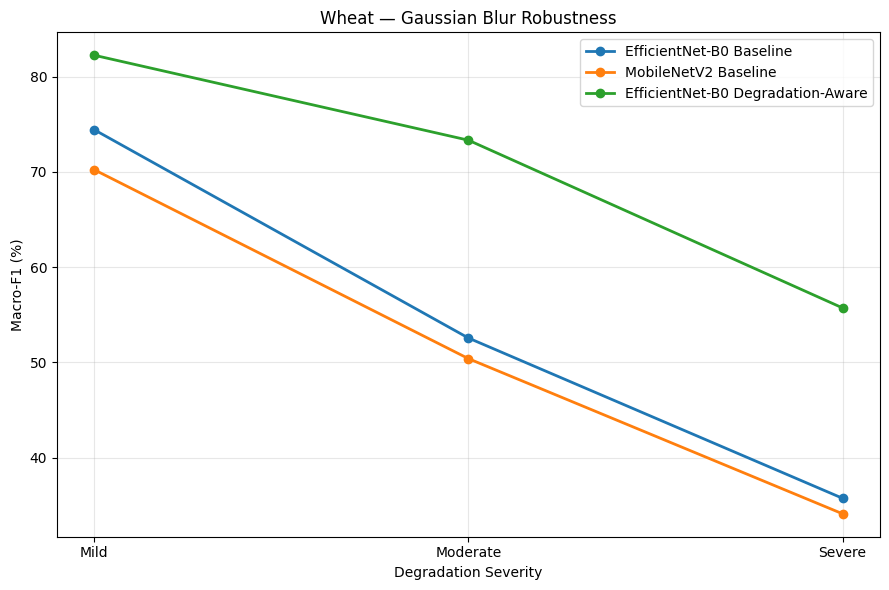

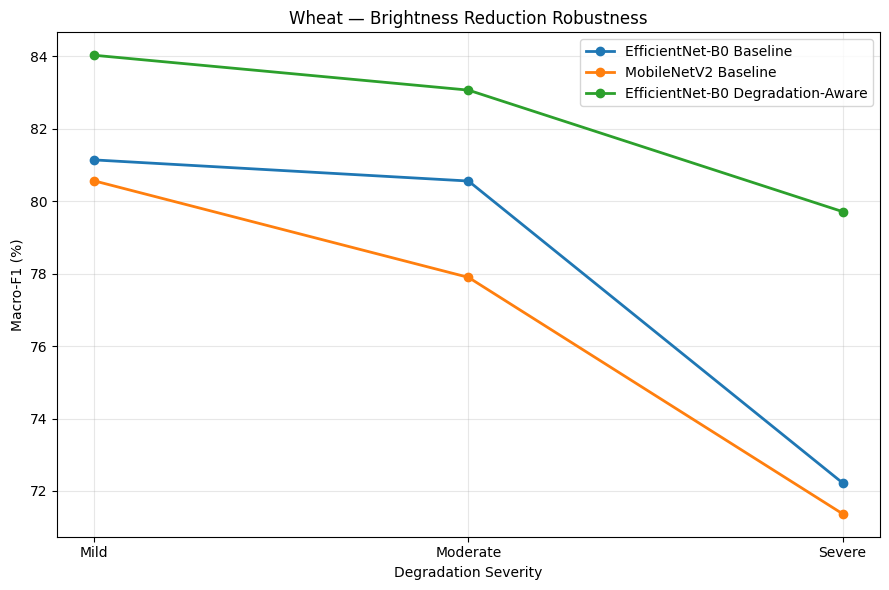

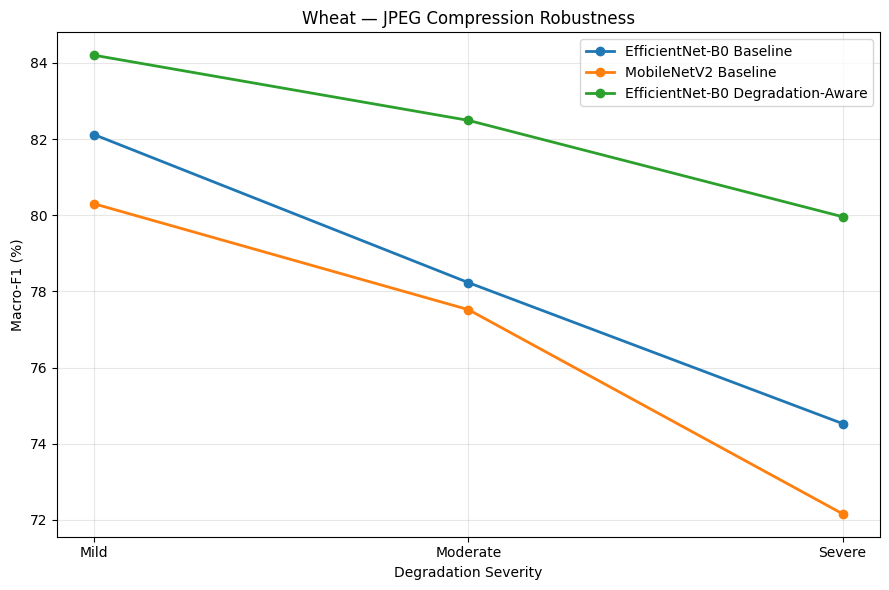

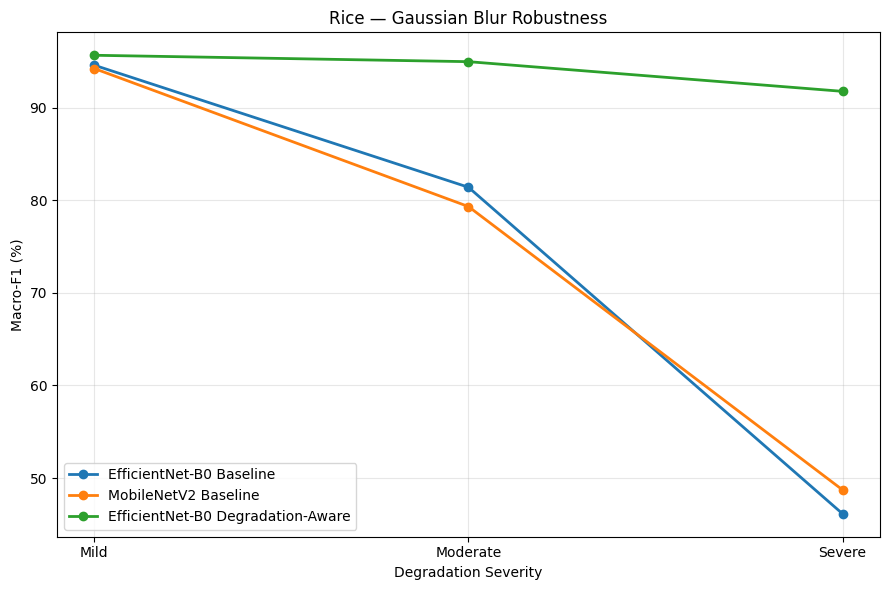

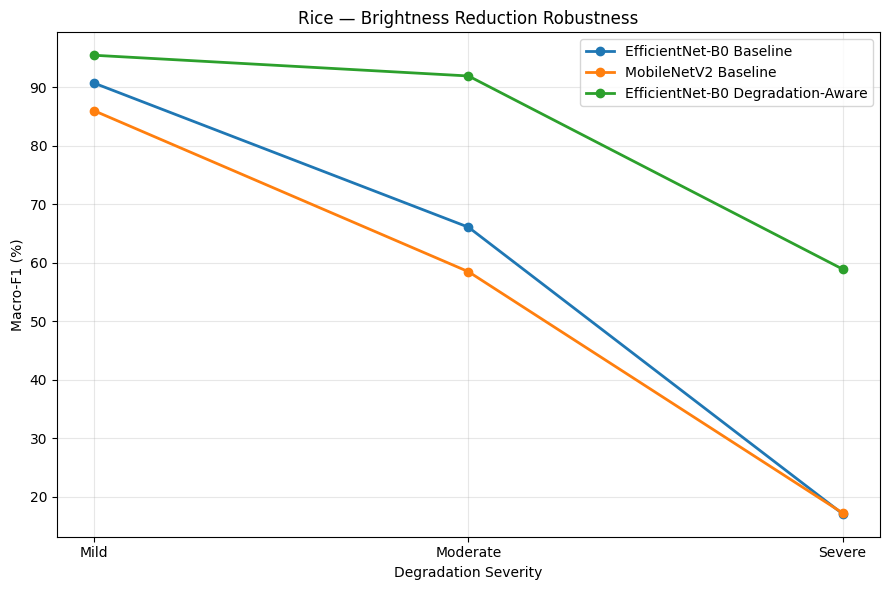

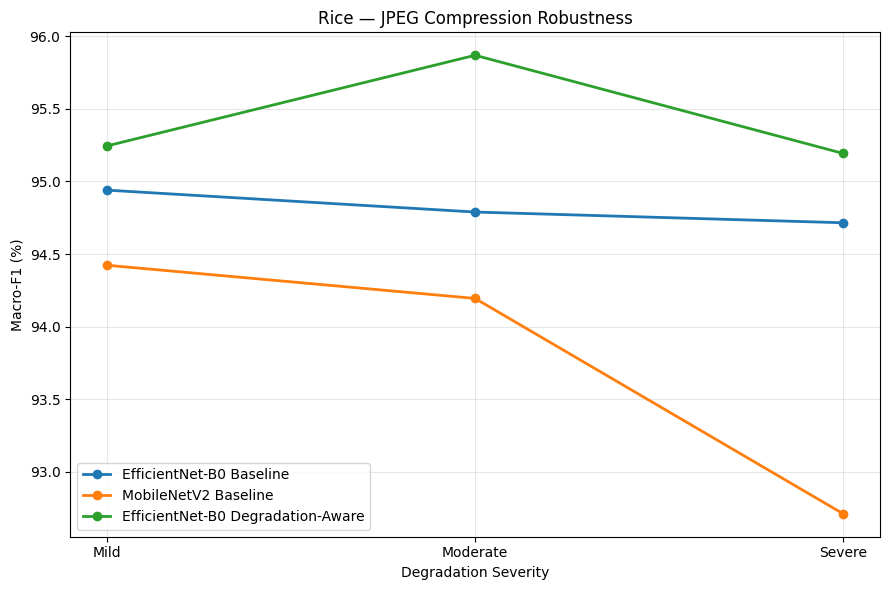

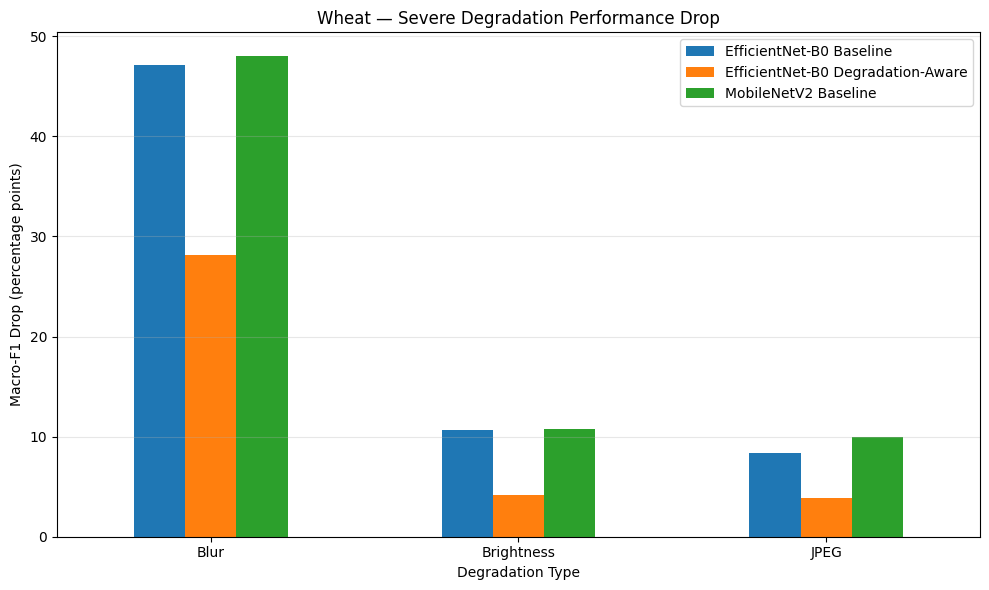

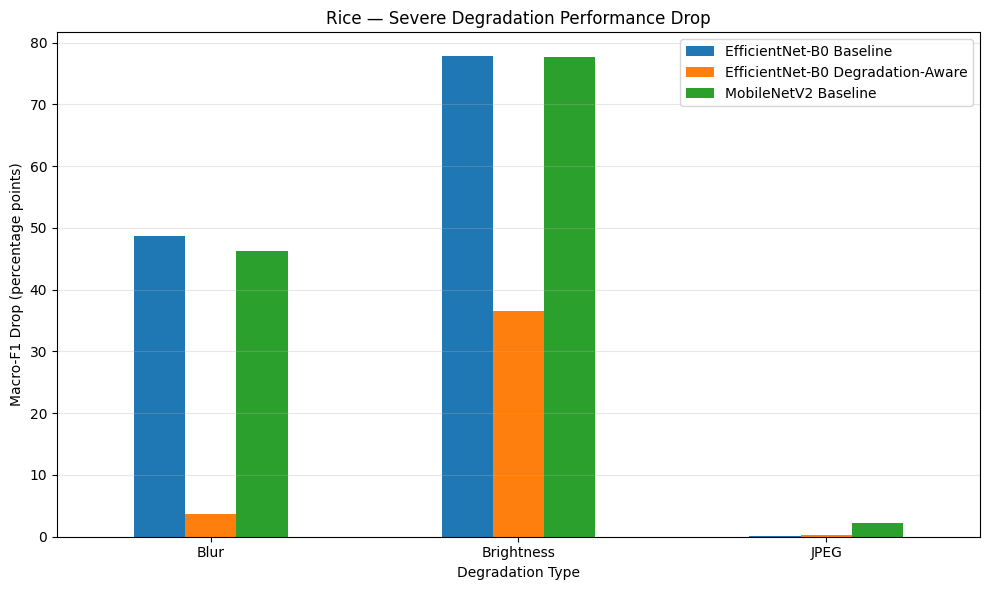


ROBUSTNESS SUMMARY


,crop,model,mean_accuracy,mean_macro_f1,mean_macro_f1_drop
0,rice,EfficientNet-B0 Baseline,0.7891,0.7560,19.2453
1,rice,EfficientNet-B0 Degradation-Aware,0.9141,0.9055,4.9494
2,rice,MobileNetV2 Baseline,0.7667,0.7391,21.0362
3,wheat,EfficientNet-B0 Baseline,0.7247,0.7017,12.7135
4,wheat,EfficientNet-B0 Degradation-Aware,0.8073,0.7831,5.5379
5,wheat,MobileNetV2 Baseline,0.7043,0.6828,13.8033



Figures saved to: /kaggle/working/wheat_rice_journal/final_evaluation/degraded/figures


In [8]:
# ============================================================
# CELL — ROBUSTNESS VISUALIZATION
# ============================================================

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

ROOT = Path("/kaggle/working/wheat_rice_journal")

RESULT_FILE = (
    ROOT
    / "final_evaluation"
    / "degraded"
    / "robustness_results_with_drop.csv"
)

FIG_DIR = (
    ROOT
    / "final_evaluation"
    / "degraded"
    / "figures"
)

FIG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(RESULT_FILE)

print("Loaded:", RESULT_FILE)
print("Rows:", len(df))

# ============================================================
# Model labels
# ============================================================

MODEL_LABELS = {
    "efficientnet_b0_baseline":
        "EfficientNet-B0 Baseline",

    "mobilenet_v2_baseline":
        "MobileNetV2 Baseline",

    "efficientnet_b0_degradation":
        "EfficientNet-B0 Degradation-Aware",
}

df["model_label"] = df["experiment"].map(
    MODEL_LABELS
)


# ============================================================
# 1. MACRO-F1 VS SEVERITY
# ============================================================

for crop in ["wheat", "rice"]:

    crop_df = df[
        df["crop"] == crop
    ].copy()

    fig, ax = plt.subplots(
        figsize=(10, 6)
    )

    degradations = [
        ("blur", "Gaussian Blur"),
        ("brightness", "Brightness Reduction"),
        ("jpeg", "JPEG Compression"),
    ]

    for degradation_type, title in degradations:

        subset = crop_df[
            crop_df["degradation_type"]
            == degradation_type
        ].copy()

        # Only degraded conditions
        subset = subset[
            subset["severity"] > 0
        ]

        for experiment in [
            "efficientnet_b0_baseline",
            "mobilenet_v2_baseline",
            "efficientnet_b0_degradation",
        ]:

            model_subset = subset[
                subset["experiment"]
                == experiment
            ].sort_values("severity")

            ax.plot(
                model_subset["severity"],
                model_subset["macro_f1"] * 100,
                marker="o",
                linewidth=2,
                label=MODEL_LABELS[
                    experiment
                ]
                if degradation_type == "blur"
                else None,
            )

        # This figure is generated separately below
        plt.close(fig)


# ============================================================
# 2. THREE SEPARATE DEGRADATION PLOTS
# ============================================================

for crop in ["wheat", "rice"]:

    crop_df = df[
        df["crop"] == crop
    ].copy()

    for degradation_type, title in [
        ("blur", "Gaussian Blur"),
        ("brightness", "Brightness Reduction"),
        ("jpeg", "JPEG Compression"),
    ]:

        subset = crop_df[
            crop_df["degradation_type"]
            == degradation_type
        ].copy()

        subset = subset[
            subset["severity"] > 0
        ]

        fig, ax = plt.subplots(
            figsize=(9, 6)
        )

        for experiment in [
            "efficientnet_b0_baseline",
            "mobilenet_v2_baseline",
            "efficientnet_b0_degradation",
        ]:

            model_subset = subset[
                subset["experiment"]
                == experiment
            ].sort_values("severity")

            ax.plot(
                model_subset["severity"],
                model_subset["macro_f1"] * 100,
                marker="o",
                linewidth=2,
                label=MODEL_LABELS[
                    experiment
                ],
            )

        ax.set_xlabel(
            "Degradation Severity"
        )

        ax.set_ylabel(
            "Macro-F1 (%)"
        )

        ax.set_title(
            f"{crop.title()} — {title} Robustness"
        )

        ax.set_xticks([1, 2, 3])

        ax.set_xticklabels([
            "Mild",
            "Moderate",
            "Severe",
        ])

        ax.grid(
            True,
            alpha=0.3
        )

        ax.legend(
            loc="best"
        )

        plt.tight_layout()

        output = (
            FIG_DIR
            / f"{crop}_{degradation_type}_macro_f1.png"
        )

        plt.savefig(
            output,
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

        plt.close()


# ============================================================
# 3. SEVERE-DEGRADATION PERFORMANCE DROP
# ============================================================

severe = df[
    (
        df["severity"] == 3
    )
    &
    (
        df["condition"] != "clean"
    )
].copy()

for crop in ["wheat", "rice"]:

    crop_df = severe[
        severe["crop"] == crop
    ].copy()

    pivot = crop_df.pivot_table(
        index="degradation_type",
        columns="experiment",
        values="macro_f1_drop_pp",
        aggfunc="mean",
    )

    pivot = pivot.rename(
        columns=MODEL_LABELS
    )

    fig, ax = plt.subplots(
        figsize=(10, 6)
    )

    pivot.plot(
        kind="bar",
        ax=ax
    )

    ax.set_xlabel(
        "Degradation Type"
    )

    ax.set_ylabel(
        "Macro-F1 Drop (percentage points)"
    )

    ax.set_title(
        f"{crop.title()} — Severe Degradation Performance Drop"
    )

    ax.set_xticklabels([
        "Blur",
        "Brightness",
        "JPEG",
    ], rotation=0)

    ax.grid(
        axis="y",
        alpha=0.3
    )

    ax.legend(
        loc="best"
    )

    plt.tight_layout()

    output = (
        FIG_DIR
        / f"{crop}_severe_degradation_drop.png"
    )

    plt.savefig(
        output,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()


# ============================================================
# 4. ROBUSTNESS SUMMARY TABLE
# ============================================================

degraded_only = df[
    df["severity"] > 0
].copy()

summary = (
    degraded_only
    .groupby(
        ["crop", "experiment"]
    )
    .agg(
        mean_macro_f1=(
            "macro_f1",
            "mean"
        ),
        mean_accuracy=(
            "accuracy",
            "mean"
        ),
        mean_macro_f1_drop=(
            "macro_f1_drop_pp",
            "mean"
        ),
    )
    .reset_index()
)

summary["model"] = summary[
    "experiment"
].map(MODEL_LABELS)

summary = summary[
    [
        "crop",
        "model",
        "mean_accuracy",
        "mean_macro_f1",
        "mean_macro_f1_drop",
    ]
]

print("\nROBUSTNESS SUMMARY")
display(
    summary.round(4)
)

summary.to_csv(
    FIG_DIR / "robustness_summary.csv",
    index=False
)

print(
    "\nFigures saved to:",
    FIG_DIR
)

In [11]:
# ============================================================
# TABLE 6 — CLASS-WISE CLEAN TEST PERFORMANCE
# READ SAVED ROBUSTNESS PREDICTIONS ONLY
# NO MODEL EVALUATION
# ============================================================

from pathlib import Path
import pandas as pd
from sklearn.metrics import classification_report
from IPython.display import display

ROOT = Path(
    "/kaggle/working/wheat_rice_journal"
)

PRED_FILE = (
    ROOT
    / "final_evaluation"
    / "degraded"
    / "degraded_test_predictions.csv"
)

OUT = (
    ROOT
    / "final_evaluation"
    / "paper_tables"
)

OUT.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# LOAD SAVED PREDICTIONS
# ------------------------------------------------------------

pred = pd.read_csv(
    PRED_FILE
)

print(
    "Loaded:",
    PRED_FILE
)

print(
    "Total saved prediction rows:",
    len(pred)
)

# ------------------------------------------------------------
# ONLY CLEAN CONDITION
# ------------------------------------------------------------

clean = pred[
    pred["condition"] == "clean"
].copy()

print(
    "Clean prediction rows:",
    len(clean)
)

# ------------------------------------------------------------
# MODEL LABELS
# ------------------------------------------------------------

MODEL_LABELS = {
    "efficientnet_b0_baseline":
        "EfficientNet-B0 Baseline",

    "mobilenet_v2_baseline":
        "MobileNetV2 Baseline",

    "efficientnet_b0_degradation":
        "EfficientNet-B0 Degradation-Aware",
}

# ------------------------------------------------------------
# BUILD CLASS-WISE TABLE
# ------------------------------------------------------------

rows = []

for (crop, experiment), group in clean.groupby(
    ["crop", "experiment"],
    sort=False
):

    y_true = group["label_id"].astype(int)
    y_pred = group["prediction"].astype(int)

    # Class names in correct label_id order
    class_info = (
        group[
            ["label", "label_id"]
        ]
        .drop_duplicates()
        .sort_values("label_id")
    )

    labels = (
        class_info["label_id"]
        .astype(int)
        .tolist()
    )

    class_names = (
        class_info["label"]
        .tolist()
    )

    report = classification_report(
        y_true,
        y_pred,
        labels=labels,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    for class_name in class_names:

        rows.append({

            "Crop":
                crop.title(),

            "Model":
                MODEL_LABELS[experiment],

            "Class":
                class_name,

            "Precision (%)":
                report[class_name]["precision"] * 100,

            "Recall (%)":
                report[class_name]["recall"] * 100,

            "F1-score (%)":
                report[class_name]["f1-score"] * 100,

            "Support":
                int(
                    report[class_name]["support"]
                ),
        })


table_6 = pd.DataFrame(rows)

for column in [
    "Precision (%)",
    "Recall (%)",
    "F1-score (%)"
]:

    table_6[column] = (
        table_6[column]
        .round(2)
    )

display(
    table_6
)

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

output = (
    OUT
    / "Table_6_Classwise_Clean_Test_Performance.csv"
)

table_6.to_csv(
    output,
    index=False
)

print(
    "\nTABLE 6 SAVED:"
)

print(
    output
)

Loaded: /kaggle/working/wheat_rice_journal/final_evaluation/degraded/degraded_test_predictions.csv
Total saved prediction rows: 95610
Clean prediction rows: 9561


,Crop,Model,Class,Precision (%),Recall (%),F1-score (%),Support
0,Wheat,EfficientNet-B0 Baseline,aphid,83.72,83.72,83.72,129
1,Wheat,EfficientNet-B0 Baseline,black_rust,72.34,69.39,70.83,49
2,Wheat,EfficientNet-B0 Baseline,blast,80.72,85.90,83.23,78
3,Wheat,EfficientNet-B0 Baseline,brown_rust,91.30,91.80,91.55,183
4,Wheat,EfficientNet-B0 Baseline,common_root_rot,84.51,71.43,77.42,84
...,...,...,...,...,...,...,...
70,Rice,EfficientNet-B0 Degradation-Aware,dead_heart,100.00,99.05,99.52,211
71,Rice,EfficientNet-B0 Degradation-Aware,downy_mildew,89.01,92.05,90.50,88
72,Rice,EfficientNet-B0 Degradation-Aware,hispa,95.79,96.90,96.34,258
73,Rice,EfficientNet-B0 Degradation-Aware,normal,95.26,96.31,95.78,271



TABLE 6 SAVED:
/kaggle/working/wheat_rice_journal/final_evaluation/paper_tables/Table_6_Classwise_Clean_Test_Performance.csv


In [12]:
# TABLE 6 — PAPER-READY CLASS-WISE TABLE
from pathlib import Path
import pandas as pd
from IPython.display import display, Markdown

ROOT = Path("/kaggle/working/wheat_rice_journal")

FILE = ROOT / "final_evaluation" / "paper_tables" / \
       "Table_6_Classwise_Clean_Test_Performance.csv"

df = pd.read_csv(FILE)

# Compact paper format
df["P / R / F1 (%)"] = (
    df["Precision (%)"].map(lambda x: f"{x:.2f}") + " / " +
    df["Recall (%)"].map(lambda x: f"{x:.2f}") + " / " +
    df["F1-score (%)"].map(lambda x: f"{x:.2f}")
)

paper_df = df[
    ["Crop", "Model", "Class", "P / R / F1 (%)", "Support"]
].copy()

# -----------------------------
# WHEAT
# -----------------------------
wheat = paper_df[paper_df["Crop"].str.lower() == "wheat"].copy()

print("=" * 100)
print("TABLE 6A. CLASS-WISE CLEAN TEST PERFORMANCE — WHEAT")
print("=" * 100)

display(
    wheat.rename(columns={
        "Model": "Model",
        "Class": "Disease/Class",
        "P / R / F1 (%)": "Precision / Recall / F1 (%)"
    }).reset_index(drop=True)
)

# Markdown version for easy copy into paper
print("\nMARKDOWN TABLE — WHEAT\n")
print(
    wheat.rename(columns={
        "Class": "Disease/Class",
        "P / R / F1 (%)": "Precision / Recall / F1 (%)"
    })
    .to_markdown(index=False)
)

# -----------------------------
# RICE
# -----------------------------
rice = paper_df[paper_df["Crop"].str.lower() == "rice"].copy()

print("\n" + "=" * 100)
print("TABLE 6B. CLASS-WISE CLEAN TEST PERFORMANCE — RICE")
print("=" * 100)

display(
    rice.rename(columns={
        "Model": "Model",
        "Class": "Disease/Class",
        "P / R / F1 (%)": "Precision / Recall / F1 (%)"
    }).reset_index(drop=True)
)

print("\nMARKDOWN TABLE — RICE\n")
print(
    rice.rename(columns={
        "Class": "Disease/Class",
        "P / R / F1 (%)": "Precision / Recall / F1 (%)"
    })
    .to_markdown(index=False)
)

TABLE 6A. CLASS-WISE CLEAN TEST PERFORMANCE — WHEAT


,Crop,Model,Disease/Class,Precision / Recall / F1 (%),Support
0,Wheat,EfficientNet-B0 Baseline,aphid,83.72 / 83.72 / 83.72,129
1,Wheat,EfficientNet-B0 Baseline,black_rust,72.34 / 69.39 / 70.83,49
2,Wheat,EfficientNet-B0 Baseline,blast,80.72 / 85.90 / 83.23,78
3,Wheat,EfficientNet-B0 Baseline,brown_rust,91.30 / 91.80 / 91.55,183
4,Wheat,EfficientNet-B0 Baseline,common_root_rot,84.51 / 71.43 / 77.42,84
5,Wheat,EfficientNet-B0 Baseline,fusarium_head_blight,92.93 / 85.98 / 89.32,107
6,Wheat,EfficientNet-B0 Baseline,healthy,93.21 / 95.57 / 94.38,158
7,Wheat,EfficientNet-B0 Baseline,leaf_blight,59.79 / 62.37 / 61.05,93
8,Wheat,EfficientNet-B0 Baseline,mildew,89.13 / 92.13 / 90.61,178
9,Wheat,EfficientNet-B0 Baseline,mite,79.84 / 83.90 / 81.82,118



MARKDOWN TABLE — WHEAT

| Crop   | Model                             | Disease/Class        | Precision / Recall / F1 (%)   |   Support |
|:-------|:----------------------------------|:---------------------|:------------------------------|----------:|
| Wheat  | EfficientNet-B0 Baseline          | aphid                | 83.72 / 83.72 / 83.72         |       129 |
| Wheat  | EfficientNet-B0 Baseline          | black_rust           | 72.34 / 69.39 / 70.83         |        49 |
| Wheat  | EfficientNet-B0 Baseline          | blast                | 80.72 / 85.90 / 83.23         |        78 |
| Wheat  | EfficientNet-B0 Baseline          | brown_rust           | 91.30 / 91.80 / 91.55         |       183 |
| Wheat  | EfficientNet-B0 Baseline          | common_root_rot      | 84.51 / 71.43 / 77.42         |        84 |
| Wheat  | EfficientNet-B0 Baseline          | fusarium_head_blight | 92.93 / 85.98 / 89.32         |       107 |
| Wheat  | EfficientNet-B0 Baseline          | healthy         

,Crop,Model,Disease/Class,Precision / Recall / F1 (%),Support
0,Rice,EfficientNet-B0 Baseline,bacterial_leaf_blight,90.91 / 90.91 / 90.91,66
1,Rice,EfficientNet-B0 Baseline,bacterial_leaf_streak,93.10 / 96.43 / 94.74,56
2,Rice,EfficientNet-B0 Baseline,bacterial_panicle_blight,93.88 / 97.87 / 95.83,47
3,Rice,EfficientNet-B0 Baseline,blast,95.58 / 95.58 / 95.58,249
4,Rice,EfficientNet-B0 Baseline,brown_spot,97.08 / 94.33 / 95.68,141
5,Rice,EfficientNet-B0 Baseline,dead_heart,100.00 / 99.53 / 99.76,211
6,Rice,EfficientNet-B0 Baseline,downy_mildew,86.32 / 93.18 / 89.62,88
7,Rice,EfficientNet-B0 Baseline,hispa,96.54 / 97.29 / 96.91,258
8,Rice,EfficientNet-B0 Baseline,normal,95.24 / 95.94 / 95.59,271
9,Rice,EfficientNet-B0 Baseline,tungro,96.79 / 90.96 / 93.79,166



MARKDOWN TABLE — RICE

| Crop   | Model                             | Disease/Class            | Precision / Recall / F1 (%)   |   Support |
|:-------|:----------------------------------|:-------------------------|:------------------------------|----------:|
| Rice   | EfficientNet-B0 Baseline          | bacterial_leaf_blight    | 90.91 / 90.91 / 90.91         |        66 |
| Rice   | EfficientNet-B0 Baseline          | bacterial_leaf_streak    | 93.10 / 96.43 / 94.74         |        56 |
| Rice   | EfficientNet-B0 Baseline          | bacterial_panicle_blight | 93.88 / 97.87 / 95.83         |        47 |
| Rice   | EfficientNet-B0 Baseline          | blast                    | 95.58 / 95.58 / 95.58         |       249 |
| Rice   | EfficientNet-B0 Baseline          | brown_spot               | 97.08 / 94.33 / 95.68         |       141 |
| Rice   | EfficientNet-B0 Baseline          | dead_heart               | 100.00 / 99.53 / 99.76        |       211 |
| Rice   | EfficientNet-B0 Basel

Loaded successfully:
/kaggle/working/wheat_rice_journal/final_evaluation/paper_tables/Table_6_Classwise_Clean_Test_Performance.csv

Columns found:
['Crop', 'Model', 'Class', 'Precision (%)', 'Recall (%)', 'F1-score (%)', 'Support']

Number of rows: 75

Wheat data:


Model,EfficientNet-B0 Baseline,MobileNetV2 Baseline,EfficientNet-B0 Degradation-Aware
Class,,,
aphid,83.72,78.54,83.59
black_rust,70.83,66.67,72.73
blast,83.23,83.33,81.21
brown_rust,91.55,93.37,92.82
common_root_rot,77.42,70.30,78.43
fusarium_head_blight,89.32,91.79,91.71
healthy,94.38,93.79,94.38
leaf_blight,61.05,67.33,65.22
mildew,90.61,88.57,91.55


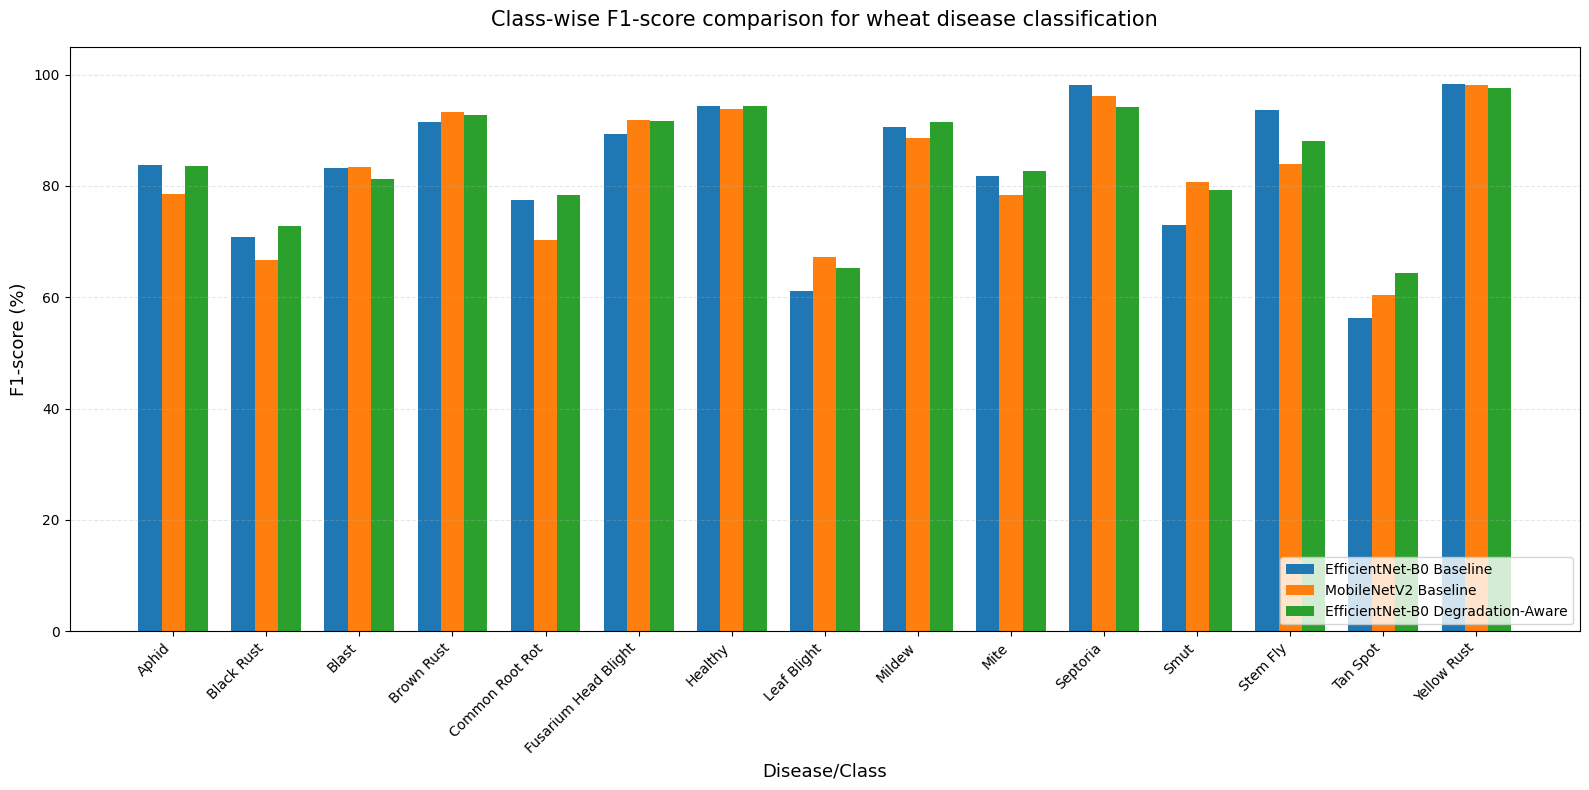


Saved:
/kaggle/working/wheat_rice_journal/final_evaluation/paper_figures/Figure_6A_Wheat_Classwise_F1.png

Rice data:


Model,EfficientNet-B0 Baseline,MobileNetV2 Baseline,EfficientNet-B0 Degradation-Aware
Class,,,
bacterial_leaf_blight,90.91,93.65,97.74
bacterial_leaf_streak,94.74,94.92,95.58
bacterial_panicle_blight,95.83,96.91,96.84
blast,95.58,93.50,94.16
brown_spot,95.68,94.77,94.96
dead_heart,99.76,99.28,99.52
downy_mildew,89.62,91.53,90.50
hispa,96.91,96.55,96.34
normal,95.59,96.30,95.78


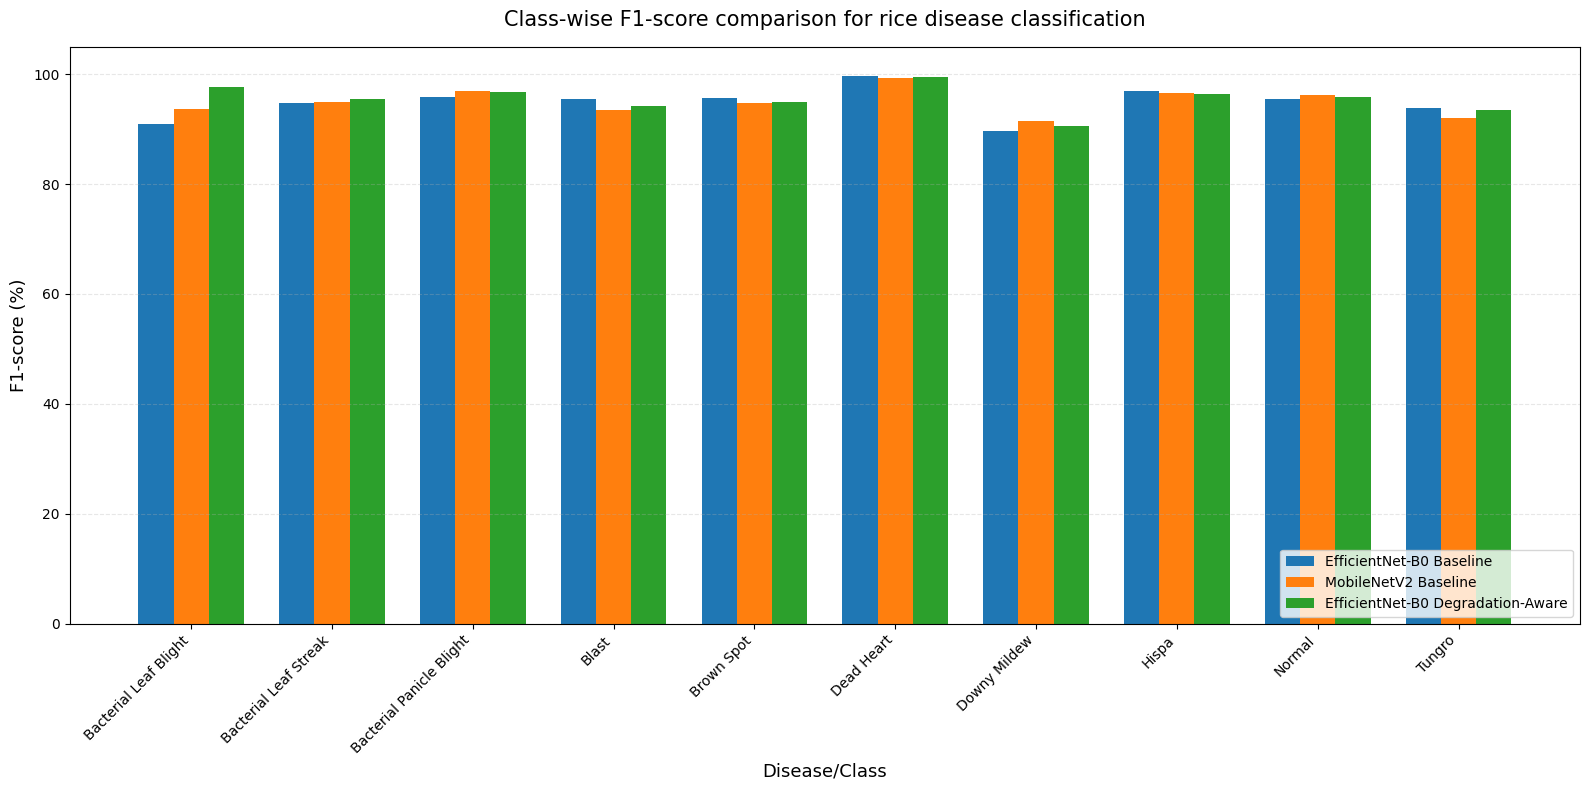


Saved:
/kaggle/working/wheat_rice_journal/final_evaluation/paper_figures/Figure_6B_Rice_Classwise_F1.png

FIGURE 6 GENERATION COMPLETE

Wheat:
/kaggle/working/wheat_rice_journal/final_evaluation/paper_figures/Figure_6A_Wheat_Classwise_F1.png

Rice:
/kaggle/working/wheat_rice_journal/final_evaluation/paper_figures/Figure_6B_Rice_Classwise_F1.png


In [14]:
# ============================================================
# FIGURE 6 — CLASS-WISE F1-SCORE COMPARISON
# Wheat + Rice
# Uses the already saved Table 6 CSV
# ============================================================

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------
ROOT = Path("/kaggle/working/wheat_rice_journal")

INPUT_FILE = (
    ROOT
    / "final_evaluation"
    / "paper_tables"
    / "Table_6_Classwise_Clean_Test_Performance.csv"
)

FIG_DIR = ROOT / "final_evaluation" / "paper_figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# LOAD TABLE 6
# ------------------------------------------------------------
df = pd.read_csv(INPUT_FILE)

print("Loaded successfully:")
print(INPUT_FILE)
print("\nColumns found:")
print(df.columns.tolist())
print("\nNumber of rows:", len(df))

# ------------------------------------------------------------
# CHECK REQUIRED COLUMNS
# ------------------------------------------------------------
required_cols = [
    "Crop",
    "Model",
    "Class",
    "F1-score (%)"
]

missing = [c for c in required_cols if c not in df.columns]

if missing:
    raise ValueError(
        f"Missing columns: {missing}\n"
        f"Available columns are: {df.columns.tolist()}"
    )

# ------------------------------------------------------------
# MODEL ORDER
# ------------------------------------------------------------
MODEL_ORDER = [
    "EfficientNet-B0 Baseline",
    "MobileNetV2 Baseline",
    "EfficientNet-B0 Degradation-Aware"
]

# ------------------------------------------------------------
# PLOT FUNCTION
# ------------------------------------------------------------
def create_classwise_f1_graph(crop_name, file_name, title):

    data = df[
        df["Crop"].astype(str).str.lower() == crop_name.lower()
    ].copy()

    if data.empty:
        raise ValueError(f"No data found for crop: {crop_name}")

    # Keep original class order
    class_order = data["Class"].drop_duplicates().tolist()

    # Convert to pivot table
    pivot = data.pivot(
        index="Class",
        columns="Model",
        values="F1-score (%)"
    )

    # Correct order
    pivot = pivot.reindex(index=class_order)
    pivot = pivot.reindex(columns=MODEL_ORDER)

    print(f"\n{crop_name} data:")
    display(pivot)

    # --------------------------------------------------------
    # BAR POSITIONS
    # --------------------------------------------------------
    x = np.arange(len(pivot.index))
    width = 0.25

    fig, ax = plt.subplots(figsize=(16, 8))

    for i, model in enumerate(MODEL_ORDER):

        offset = (i - 1) * width

        ax.bar(
            x + offset,
            pivot[model],
            width=width,
            label=model
        )

    # --------------------------------------------------------
    # AXIS SETTINGS
    # --------------------------------------------------------
    ax.set_xlabel(
        "Disease/Class",
        fontsize=13
    )

    ax.set_ylabel(
        "F1-score (%)",
        fontsize=13
    )

    ax.set_title(
        title,
        fontsize=15,
        pad=15
    )

    ax.set_xticks(x)

    ax.set_xticklabels(
        [
            str(c).replace("_", " ").title()
            for c in pivot.index
        ],
        rotation=45,
        ha="right"
    )

    ax.set_ylim(0, 105)

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )

    ax.legend(
        fontsize=10,
        loc="lower right"
    )

    plt.tight_layout()

    # --------------------------------------------------------
    # SAVE PNG
    # --------------------------------------------------------
    output_file = FIG_DIR / file_name

    plt.savefig(
        output_file,
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()

    print("\nSaved:")
    print(output_file)

    return pivot


# ============================================================
# FIGURE 6A — WHEAT
# ============================================================

wheat_data = create_classwise_f1_graph(
    crop_name="Wheat",
    file_name="Figure_6A_Wheat_Classwise_F1.png",
    title="Class-wise F1-score comparison for wheat disease classification"
)

# ============================================================
# FIGURE 6B — RICE
# ============================================================

rice_data = create_classwise_f1_graph(
    crop_name="Rice",
    file_name="Figure_6B_Rice_Classwise_F1.png",
    title="Class-wise F1-score comparison for rice disease classification"
)

# ============================================================
# SAVE GRAPH DATA
# ============================================================

wheat_data.to_csv(
    FIG_DIR / "Figure_6A_Wheat_F1_Data.csv"
)

rice_data.to_csv(
    FIG_DIR / "Figure_6B_Rice_F1_Data.csv"
)

print("\n" + "=" * 70)
print("FIGURE 6 GENERATION COMPLETE")
print("=" * 70)

print("\nWheat:")
print(FIG_DIR / "Figure_6A_Wheat_Classwise_F1.png")

print("\nRice:")
print(FIG_DIR / "Figure_6B_Rice_Classwise_F1.png")

Total clean rows: 9561
['path', 'label', 'label_id', 'prediction', 'correct', 'crop', 'experiment', 'condition']


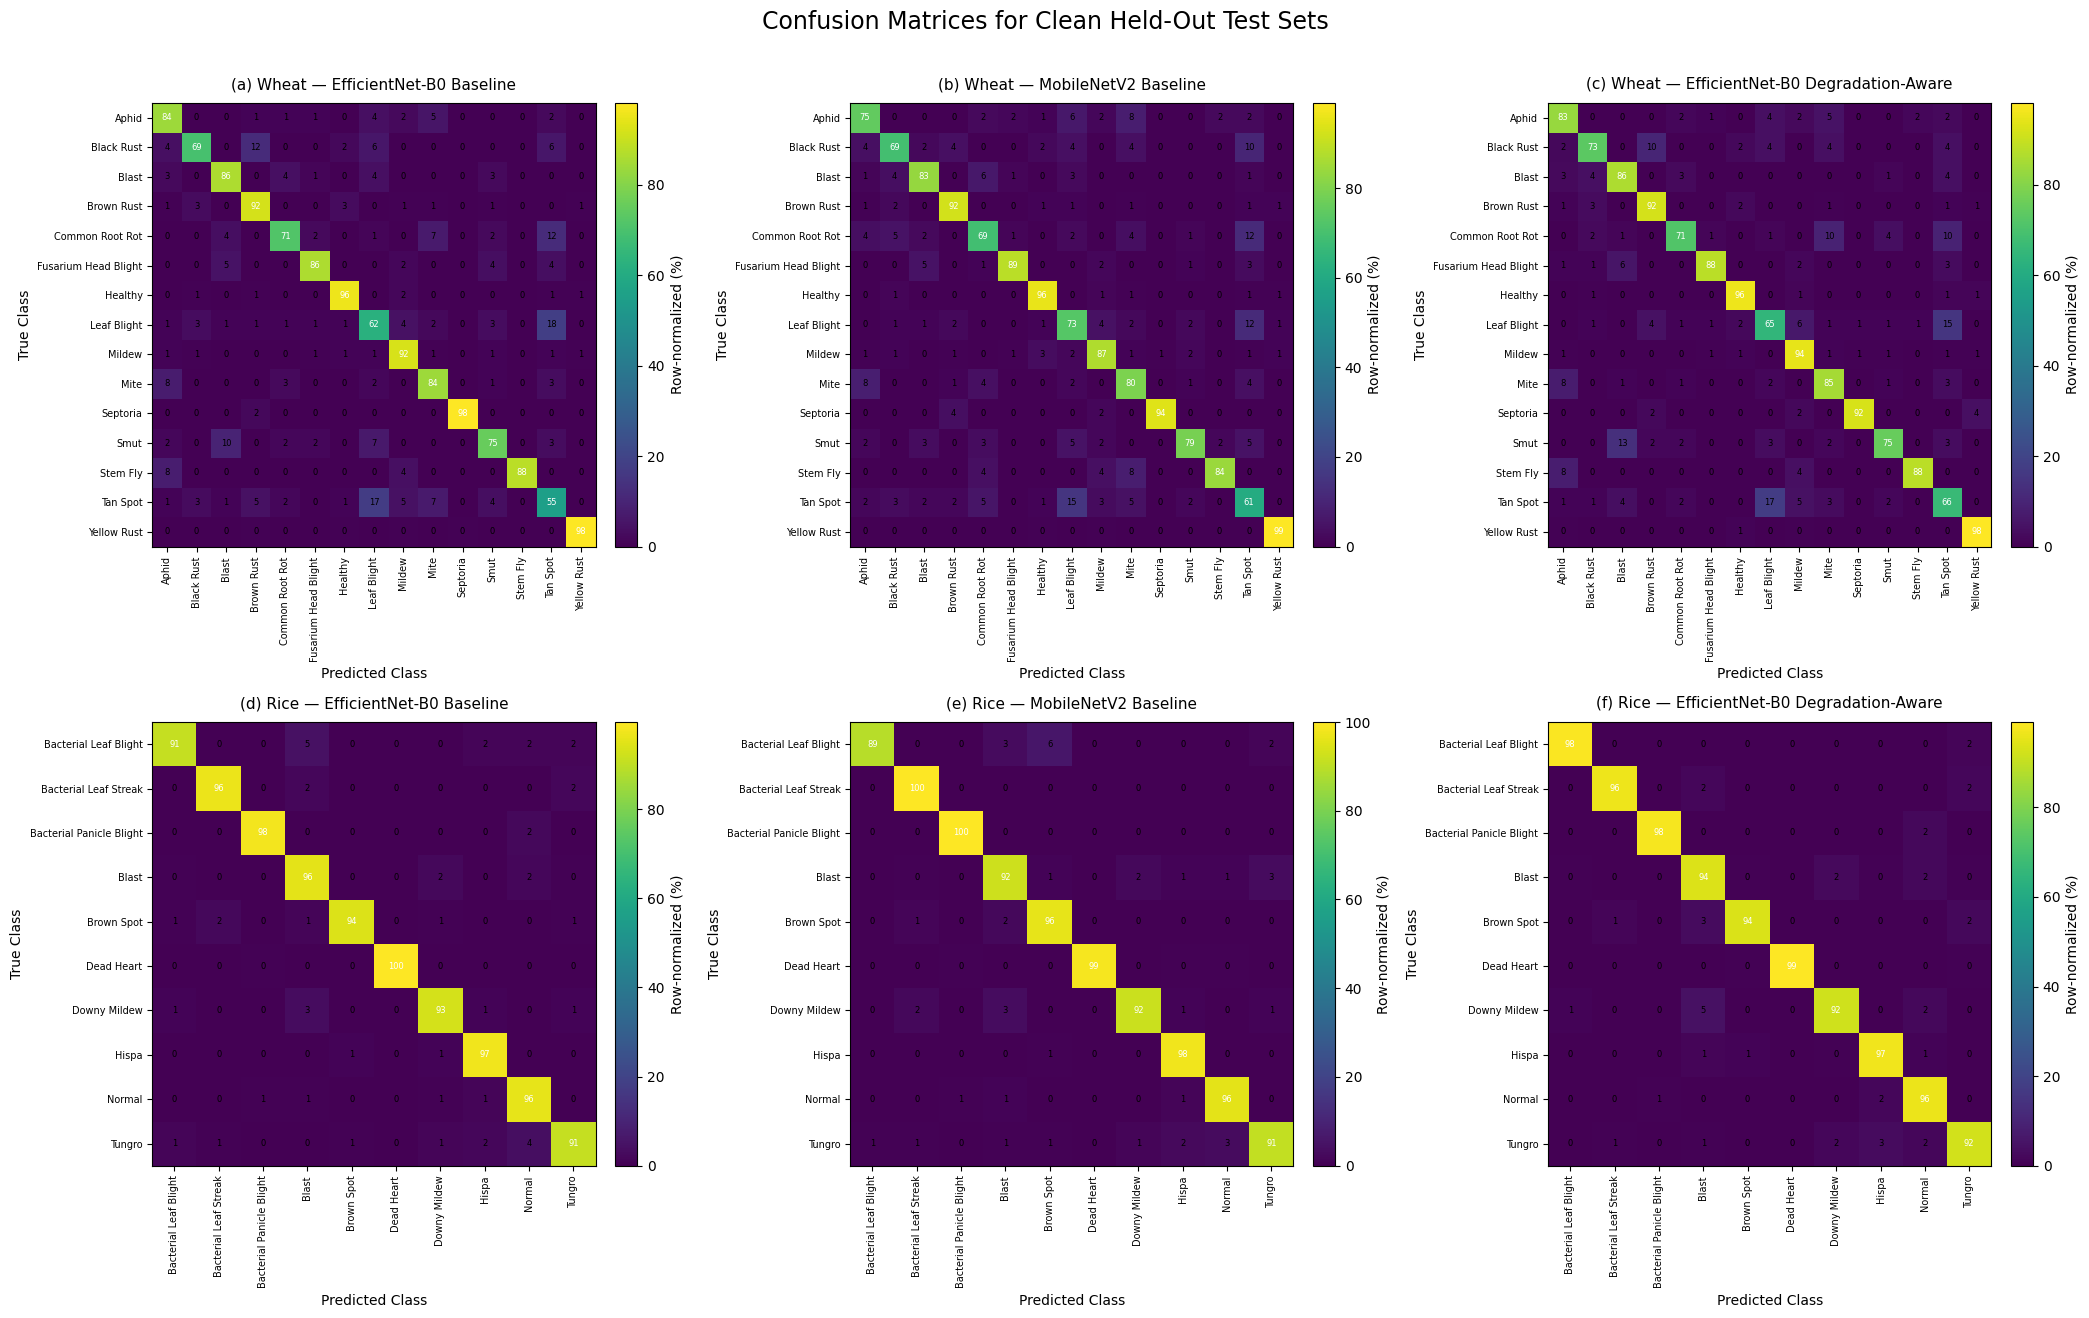


FIGURE 2 GENERATED
PNG: /kaggle/working/wheat_rice_journal/final_evaluation/paper_figures/Figure_2_Six_Confusion_Matrices.png
PDF: /kaggle/working/wheat_rice_journal/final_evaluation/paper_figures/Figure_2_Six_Confusion_Matrices.pdf


In [15]:
# ============================================================
# FIGURE 2 — SIX CONFUSION MATRICES
# Wheat + Rice
# Uses saved CLEAN predictions only
# NO RETRAINING / NO MODEL INFERENCE
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------
ROOT = Path("/kaggle/working/wheat_rice_journal")

PRED_FILE = (
    ROOT
    / "final_evaluation"
    / "degraded"
    / "degraded_test_predictions.csv"
)

FIG_DIR = ROOT / "final_evaluation" / "paper_figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# LOAD SAVED PREDICTIONS
# ------------------------------------------------------------
df = pd.read_csv(PRED_FILE)

# Only clean test predictions
clean = df[df["condition"] == "clean"].copy()

print("Total clean rows:", len(clean))
print(clean.columns.tolist())

# ------------------------------------------------------------
# MODEL ORDER
# ------------------------------------------------------------
MODEL_ORDER = [
    "efficientnet_b0_baseline",
    "mobilenet_v2_baseline",
    "efficientnet_b0_degradation"
]

MODEL_LABELS = {
    "efficientnet_b0_baseline": "EfficientNet-B0 Baseline",
    "mobilenet_v2_baseline": "MobileNetV2 Baseline",
    "efficientnet_b0_degradation": "EfficientNet-B0 Degradation-Aware"
}

# ------------------------------------------------------------
# FUNCTION
# ------------------------------------------------------------
def get_cm_data(crop_name, experiment):

    d = clean[
        (clean["crop"].astype(str).str.lower() == crop_name.lower()) &
        (clean["experiment"] == experiment)
    ].copy()

    if d.empty:
        raise ValueError(
            f"No clean prediction data found for {crop_name} / {experiment}"
        )

    # Class order from label_id
    class_info = (
        d[["label", "label_id"]]
        .drop_duplicates()
        .sort_values("label_id")
    )

    labels = class_info["label_id"].astype(int).tolist()
    class_names = class_info["label"].tolist()

    y_true = d["label_id"].astype(int)
    y_pred = d["prediction"].astype(int)

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=labels
    )

    return cm, class_names


# ============================================================
# CREATE COMBINED FIGURE
# ============================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(21, 13)
)

crops = ["wheat", "rice"]

panel = 0

for row, crop in enumerate(crops):

    for col, experiment in enumerate(MODEL_ORDER):

        ax = axes[row, col]

        cm, class_names = get_cm_data(
            crop,
            experiment
        )

        # Row-normalized confusion matrix
        cm_percent = (
            cm.astype(float) /
            cm.sum(axis=1, keepdims=True) *
            100
        )

        # Handle any zero-support rows safely
        cm_percent = np.nan_to_num(cm_percent)

        im = ax.imshow(
            cm_percent,
            interpolation="nearest",
            aspect="auto"
        )

        # ----------------------------------------------------
        # Titles
        # ----------------------------------------------------
        ax.set_title(
            f"({chr(97 + panel)}) {crop.title()} — "
            f"{MODEL_LABELS[experiment]}",
            fontsize=11,
            pad=10
        )

        panel += 1

        # ----------------------------------------------------
        # Axis labels
        # ----------------------------------------------------
        ax.set_xlabel("Predicted Class", fontsize=10)
        ax.set_ylabel("True Class", fontsize=10)

        # ----------------------------------------------------
        # Tick labels
        # ----------------------------------------------------
        pretty_names = [
            str(x).replace("_", " ").title()
            for x in class_names
        ]

        ax.set_xticks(np.arange(len(class_names)))
        ax.set_yticks(np.arange(len(class_names)))

        ax.set_xticklabels(
            pretty_names,
            rotation=90,
            fontsize=7
        )

        ax.set_yticklabels(
            pretty_names,
            fontsize=7
        )

        # ----------------------------------------------------
        # Annotate percentages
        # ----------------------------------------------------
        threshold = cm_percent.max() / 2.0

        for i in range(cm_percent.shape[0]):
            for j in range(cm_percent.shape[1]):

                value = cm_percent[i, j]

                ax.text(
                    j,
                    i,
                    f"{value:.0f}",
                    ha="center",
                    va="center",
                    fontsize=6,
                    color="white" if value > threshold else "black"
                )

        # ----------------------------------------------------
        # Colorbar
        # ----------------------------------------------------
        plt.colorbar(
            im,
            ax=ax,
            fraction=0.046,
            pad=0.04,
            label="Row-normalized (%)"
        )


# ------------------------------------------------------------
# FIGURE TITLE
# ------------------------------------------------------------
fig.suptitle(
    "Confusion Matrices for Clean Held-Out Test Sets",
    fontsize=17,
    y=1.01
)

plt.tight_layout()

# ------------------------------------------------------------
# SAVE HIGH-RESOLUTION FILES
# ------------------------------------------------------------
PNG_FILE = (
    FIG_DIR /
    "Figure_2_Six_Confusion_Matrices.png"
)

PDF_FILE = (
    FIG_DIR /
    "Figure_2_Six_Confusion_Matrices.pdf"
)

plt.savefig(
    PNG_FILE,
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    PDF_FILE,
    bbox_inches="tight"
)

plt.show()

print("\n" + "=" * 70)
print("FIGURE 2 GENERATED")
print("=" * 70)

print("PNG:", PNG_FILE)
print("PDF:", PDF_FILE)

Loaded: /kaggle/working/wheat_rice_journal/final_evaluation/degraded/degraded_test_predictions.csv
Clean prediction rows: 9561


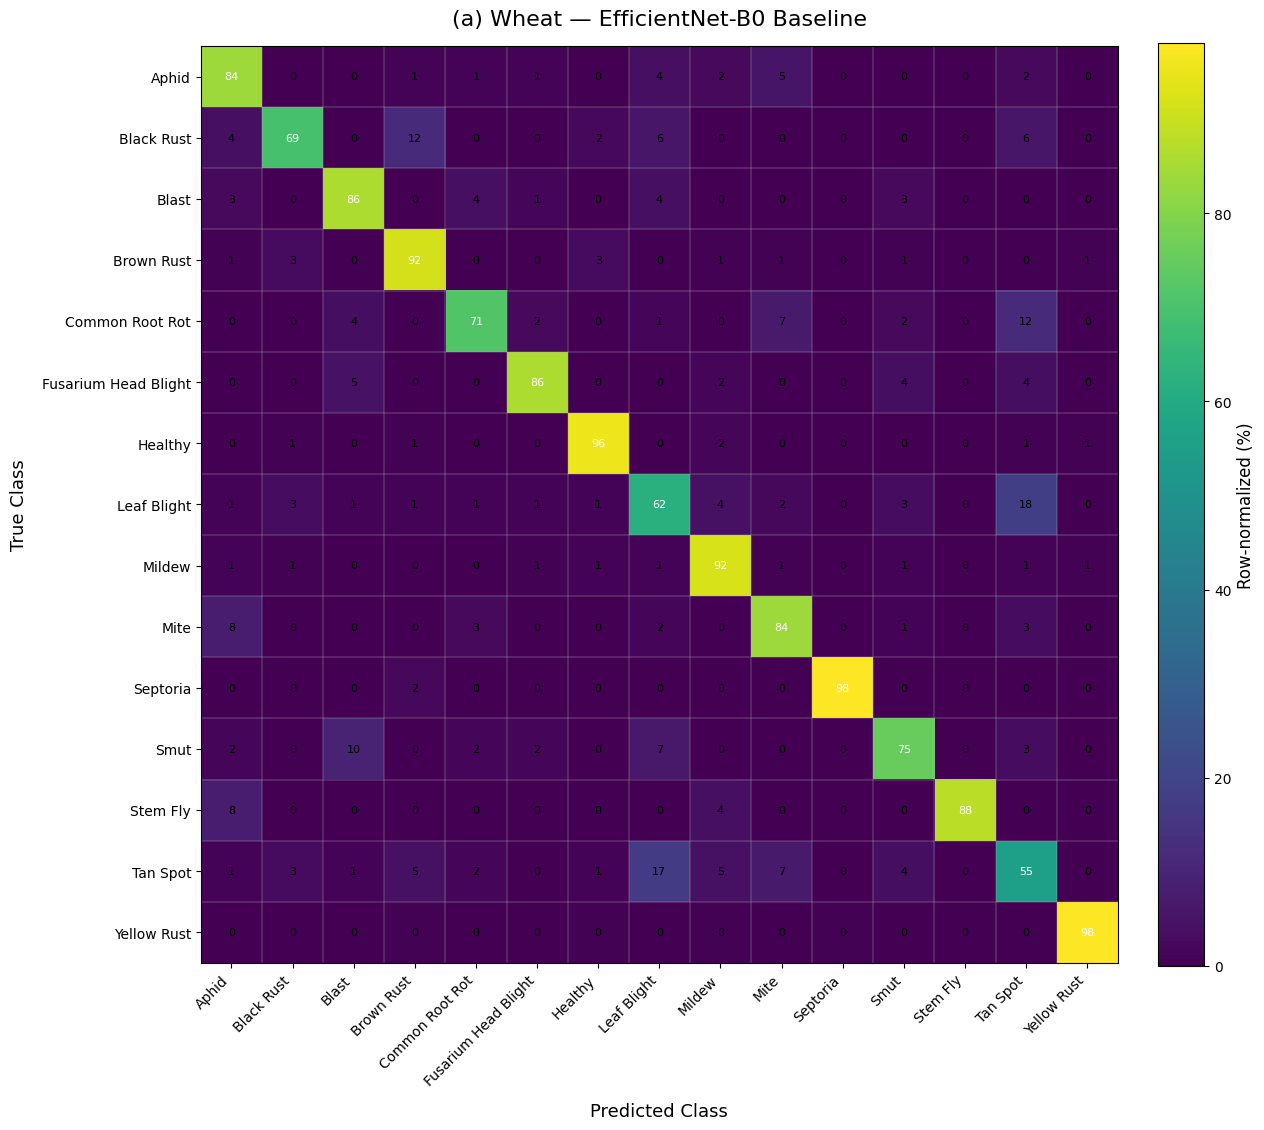

Saved: /kaggle/working/wheat_rice_journal/final_evaluation/paper_figures/Figure_2a_Wheat_EfficientNet_B0_Baseline_CM.png


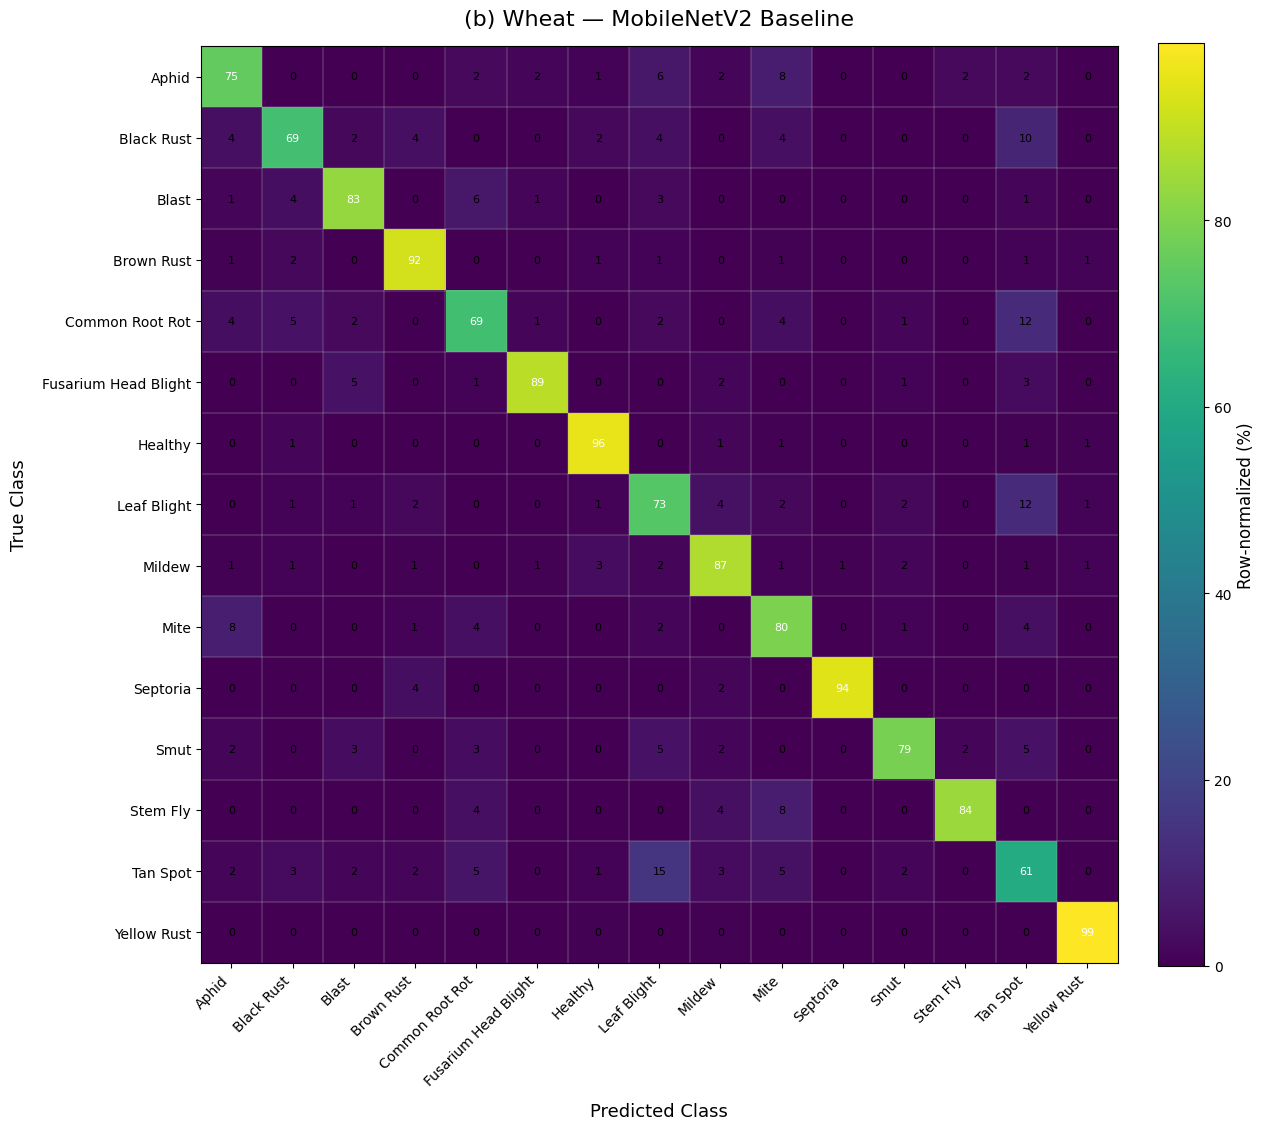

Saved: /kaggle/working/wheat_rice_journal/final_evaluation/paper_figures/Figure_2b_Wheat_MobileNetV2_Baseline_CM.png


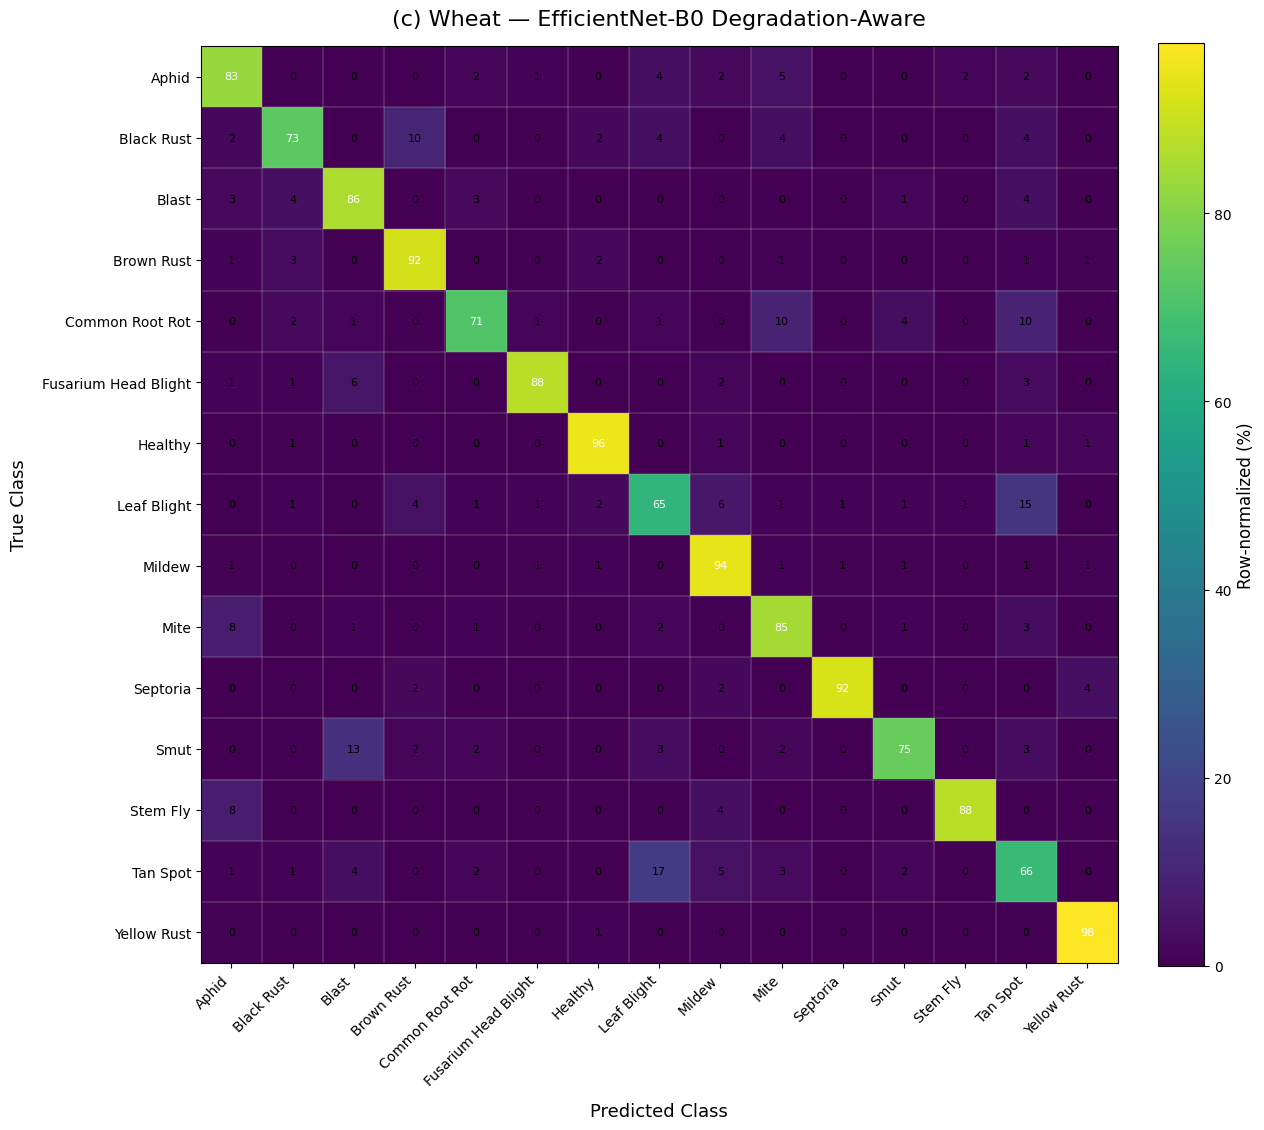

Saved: /kaggle/working/wheat_rice_journal/final_evaluation/paper_figures/Figure_2c_Wheat_EfficientNet_B0_Degradation_Aware_CM.png


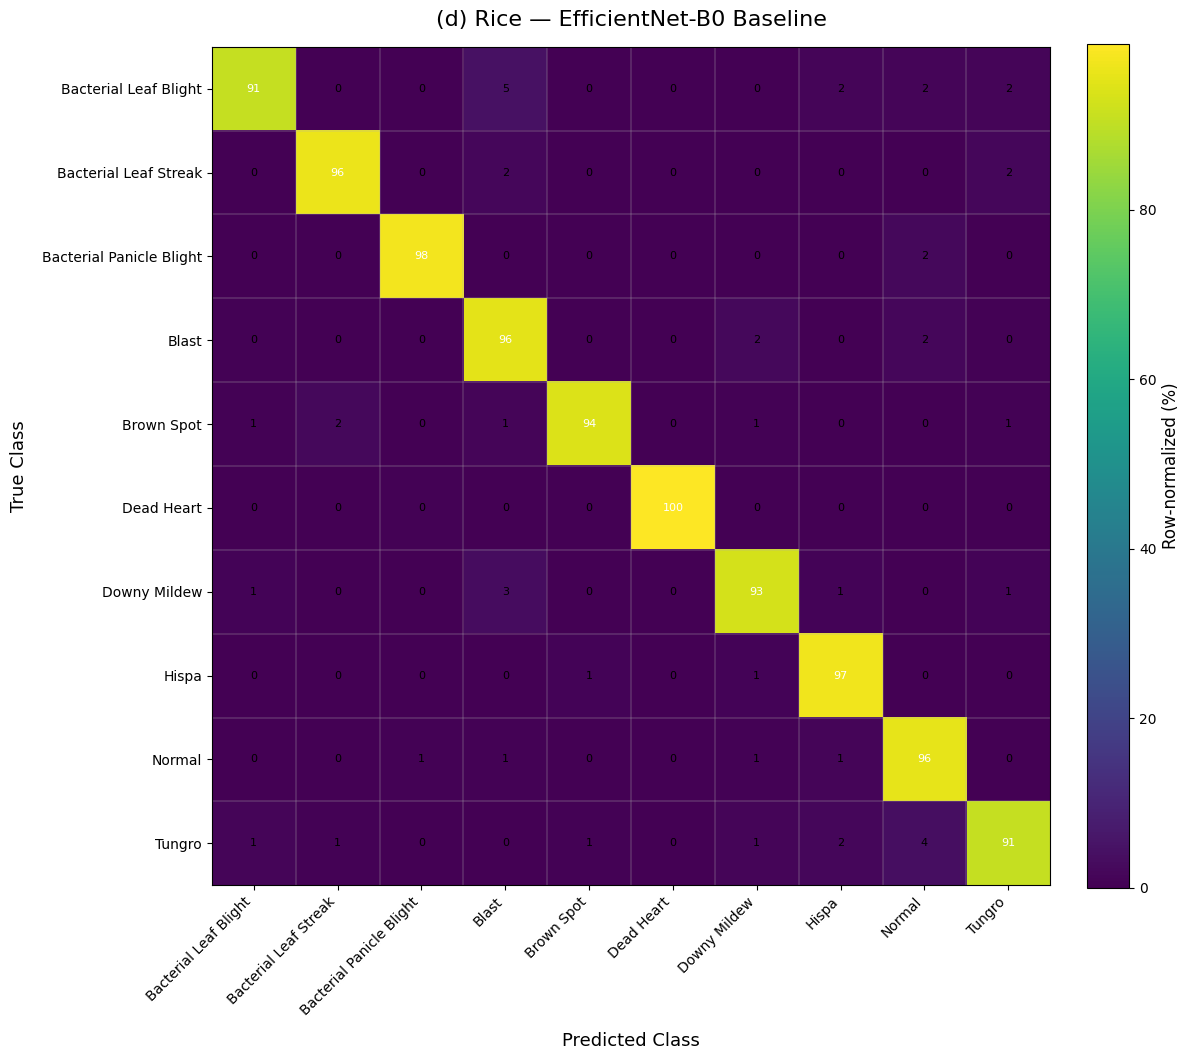

Saved: /kaggle/working/wheat_rice_journal/final_evaluation/paper_figures/Figure_2d_Rice_EfficientNet_B0_Baseline_CM.png


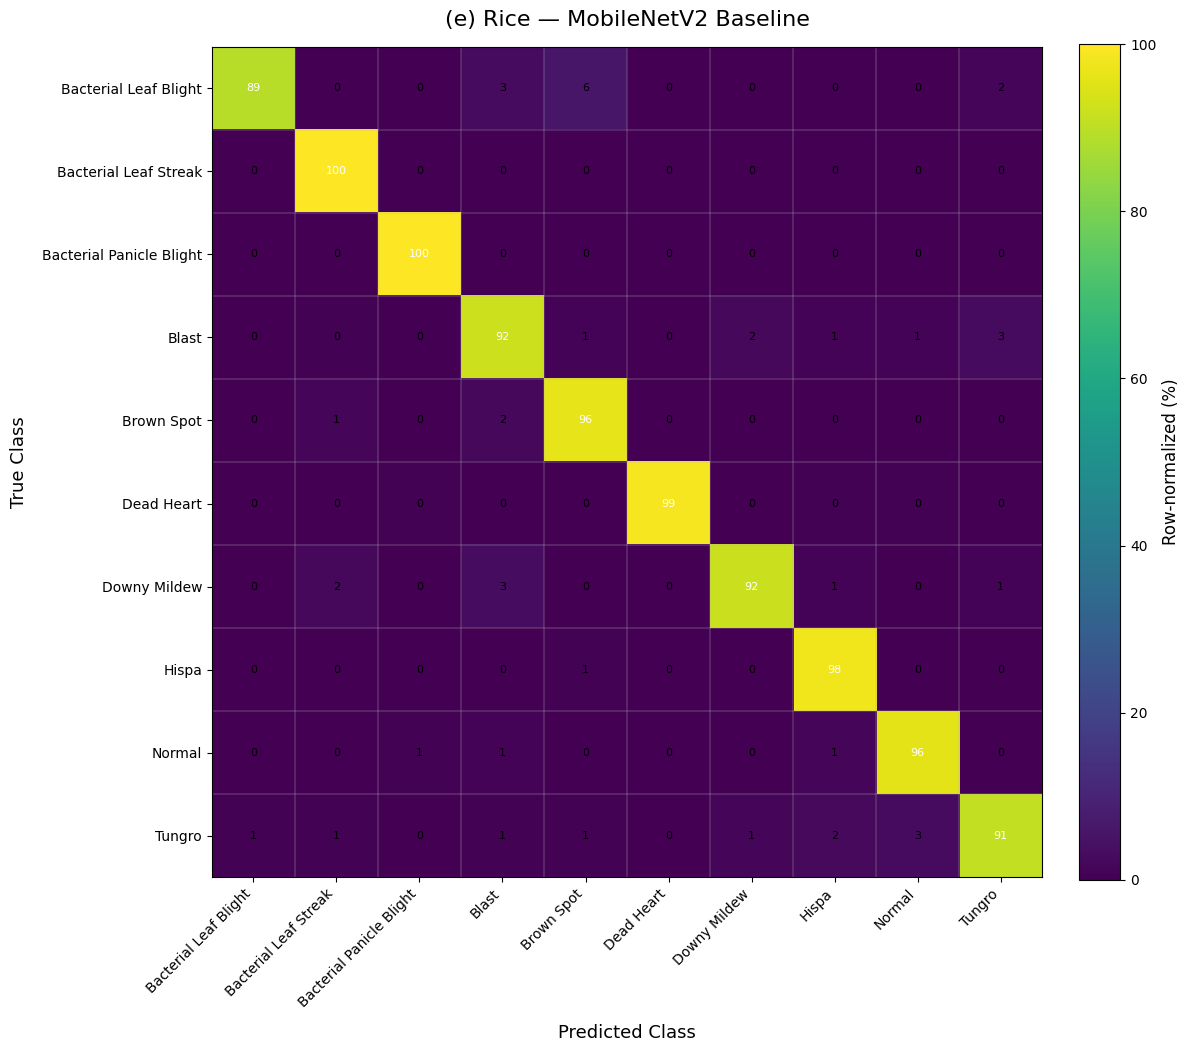

Saved: /kaggle/working/wheat_rice_journal/final_evaluation/paper_figures/Figure_2e_Rice_MobileNetV2_Baseline_CM.png


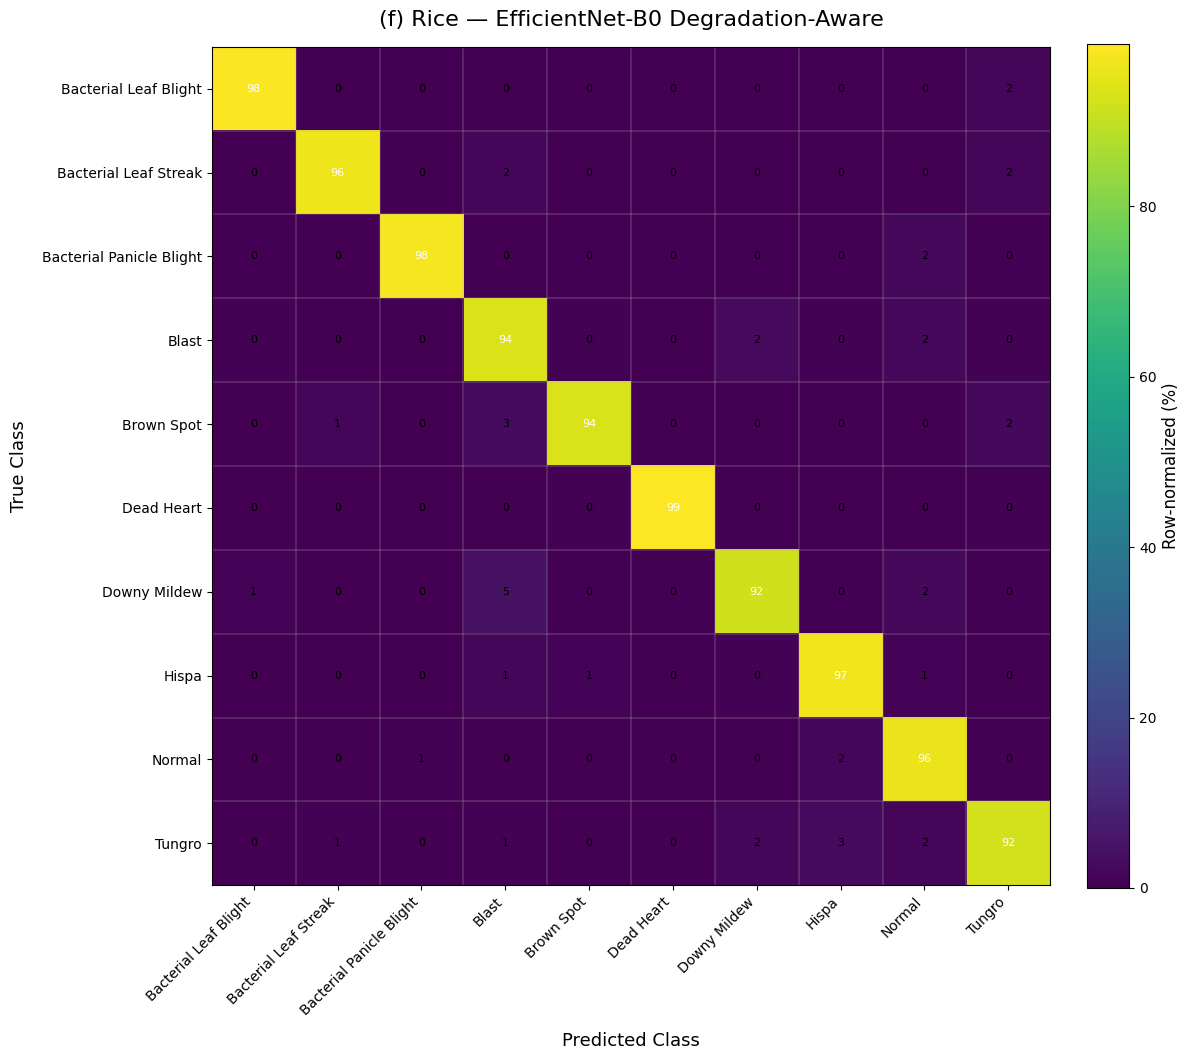

Saved: /kaggle/working/wheat_rice_journal/final_evaluation/paper_figures/Figure_2f_Rice_EfficientNet_B0_Degradation_Aware_CM.png

FIGURE 2 CONFUSION MATRICES GENERATED SUCCESSFULLY

Output folder:
/kaggle/working/wheat_rice_journal/final_evaluation/paper_figures

Six files generated:
Figure_2_Six_Confusion_Matrices.png
Figure_2a_Wheat_EfficientNet_B0_Baseline_CM.png
Figure_2b_Wheat_MobileNetV2_Baseline_CM.png
Figure_2c_Wheat_EfficientNet_B0_Degradation_Aware_CM.png
Figure_2d_Rice_EfficientNet_B0_Baseline_CM.png
Figure_2e_Rice_MobileNetV2_Baseline_CM.png
Figure_2f_Rice_EfficientNet_B0_Degradation_Aware_CM.png


In [17]:
# ============================================================
# FIGURE 2 — HIGH-RESOLUTION CONFUSION MATRICES
# Directly from saved predictions
# NO RETRAINING / NO MODEL INFERENCE
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------
ROOT = Path("/kaggle/working/wheat_rice_journal")

PRED_FILE = (
    ROOT
    / "final_evaluation"
    / "degraded"
    / "degraded_test_predictions.csv"
)

FIG_DIR = (
    ROOT
    / "final_evaluation"
    / "paper_figures"
)

FIG_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# LOAD SAVED PREDICTIONS
# ------------------------------------------------------------
df = pd.read_csv(PRED_FILE)

# Only clean test predictions
clean = df[df["condition"] == "clean"].copy()

print("Loaded:", PRED_FILE)
print("Clean prediction rows:", len(clean))

# ------------------------------------------------------------
# MODEL ORDER
# ------------------------------------------------------------
MODEL_ORDER = [
    "efficientnet_b0_baseline",
    "mobilenet_v2_baseline",
    "efficientnet_b0_degradation"
]

MODEL_LABELS = {
    "efficientnet_b0_baseline":
        "EfficientNet-B0 Baseline",

    "mobilenet_v2_baseline":
        "MobileNetV2 Baseline",

    "efficientnet_b0_degradation":
        "EfficientNet-B0 Degradation-Aware"
}


# ============================================================
# FUNCTION — CREATE ONE LARGE CONFUSION MATRIX
# ============================================================

def create_confusion_matrix(
    crop_name,
    experiment,
    panel_label,
    output_name
):

    data = clean[
        (clean["crop"].astype(str).str.lower() == crop_name.lower()) &
        (clean["experiment"] == experiment)
    ].copy()

    if data.empty:
        raise ValueError(
            f"No data found for {crop_name} / {experiment}"
        )

    # --------------------------------------------------------
    # CLASS ORDER
    # --------------------------------------------------------
    class_info = (
        data[["label", "label_id"]]
        .drop_duplicates()
        .sort_values("label_id")
    )

    labels = class_info["label_id"].astype(int).tolist()
    class_names = class_info["label"].tolist()

    pretty_names = [
        str(x).replace("_", " ").title()
        for x in class_names
    ]

    # --------------------------------------------------------
    # CONFUSION MATRIX
    # --------------------------------------------------------
    y_true = data["label_id"].astype(int)
    y_pred = data["prediction"].astype(int)

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=labels
    )

    # --------------------------------------------------------
    # ROW NORMALIZATION (%)
    # --------------------------------------------------------
    row_totals = cm.sum(axis=1, keepdims=True)

    cm_percent = np.divide(
        cm * 100.0,
        row_totals,
        out=np.zeros_like(cm, dtype=float),
        where=row_totals != 0
    )

    # --------------------------------------------------------
    # LARGE FIGURE
    # --------------------------------------------------------
    n_classes = len(class_names)

    fig_size = max(12, n_classes * 0.85)

    fig, ax = plt.subplots(
        figsize=(fig_size, fig_size)
    )

    # Do NOT specify a color map; matplotlib default is used.
    im = ax.imshow(
        cm_percent,
        interpolation="nearest",
        aspect="equal"
    )

    # --------------------------------------------------------
    # TITLE
    # --------------------------------------------------------
    ax.set_title(
        f"({panel_label}) {crop_name.title()} — "
        f"{MODEL_LABELS[experiment]}",
        fontsize=16,
        pad=15
    )

    # --------------------------------------------------------
    # AXES
    # --------------------------------------------------------
    ax.set_xlabel(
        "Predicted Class",
        fontsize=13,
        labelpad=10
    )

    ax.set_ylabel(
        "True Class",
        fontsize=13,
        labelpad=10
    )

    ax.set_xticks(
        np.arange(n_classes)
    )

    ax.set_yticks(
        np.arange(n_classes)
    )

    ax.set_xticklabels(
        pretty_names,
        rotation=45,
        ha="right",
        fontsize=10
    )

    ax.set_yticklabels(
        pretty_names,
        fontsize=10
    )

    # --------------------------------------------------------
    # ANNOTATIONS
    # --------------------------------------------------------
    max_value = cm_percent.max()

    for i in range(n_classes):
        for j in range(n_classes):

            value = cm_percent[i, j]

            # Show all values, but keep font small enough
            # for 15x15 wheat matrix.
            ax.text(
                j,
                i,
                f"{value:.0f}",
                ha="center",
                va="center",
                fontsize=8,
                color="white" if value > max_value * 0.5 else "black"
            )

    # --------------------------------------------------------
    # COLORBAR
    # --------------------------------------------------------
    cbar = fig.colorbar(
        im,
        ax=ax,
        fraction=0.046,
        pad=0.04
    )

    cbar.set_label(
        "Row-normalized (%)",
        fontsize=12
    )

    cbar.ax.tick_params(
        labelsize=10
    )

    # --------------------------------------------------------
    # GRID
    # --------------------------------------------------------
    ax.set_xticks(
        np.arange(n_classes) - 0.5,
        minor=True
    )

    ax.set_yticks(
        np.arange(n_classes) - 0.5,
        minor=True
    )

    ax.grid(
        which="minor",
        linewidth=0.3
    )

    ax.tick_params(
        which="minor",
        bottom=False,
        left=False
    )

    plt.tight_layout()

    # --------------------------------------------------------
    # SAVE
    # --------------------------------------------------------
    output_path = FIG_DIR / output_name

    plt.savefig(
        output_path,
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

    print("Saved:", output_path)


# ============================================================
# WHEAT — 3 SEPARATE MATRICES
# ============================================================

create_confusion_matrix(
    "wheat",
    "efficientnet_b0_baseline",
    "a",
    "Figure_2a_Wheat_EfficientNet_B0_Baseline_CM.png"
)

create_confusion_matrix(
    "wheat",
    "mobilenet_v2_baseline",
    "b",
    "Figure_2b_Wheat_MobileNetV2_Baseline_CM.png"
)

create_confusion_matrix(
    "wheat",
    "efficientnet_b0_degradation",
    "c",
    "Figure_2c_Wheat_EfficientNet_B0_Degradation_Aware_CM.png"
)


# ============================================================
# RICE — 3 SEPARATE MATRICES
# ============================================================

create_confusion_matrix(
    "rice",
    "efficientnet_b0_baseline",
    "d",
    "Figure_2d_Rice_EfficientNet_B0_Baseline_CM.png"
)

create_confusion_matrix(
    "rice",
    "mobilenet_v2_baseline",
    "e",
    "Figure_2e_Rice_MobileNetV2_Baseline_CM.png"
)

create_confusion_matrix(
    "rice",
    "efficientnet_b0_degradation",
    "f",
    "Figure_2f_Rice_EfficientNet_B0_Degradation_Aware_CM.png"
)


# ============================================================
# COMPLETE
# ============================================================

print("\n" + "=" * 75)
print("FIGURE 2 CONFUSION MATRICES GENERATED SUCCESSFULLY")
print("=" * 75)

print("\nOutput folder:")
print(FIG_DIR)

print("\nSix files generated:")
for f in sorted(FIG_DIR.glob("Figure_2*.png")):
    print(f.name)

Clean prediction rows: 9561


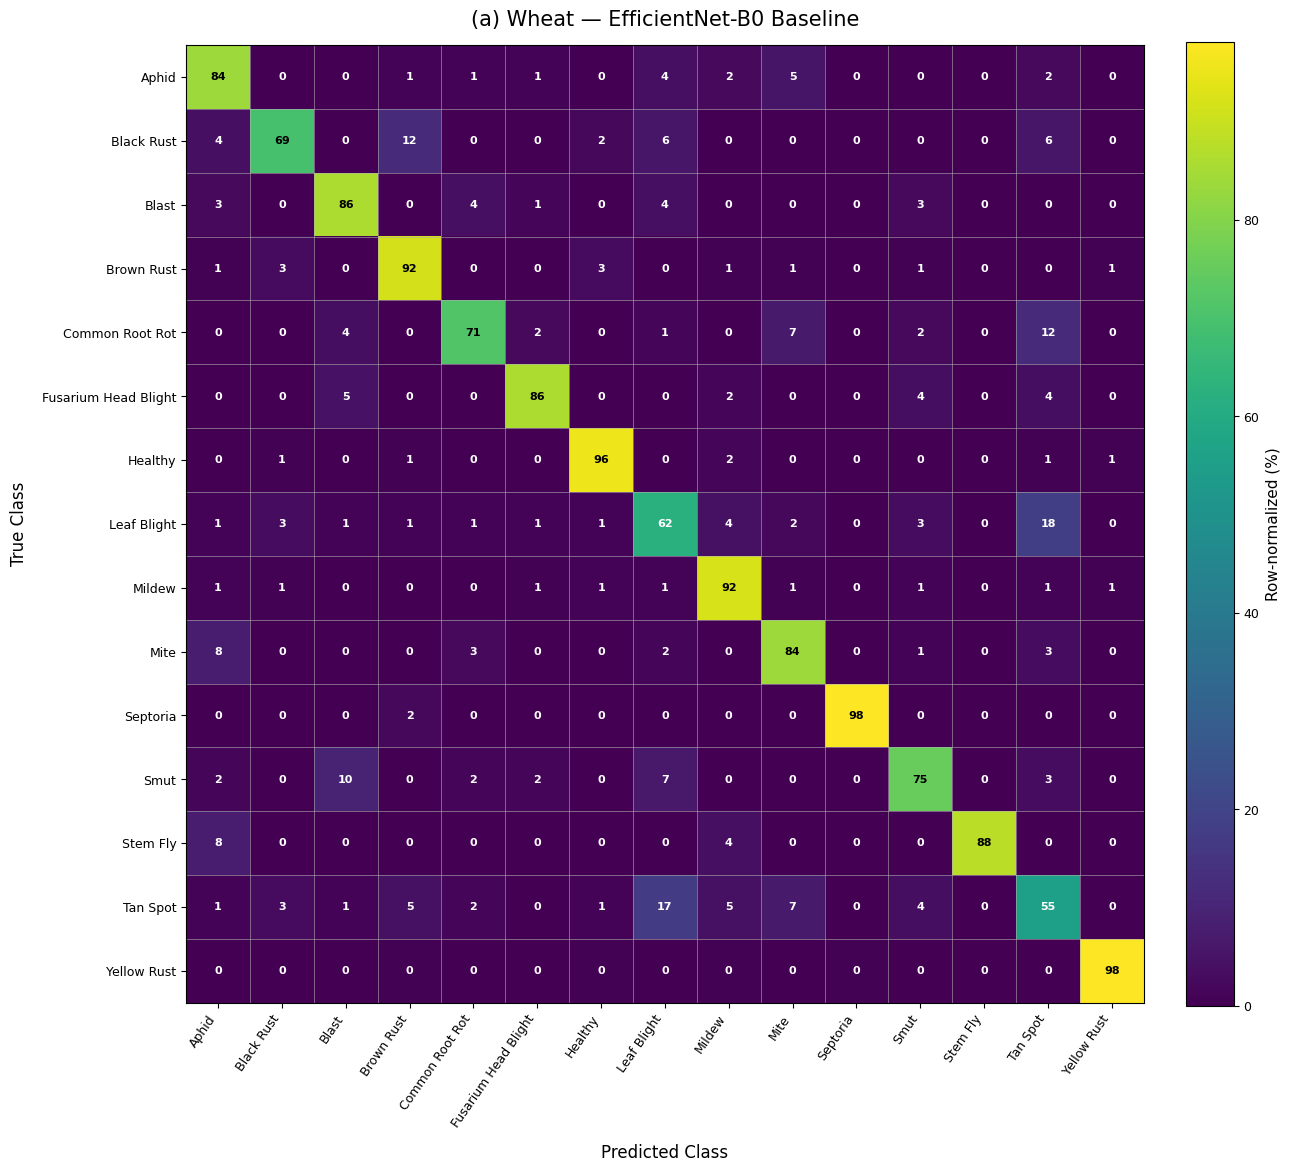

Saved: /kaggle/working/wheat_rice_journal/final_evaluation/paper_figures/Figure_2a_Wheat_EfficientNet_B0_Baseline_CM.png


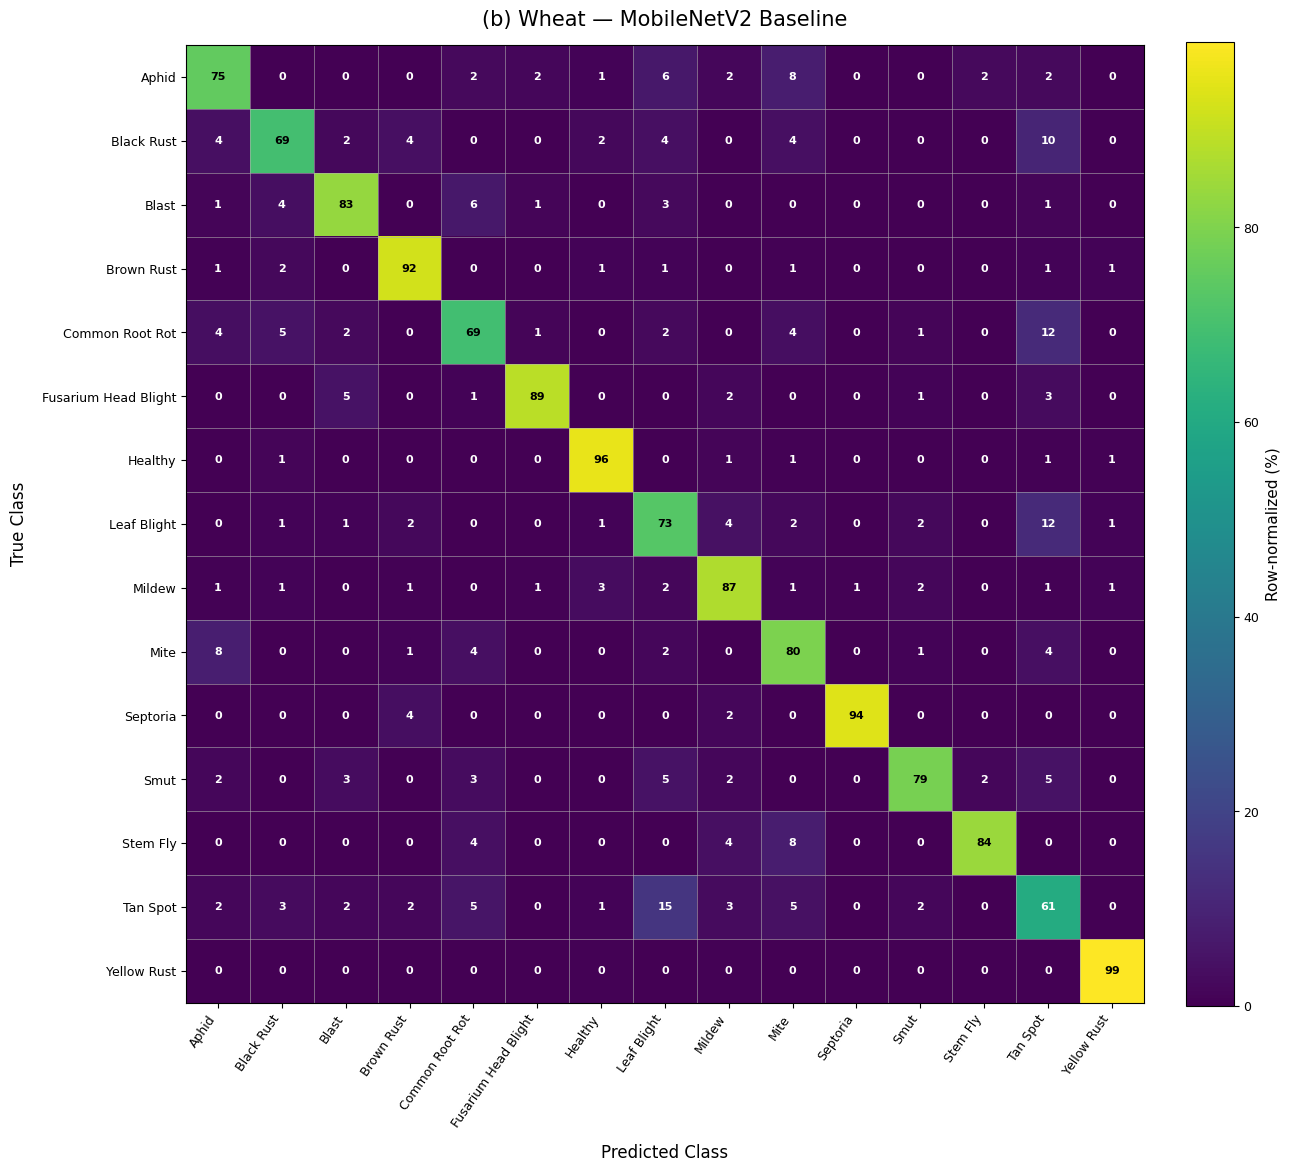

Saved: /kaggle/working/wheat_rice_journal/final_evaluation/paper_figures/Figure_2b_Wheat_MobileNetV2_Baseline_CM.png


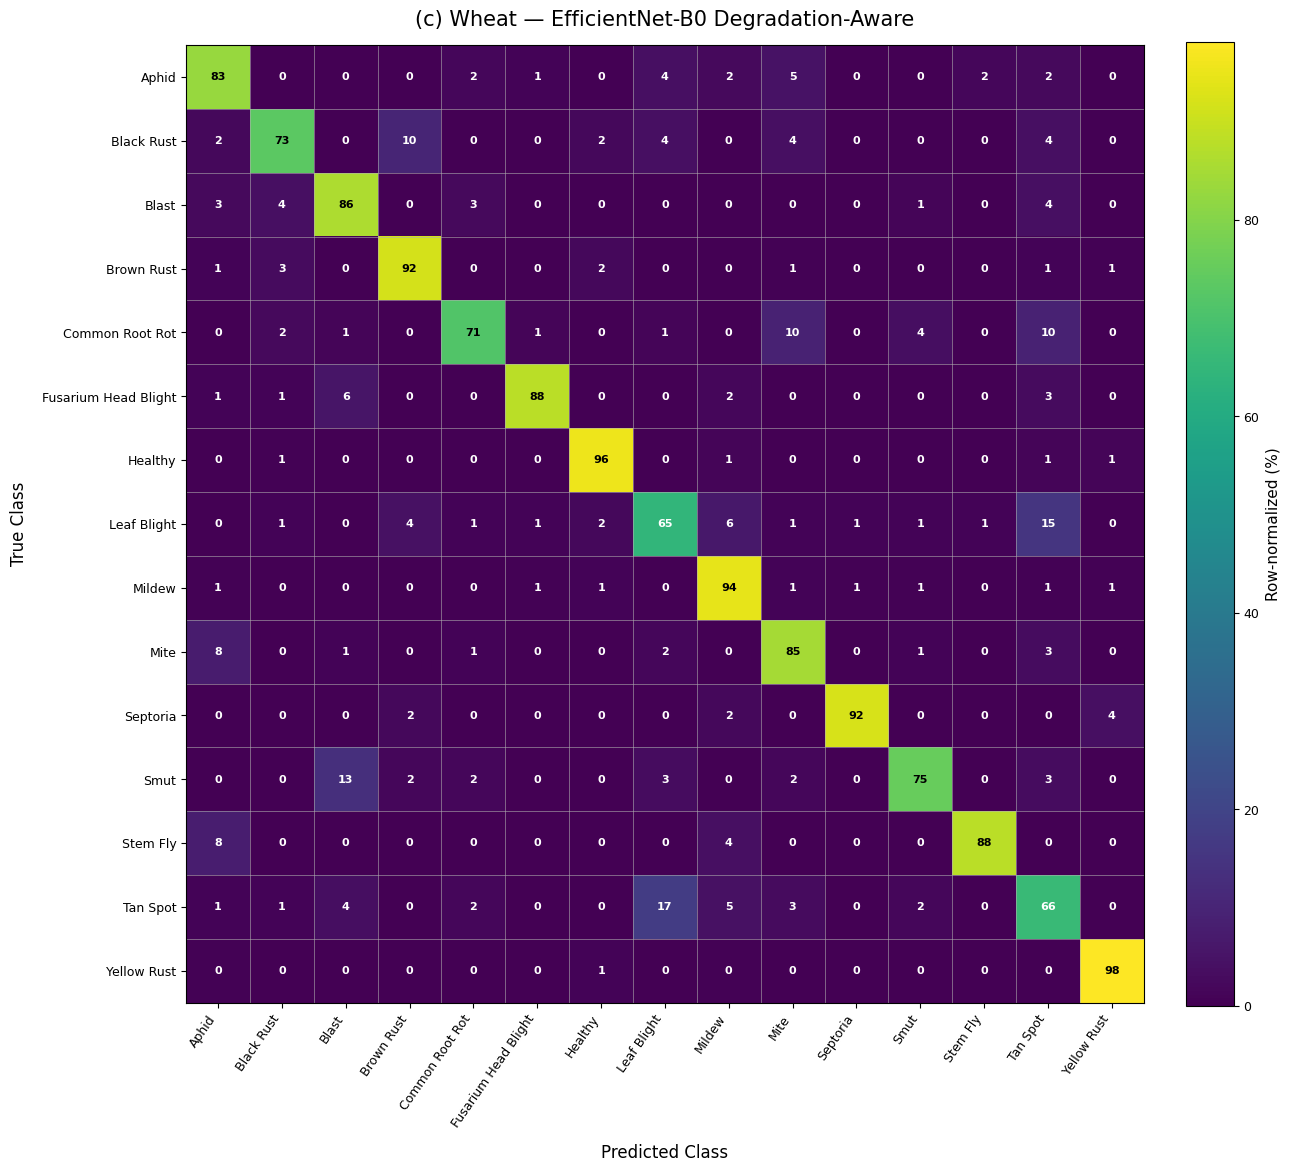

Saved: /kaggle/working/wheat_rice_journal/final_evaluation/paper_figures/Figure_2c_Wheat_EfficientNet_B0_Degradation_Aware_CM.png


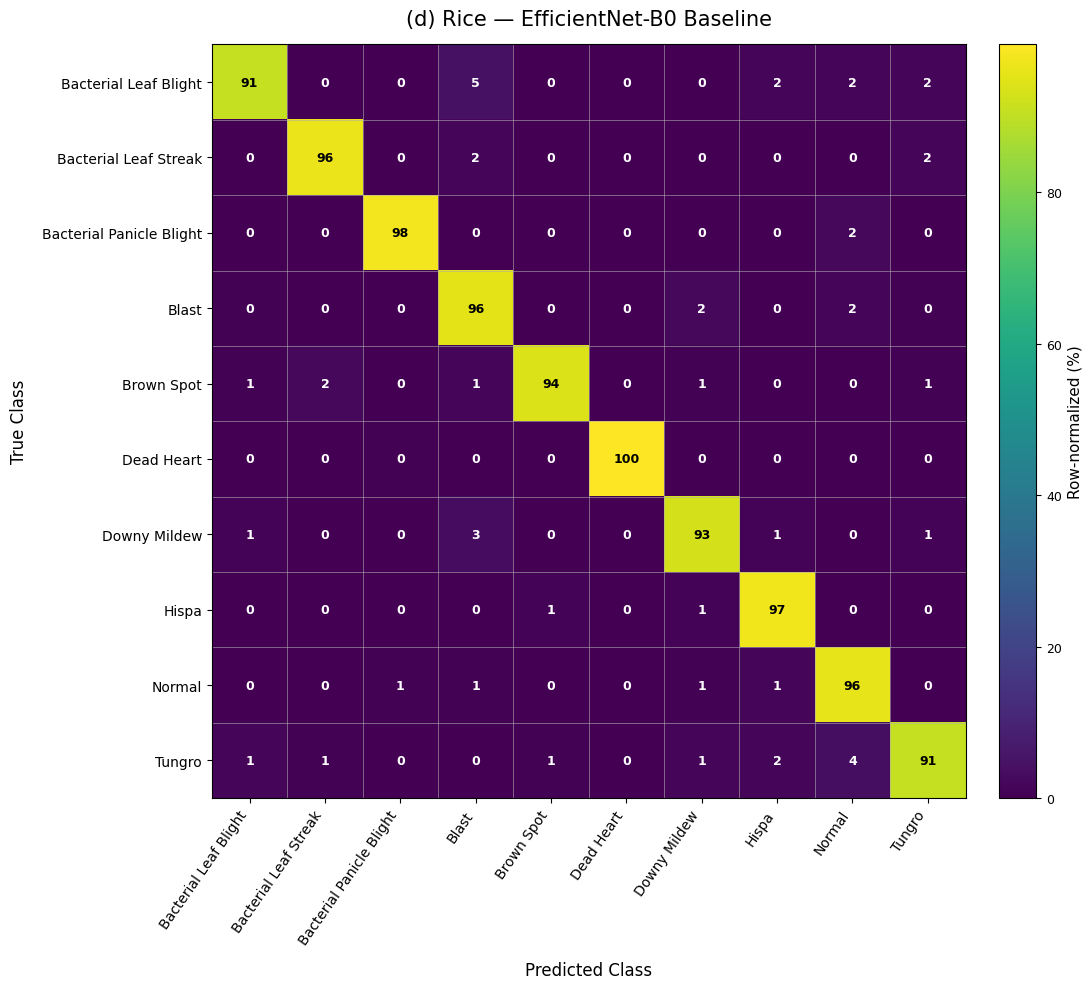

Saved: /kaggle/working/wheat_rice_journal/final_evaluation/paper_figures/Figure_2d_Rice_EfficientNet_B0_Baseline_CM.png


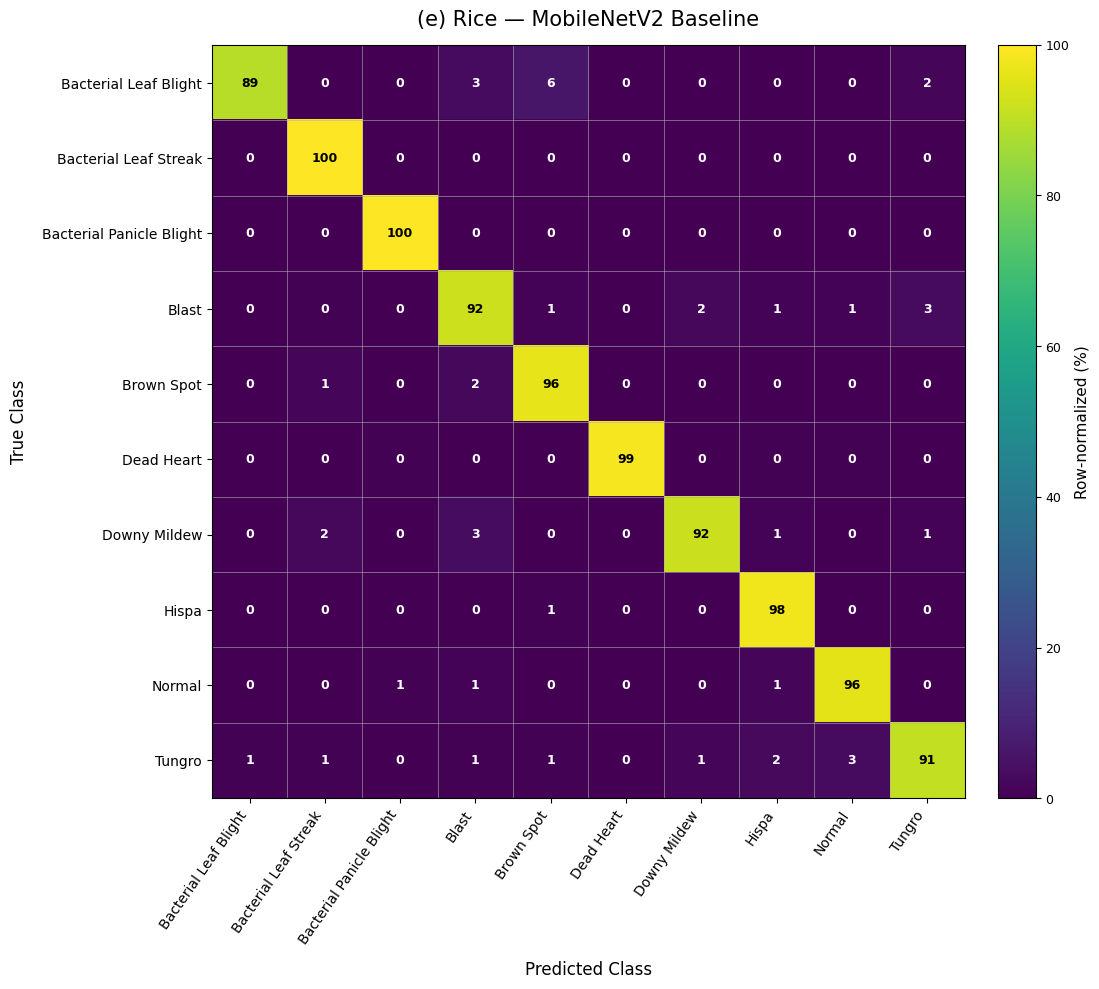

Saved: /kaggle/working/wheat_rice_journal/final_evaluation/paper_figures/Figure_2e_Rice_MobileNetV2_Baseline_CM.png


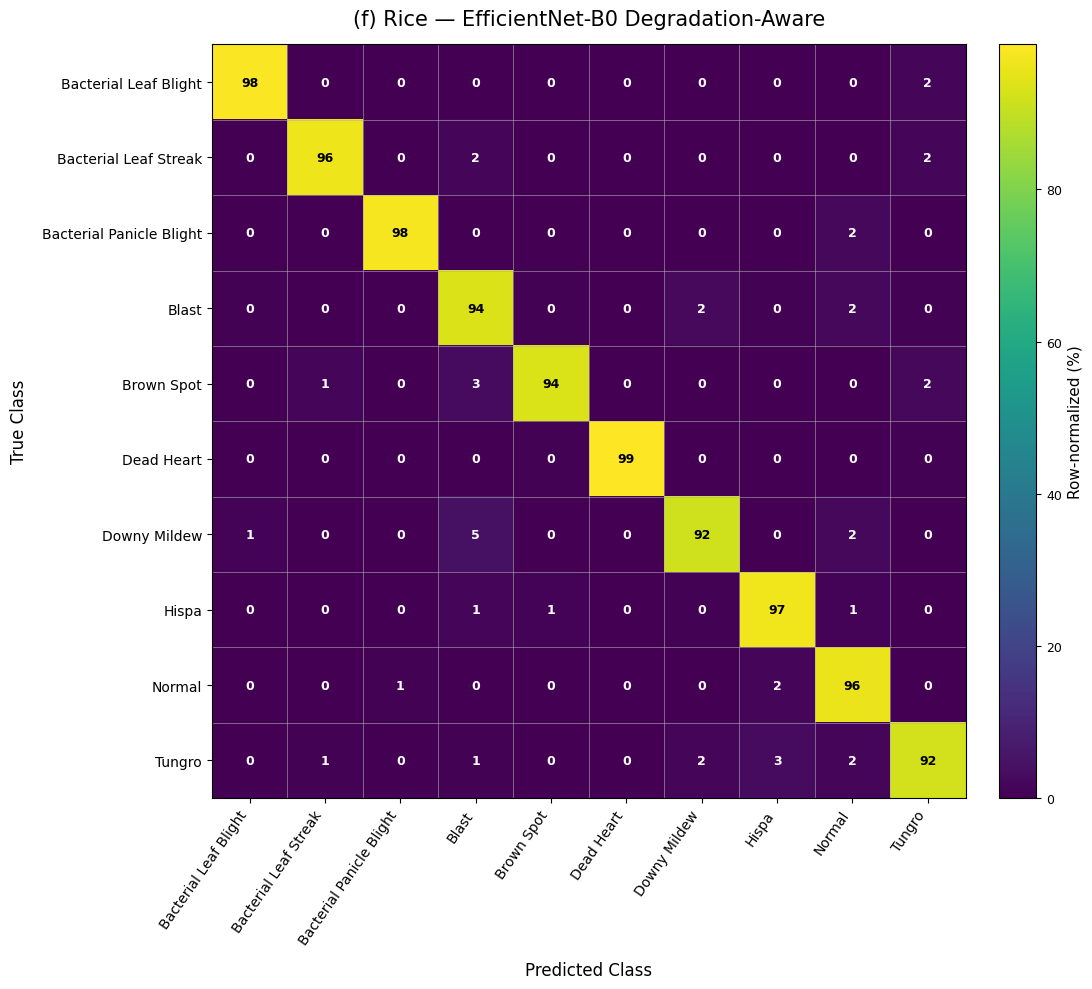

Saved: /kaggle/working/wheat_rice_journal/final_evaluation/paper_figures/Figure_2f_Rice_EfficientNet_B0_Degradation_Aware_CM.png

FIGURE 2 — READABLE CONFUSION MATRICES COMPLETE


In [18]:
# ============================================================
# FIGURE 2 — READABLE HIGH-RESOLUTION CONFUSION MATRICES
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import matplotlib as mpl

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------
ROOT = Path("/kaggle/working/wheat_rice_journal")

PRED_FILE = (
    ROOT
    / "final_evaluation"
    / "degraded"
    / "degraded_test_predictions.csv"
)

FIG_DIR = ROOT / "final_evaluation" / "paper_figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# LOAD SAVED PREDICTIONS
# ------------------------------------------------------------
df = pd.read_csv(PRED_FILE)

clean = df[df["condition"] == "clean"].copy()

print("Clean prediction rows:", len(clean))

# ------------------------------------------------------------
# MODELS
# ------------------------------------------------------------
MODEL_ORDER = [
    "efficientnet_b0_baseline",
    "mobilenet_v2_baseline",
    "efficientnet_b0_degradation"
]

MODEL_LABELS = {
    "efficientnet_b0_baseline":
        "EfficientNet-B0 Baseline",

    "mobilenet_v2_baseline":
        "MobileNetV2 Baseline",

    "efficientnet_b0_degradation":
        "EfficientNet-B0 Degradation-Aware"
}


# ============================================================
# FUNCTION
# ============================================================

def make_cm(crop_name, experiment, panel_label, output_name):

    data = clean[
        (clean["crop"].astype(str).str.lower() == crop_name.lower()) &
        (clean["experiment"] == experiment)
    ].copy()

    if data.empty:
        raise ValueError(
            f"No data found for {crop_name} / {experiment}"
        )

    # --------------------------------------------------------
    # CLASS ORDER
    # --------------------------------------------------------
    class_info = (
        data[["label", "label_id"]]
        .drop_duplicates()
        .sort_values("label_id")
    )

    labels = class_info["label_id"].astype(int).tolist()
    class_names = class_info["label"].tolist()

    display_names = [
        str(x).replace("_", " ").title()
        for x in class_names
    ]

    # --------------------------------------------------------
    # CONFUSION MATRIX
    # --------------------------------------------------------
    y_true = data["label_id"].astype(int)
    y_pred = data["prediction"].astype(int)

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=labels
    )

    # --------------------------------------------------------
    # ROW NORMALIZATION
    # --------------------------------------------------------
    row_sum = cm.sum(axis=1, keepdims=True)

    cm_pct = np.divide(
        cm * 100.0,
        row_sum,
        out=np.zeros_like(cm, dtype=float),
        where=row_sum != 0
    )

    n = len(class_names)

    # --------------------------------------------------------
    # FIGURE SIZE
    # --------------------------------------------------------
    if n == 15:
        figsize = (13, 12)
        tick_size = 9
        number_size = 8
    else:
        figsize = (11, 10)
        tick_size = 10
        number_size = 9

    fig, ax = plt.subplots(figsize=figsize)

    # --------------------------------------------------------
    # HEATMAP
    # --------------------------------------------------------
    im = ax.imshow(
        cm_pct,
        interpolation="nearest",
        aspect="equal"
    )

    # Get normalization used by imshow
    norm = im.norm
    cmap = im.cmap

    # --------------------------------------------------------
    # TITLE
    # --------------------------------------------------------
    ax.set_title(
        f"({panel_label}) {crop_name.title()} — "
        f"{MODEL_LABELS[experiment]}",
        fontsize=15,
        pad=14
    )

    # --------------------------------------------------------
    # AXES
    # --------------------------------------------------------
    ax.set_xlabel(
        "Predicted Class",
        fontsize=12,
        labelpad=10
    )

    ax.set_ylabel(
        "True Class",
        fontsize=12,
        labelpad=10
    )

    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))

    ax.set_xticklabels(
        display_names,
        rotation=55,
        ha="right",
        fontsize=tick_size
    )

    ax.set_yticklabels(
        display_names,
        fontsize=tick_size
    )

    # --------------------------------------------------------
    # CELL GRID
    # --------------------------------------------------------
    ax.set_xticks(
        np.arange(n + 1) - 0.5,
        minor=True
    )

    ax.set_yticks(
        np.arange(n + 1) - 0.5,
        minor=True
    )

    ax.grid(
        which="minor",
        linewidth=0.4
    )

    ax.tick_params(
        which="minor",
        bottom=False,
        left=False
    )

    # --------------------------------------------------------
    # VISIBLE NUMBERS
    # --------------------------------------------------------
    # Determine text color from actual displayed background.
    # Dark background -> white text
    # Light background -> black text
    for i in range(n):

        for j in range(n):

            value = cm_pct[i, j]

            rgba = cmap(norm(value))

            r, g, b = rgba[:3]

            # Relative perceived brightness
            luminance = (
                0.299 * r +
                0.587 * g +
                0.114 * b
            )

            text_color = "white" if luminance < 0.55 else "black"

            ax.text(
                j,
                i,
                f"{value:.0f}",
                ha="center",
                va="center",
                fontsize=number_size,
                fontweight="bold",
                color=text_color
            )

    # --------------------------------------------------------
    # COLORBAR
    # --------------------------------------------------------
    cbar = fig.colorbar(
        im,
        ax=ax,
        fraction=0.046,
        pad=0.04
    )

    cbar.set_label(
        "Row-normalized (%)",
        fontsize=11
    )

    cbar.ax.tick_params(
        labelsize=9
    )

    # --------------------------------------------------------
    # SAVE
    # --------------------------------------------------------
    output_path = FIG_DIR / output_name

    plt.tight_layout()

    plt.savefig(
        output_path,
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

    print("Saved:", output_path)


# ============================================================
# WHEAT
# ============================================================

make_cm(
    "wheat",
    "efficientnet_b0_baseline",
    "a",
    "Figure_2a_Wheat_EfficientNet_B0_Baseline_CM.png"
)

make_cm(
    "wheat",
    "mobilenet_v2_baseline",
    "b",
    "Figure_2b_Wheat_MobileNetV2_Baseline_CM.png"
)

make_cm(
    "wheat",
    "efficientnet_b0_degradation",
    "c",
    "Figure_2c_Wheat_EfficientNet_B0_Degradation_Aware_CM.png"
)


# ============================================================
# RICE
# ============================================================

make_cm(
    "rice",
    "efficientnet_b0_baseline",
    "d",
    "Figure_2d_Rice_EfficientNet_B0_Baseline_CM.png"
)

make_cm(
    "rice",
    "mobilenet_v2_baseline",
    "e",
    "Figure_2e_Rice_MobileNetV2_Baseline_CM.png"
)

make_cm(
    "rice",
    "efficientnet_b0_degradation",
    "f",
    "Figure_2f_Rice_EfficientNet_B0_Degradation_Aware_CM.png"
)


print("\n" + "=" * 75)
print("FIGURE 2 — READABLE CONFUSION MATRICES COMPLETE")
print("=" * 75)

Loaded: /kaggle/working/wheat_rice_journal/final_evaluation/degraded/robustness_results_with_drop.csv

Clean results:


,crop,experiment,condition,degradation_type,severity,parameter,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,evaluation_seconds,clean_accuracy,clean_balanced_accuracy,clean_macro_f1,accuracy_drop,balanced_accuracy_drop,macro_f1_drop,accuracy_drop_pp,macro_f1_drop_pp
0,wheat,efficientnet_b0_baseline,clean,clean,0,{'parameter': 'none'},0.848225,0.824810,0.834607,0.824810,0.828789,60.584102,0.848225,0.824810,0.828789,0.0,0.0,0.0,0.0,0.0
10,wheat,mobilenet_v2_baseline,clean,clean,0,{'parameter': 'none'},0.843329,0.820264,0.822729,0.820264,0.820826,35.145440,0.843329,0.820264,0.820826,0.0,0.0,0.0,0.0,0.0
20,wheat,efficientnet_b0_degradation,clean,clean,0,{'parameter': 'none'},0.859853,0.835184,0.843905,0.835184,0.838429,30.837771,0.859853,0.835184,0.838429,0.0,0.0,0.0,0.0,0.0
30,rice,efficientnet_b0_baseline,clean,clean,0,{'parameter': 'none'},0.956214,0.952018,0.945440,0.952018,0.948413,27.815447,0.956214,0.952018,0.948413,0.0,0.0,0.0,0.0,0.0
40,rice,mobilenet_v2_baseline,clean,clean,0,{'parameter': 'none'},0.952994,0.953420,0.946787,0.953420,0.949473,14.210879,0.952994,0.953420,0.949473,0.0,0.0,0.0,0.0,0.0
50,rice,efficientnet_b0_degradation,clean,clean,0,{'parameter': 'none'},0.956214,0.956854,0.953373,0.956854,0.955014,12.238796,0.956214,0.956854,0.955014,0.0,0.0,0.0,0.0,0.0


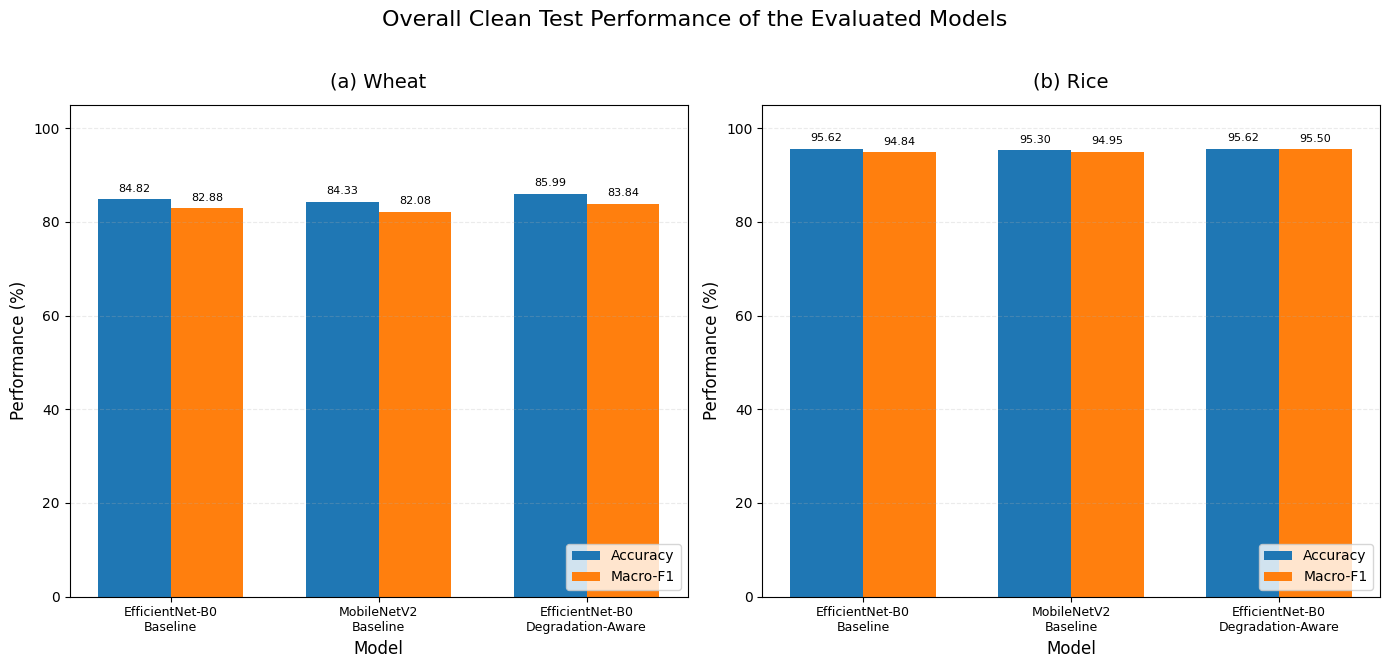


FIGURE 1 GENERATED
PNG: /kaggle/working/wheat_rice_journal/final_evaluation/paper_figures/Figure_1_Overall_Clean_Test_Performance.png
PDF: /kaggle/working/wheat_rice_journal/final_evaluation/paper_figures/Figure_1_Overall_Clean_Test_Performance.pdf


In [19]:
# ============================================================
# FIGURE 1 — OVERALL CLEAN TEST PERFORMANCE
# Wheat + Rice
# Uses already saved robustness results
# NO RETRAINING / NO INFERENCE
# ============================================================

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------
ROOT = Path("/kaggle/working/wheat_rice_journal")

INPUT_FILE = (
    ROOT
    / "final_evaluation"
    / "degraded"
    / "robustness_results_with_drop.csv"
)

FIG_DIR = ROOT / "final_evaluation" / "paper_figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# LOAD RESULTS
# ------------------------------------------------------------
df = pd.read_csv(INPUT_FILE)

# Only clean test results
clean = df[df["condition"] == "clean"].copy()

print("Loaded:", INPUT_FILE)
print("\nClean results:")
display(clean)

# ------------------------------------------------------------
# MODEL LABELS
# ------------------------------------------------------------
MODEL_ORDER = [
    "efficientnet_b0_baseline",
    "mobilenet_v2_baseline",
    "efficientnet_b0_degradation"
]

MODEL_LABELS = {
    "efficientnet_b0_baseline":
        "EfficientNet-B0 Baseline",

    "mobilenet_v2_baseline":
        "MobileNetV2 Baseline",

    "efficientnet_b0_degradation":
        "EfficientNet-B0 Degradation-Aware"
}

# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6.5)
)

for ax, crop_name in zip(
    axes,
    ["wheat", "rice"]
):

    data = clean[
        clean["crop"].astype(str).str.lower() == crop_name
    ].copy()

    data["Model Label"] = data["experiment"].map(
        MODEL_LABELS
    )

    data["Model Order"] = data["experiment"].map({
        model: i
        for i, model in enumerate(MODEL_ORDER)
    })

    data = data.sort_values("Model Order")

    x = np.arange(len(data))
    width = 0.35

    # Accuracy
    ax.bar(
        x - width / 2,
        data["accuracy"] * 100,
        width,
        label="Accuracy"
    )

    # Macro-F1
    ax.bar(
        x + width / 2,
        data["macro_f1"] * 100,
        width,
        label="Macro-F1"
    )

    # --------------------------------------------------------
    # AXES
    # --------------------------------------------------------
    ax.set_title(
        f"({chr(97 + list(axes).index(ax))}) "
        f"{crop_name.title()}",
        fontsize=14,
        pad=12
    )

    ax.set_ylabel(
        "Performance (%)",
        fontsize=12
    )

    ax.set_xlabel(
        "Model",
        fontsize=12
    )

    ax.set_xticks(x)

    ax.set_xticklabels(
        [
            "EfficientNet-B0\nBaseline",
            "MobileNetV2\nBaseline",
            "EfficientNet-B0\nDegradation-Aware"
        ],
        fontsize=9
    )

    ax.set_ylim(0, 105)

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.25
    )

    # --------------------------------------------------------
    # VALUE LABELS
    # --------------------------------------------------------
    for i, value in enumerate(data["accuracy"] * 100):
        ax.text(
            i - width / 2,
            value + 1.2,
            f"{value:.2f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

    for i, value in enumerate(data["macro_f1"] * 100):
        ax.text(
            i + width / 2,
            value + 1.2,
            f"{value:.2f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

    ax.legend(
        fontsize=10,
        loc="lower right"
    )

# ------------------------------------------------------------
# FIGURE TITLE
# ------------------------------------------------------------
fig.suptitle(
    "Overall Clean Test Performance of the Evaluated Models",
    fontsize=16,
    y=1.02
)

plt.tight_layout()

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------
PNG_FILE = (
    FIG_DIR
    / "Figure_1_Overall_Clean_Test_Performance.png"
)

PDF_FILE = (
    FIG_DIR
    / "Figure_1_Overall_Clean_Test_Performance.pdf"
)

plt.savefig(
    PNG_FILE,
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    PDF_FILE,
    bbox_inches="tight"
)

plt.show()

print("\n" + "=" * 70)
print("FIGURE 1 GENERATED")
print("=" * 70)

print("PNG:", PNG_FILE)
print("PDF:", PDF_FILE)

In [20]:
# ============================================================
# FIX MISSING CLEAN METRICS IN ROBUSTNESS RESULTS
# Uses saved image-level predictions
# NO RETRAINING / NO MODEL INFERENCE
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------
ROOT = Path("/kaggle/working/wheat_rice_journal")

RESULT_FILE = (
    ROOT
    / "final_evaluation"
    / "degraded"
    / "robustness_results_with_drop.csv"
)

PRED_FILE = (
    ROOT
    / "final_evaluation"
    / "degraded"
    / "degraded_test_predictions.csv"
)

OUT_FILE = (
    ROOT
    / "final_evaluation"
    / "degraded"
    / "robustness_results_with_drop_FIXED.csv"
)

# ------------------------------------------------------------
# LOAD
# ------------------------------------------------------------
results = pd.read_csv(RESULT_FILE)
pred = pd.read_csv(PRED_FILE)

clean_pred = pred[
    pred["condition"].astype(str).str.lower() == "clean"
].copy()

print("Loaded results:", RESULT_FILE)
print("Loaded predictions:", PRED_FILE)
print("Clean prediction rows:", len(clean_pred))

# ------------------------------------------------------------
# REPAIR ALL CLEAN ROWS
# ------------------------------------------------------------
for idx, row in results[
    results["condition"].astype(str).str.lower() == "clean"
].iterrows():

    crop = str(row["crop"]).lower()
    experiment = str(row["experiment"])

    p = clean_pred[
        (clean_pred["crop"].astype(str).str.lower() == crop) &
        (clean_pred["experiment"] == experiment)
    ].copy()

    if p.empty:
        print(f"WARNING: no predictions found for {crop} / {experiment}")
        continue

    y_true = p["label_id"].astype(int)
    y_pred = p["prediction"].astype(int)

    acc = accuracy_score(y_true, y_pred)
    bal = balanced_accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    # --------------------------------------------------------
    # MAIN METRICS
    # --------------------------------------------------------
    results.loc[idx, "accuracy"] = acc
    results.loc[idx, "balanced_accuracy"] = bal
    results.loc[idx, "macro_precision"] = precision
    results.loc[idx, "macro_recall"] = recall
    results.loc[idx, "macro_f1"] = f1

    # --------------------------------------------------------
    # CLEAN REFERENCE
    # --------------------------------------------------------
    results.loc[idx, "clean_accuracy"] = acc
    results.loc[idx, "clean_balanced_accuracy"] = bal
    results.loc[idx, "clean_macro_f1"] = f1

    # Clean row has zero performance drop
    results.loc[idx, "accuracy_drop"] = 0.0
    results.loc[idx, "balanced_accuracy_drop"] = 0.0
    results.loc[idx, "macro_f1_drop"] = 0.0

    results.loc[idx, "accuracy_drop_pp"] = 0.0
    results.loc[idx, "macro_f1_drop_pp"] = 0.0

    print(
        f"{crop:5s} | {experiment:35s} | "
        f"Acc={acc*100:.2f}% | "
        f"Bal.Acc={bal*100:.2f}% | "
        f"Macro-F1={f1*100:.2f}%"
    )

# ------------------------------------------------------------
# SAVE FIXED FILE
# ------------------------------------------------------------
results.to_csv(
    OUT_FILE,
    index=False
)

print("\n" + "=" * 75)
print("FIXED RESULTS SAVED")
print("=" * 75)

print(OUT_FILE)

# ------------------------------------------------------------
# SHOW CLEAN RESULTS ONLY
# ------------------------------------------------------------
clean_fixed = results[
    results["condition"].astype(str).str.lower() == "clean"
][
    [
        "crop",
        "experiment",
        "accuracy",
        "balanced_accuracy",
        "macro_precision",
        "macro_recall",
        "macro_f1",
        "clean_accuracy",
        "clean_balanced_accuracy",
        "clean_macro_f1",
        "accuracy_drop_pp",
        "macro_f1_drop_pp"
    ]
].copy()

display(clean_fixed)

Loaded results: /kaggle/working/wheat_rice_journal/final_evaluation/degraded/robustness_results_with_drop.csv
Loaded predictions: /kaggle/working/wheat_rice_journal/final_evaluation/degraded/degraded_test_predictions.csv
Clean prediction rows: 9561
wheat | efficientnet_b0_baseline            | Acc=84.82% | Bal.Acc=82.48% | Macro-F1=82.88%
wheat | mobilenet_v2_baseline               | Acc=84.33% | Bal.Acc=82.03% | Macro-F1=82.08%
wheat | efficientnet_b0_degradation         | Acc=85.99% | Bal.Acc=83.52% | Macro-F1=83.84%
rice  | efficientnet_b0_baseline            | Acc=95.62% | Bal.Acc=95.20% | Macro-F1=94.84%
rice  | mobilenet_v2_baseline               | Acc=95.30% | Bal.Acc=95.34% | Macro-F1=94.95%
rice  | efficientnet_b0_degradation         | Acc=95.62% | Bal.Acc=95.69% | Macro-F1=95.50%

FIXED RESULTS SAVED
/kaggle/working/wheat_rice_journal/final_evaluation/degraded/robustness_results_with_drop_FIXED.csv


,crop,experiment,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,clean_accuracy,clean_balanced_accuracy,clean_macro_f1,accuracy_drop_pp,macro_f1_drop_pp
0,wheat,efficientnet_b0_baseline,0.848225,0.824810,0.834607,0.824810,0.828789,0.848225,0.824810,0.828789,0.0,0.0
10,wheat,mobilenet_v2_baseline,0.843329,0.820264,0.822729,0.820264,0.820826,0.843329,0.820264,0.820826,0.0,0.0
20,wheat,efficientnet_b0_degradation,0.859853,0.835184,0.843905,0.835184,0.838429,0.859853,0.835184,0.838429,0.0,0.0
30,rice,efficientnet_b0_baseline,0.956214,0.952018,0.945440,0.952018,0.948413,0.956214,0.952018,0.948413,0.0,0.0
40,rice,mobilenet_v2_baseline,0.952994,0.953420,0.946787,0.953420,0.949473,0.952994,0.953420,0.949473,0.0,0.0
50,rice,efficientnet_b0_degradation,0.956214,0.956854,0.953373,0.956854,0.955014,0.956214,0.956854,0.955014,0.0,0.0


In [21]:
# ============================================================
# FIX MISSING CLEAN METRICS IN ROBUSTNESS RESULTS
# Uses saved image-level predictions
# NO RETRAINING / NO MODEL INFERENCE
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------
ROOT = Path("/kaggle/working/wheat_rice_journal")

RESULT_FILE = (
    ROOT
    / "final_evaluation"
    / "degraded"
    / "robustness_results_with_drop.csv"
)

PRED_FILE = (
    ROOT
    / "final_evaluation"
    / "degraded"
    / "degraded_test_predictions.csv"
)

OUT_FILE = (
    ROOT
    / "final_evaluation"
    / "degraded"
    / "robustness_results_with_drop_FIXED.csv"
)

# ------------------------------------------------------------
# LOAD
# ------------------------------------------------------------
results = pd.read_csv(RESULT_FILE)
pred = pd.read_csv(PRED_FILE)

clean_pred = pred[
    pred["condition"].astype(str).str.lower() == "clean"
].copy()

print("Loaded results:", RESULT_FILE)
print("Loaded predictions:", PRED_FILE)
print("Clean prediction rows:", len(clean_pred))

# ------------------------------------------------------------
# REPAIR ALL CLEAN ROWS
# ------------------------------------------------------------
for idx, row in results[
    results["condition"].astype(str).str.lower() == "clean"
].iterrows():

    crop = str(row["crop"]).lower()
    experiment = str(row["experiment"])

    p = clean_pred[
        (clean_pred["crop"].astype(str).str.lower() == crop) &
        (clean_pred["experiment"] == experiment)
    ].copy()

    if p.empty:
        print(f"WARNING: no predictions found for {crop} / {experiment}")
        continue

    y_true = p["label_id"].astype(int)
    y_pred = p["prediction"].astype(int)

    acc = accuracy_score(y_true, y_pred)
    bal = balanced_accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    # --------------------------------------------------------
    # MAIN METRICS
    # --------------------------------------------------------
    results.loc[idx, "accuracy"] = acc
    results.loc[idx, "balanced_accuracy"] = bal
    results.loc[idx, "macro_precision"] = precision
    results.loc[idx, "macro_recall"] = recall
    results.loc[idx, "macro_f1"] = f1

    # --------------------------------------------------------
    # CLEAN REFERENCE
    # --------------------------------------------------------
    results.loc[idx, "clean_accuracy"] = acc
    results.loc[idx, "clean_balanced_accuracy"] = bal
    results.loc[idx, "clean_macro_f1"] = f1

    # Clean row has zero performance drop
    results.loc[idx, "accuracy_drop"] = 0.0
    results.loc[idx, "balanced_accuracy_drop"] = 0.0
    results.loc[idx, "macro_f1_drop"] = 0.0

    results.loc[idx, "accuracy_drop_pp"] = 0.0
    results.loc[idx, "macro_f1_drop_pp"] = 0.0

    print(
        f"{crop:5s} | {experiment:35s} | "
        f"Acc={acc*100:.2f}% | "
        f"Bal.Acc={bal*100:.2f}% | "
        f"Macro-F1={f1*100:.2f}%"
    )

# ------------------------------------------------------------
# SAVE FIXED FILE
# ------------------------------------------------------------
results.to_csv(
    OUT_FILE,
    index=False
)

print("\n" + "=" * 75)
print("FIXED RESULTS SAVED")
print("=" * 75)

print(OUT_FILE)

# ------------------------------------------------------------
# SHOW CLEAN RESULTS ONLY
# ------------------------------------------------------------
clean_fixed = results[
    results["condition"].astype(str).str.lower() == "clean"
][
    [
        "crop",
        "experiment",
        "accuracy",
        "balanced_accuracy",
        "macro_precision",
        "macro_recall",
        "macro_f1",
        "clean_accuracy",
        "clean_balanced_accuracy",
        "clean_macro_f1",
        "accuracy_drop_pp",
        "macro_f1_drop_pp"
    ]
].copy()

display(clean_fixed)

Loaded results: /kaggle/working/wheat_rice_journal/final_evaluation/degraded/robustness_results_with_drop.csv
Loaded predictions: /kaggle/working/wheat_rice_journal/final_evaluation/degraded/degraded_test_predictions.csv
Clean prediction rows: 9561
wheat | efficientnet_b0_baseline            | Acc=84.82% | Bal.Acc=82.48% | Macro-F1=82.88%
wheat | mobilenet_v2_baseline               | Acc=84.33% | Bal.Acc=82.03% | Macro-F1=82.08%
wheat | efficientnet_b0_degradation         | Acc=85.99% | Bal.Acc=83.52% | Macro-F1=83.84%
rice  | efficientnet_b0_baseline            | Acc=95.62% | Bal.Acc=95.20% | Macro-F1=94.84%
rice  | mobilenet_v2_baseline               | Acc=95.30% | Bal.Acc=95.34% | Macro-F1=94.95%
rice  | efficientnet_b0_degradation         | Acc=95.62% | Bal.Acc=95.69% | Macro-F1=95.50%

FIXED RESULTS SAVED
/kaggle/working/wheat_rice_journal/final_evaluation/degraded/robustness_results_with_drop_FIXED.csv


,crop,experiment,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,clean_accuracy,clean_balanced_accuracy,clean_macro_f1,accuracy_drop_pp,macro_f1_drop_pp
0,wheat,efficientnet_b0_baseline,0.848225,0.824810,0.834607,0.824810,0.828789,0.848225,0.824810,0.828789,0.0,0.0
10,wheat,mobilenet_v2_baseline,0.843329,0.820264,0.822729,0.820264,0.820826,0.843329,0.820264,0.820826,0.0,0.0
20,wheat,efficientnet_b0_degradation,0.859853,0.835184,0.843905,0.835184,0.838429,0.859853,0.835184,0.838429,0.0,0.0
30,rice,efficientnet_b0_baseline,0.956214,0.952018,0.945440,0.952018,0.948413,0.956214,0.952018,0.948413,0.0,0.0
40,rice,mobilenet_v2_baseline,0.952994,0.953420,0.946787,0.953420,0.949473,0.952994,0.953420,0.949473,0.0,0.0
50,rice,efficientnet_b0_degradation,0.956214,0.956854,0.953373,0.956854,0.955014,0.956214,0.956854,0.955014,0.0,0.0


In [6]:
# ============================================================
# FIND RESTORED MODEL CHECKPOINTS
# ============================================================

from pathlib import Path

ROOT = Path("/kaggle/working/wheat_rice_journal")

print("=" * 70)
print("RESTORED MODEL CHECKPOINTS")
print("=" * 70)

extensions = ["*.pth", "*.pt", "*.ckpt", "*.bin"]

found = []

for ext in extensions:
    found.extend(ROOT.rglob(ext))

found = sorted(set(found))

if not found:
    print("\nNO CHECKPOINT FILES FOUND")
else:
    print(f"\nFound {len(found)} checkpoint file(s):\n")

    for p in found:
        print(p)

print("\n" + "=" * 70)
print("RESTORED DIRECTORY EXISTS:", ROOT.exists())
print("=" * 70)

RESTORED MODEL CHECKPOINTS

Found 12 checkpoint file(s):

/kaggle/working/wheat_rice_journal/runs/rice_efficientnet_b0_baseline_seed42/best_model.pt
/kaggle/working/wheat_rice_journal/runs/rice_efficientnet_b0_baseline_seed42/latest_checkpoint.pt
/kaggle/working/wheat_rice_journal/runs/rice_efficientnet_b0_degradation_seed42/best_model.pt
/kaggle/working/wheat_rice_journal/runs/rice_efficientnet_b0_degradation_seed42/latest_checkpoint.pt
/kaggle/working/wheat_rice_journal/runs/rice_mobilenet_v2_baseline_seed42/best_model.pt
/kaggle/working/wheat_rice_journal/runs/rice_mobilenet_v2_baseline_seed42/latest_checkpoint.pt
/kaggle/working/wheat_rice_journal/runs/wheat_efficientnet_b0_baseline_seed42/best_model.pt
/kaggle/working/wheat_rice_journal/runs/wheat_efficientnet_b0_baseline_seed42/latest_checkpoint.pt
/kaggle/working/wheat_rice_journal/runs/wheat_efficientnet_b0_degradation_seed42/best_model.pt
/kaggle/working/wheat_rice_journal/runs/wheat_efficientnet_b0_degradation_seed42/latest_c

Device: cuda:0
GPU: Tesla T4

Finding Grad-CAM examples — WHEAT
Correct example: 362 | True: brown_rust | Pred: brown_rust | Confidence: 100.00%
Incorrect example: 847 | True: leaf_blight | Pred: mildew | Confidence: 100.00%

Finding Grad-CAM examples — RICE
Correct example: 183 | True: blast | Pred: blast | Confidence: 100.00%
Incorrect example: 1542 | True: tungro | Pred: normal | Confidence: 99.91%


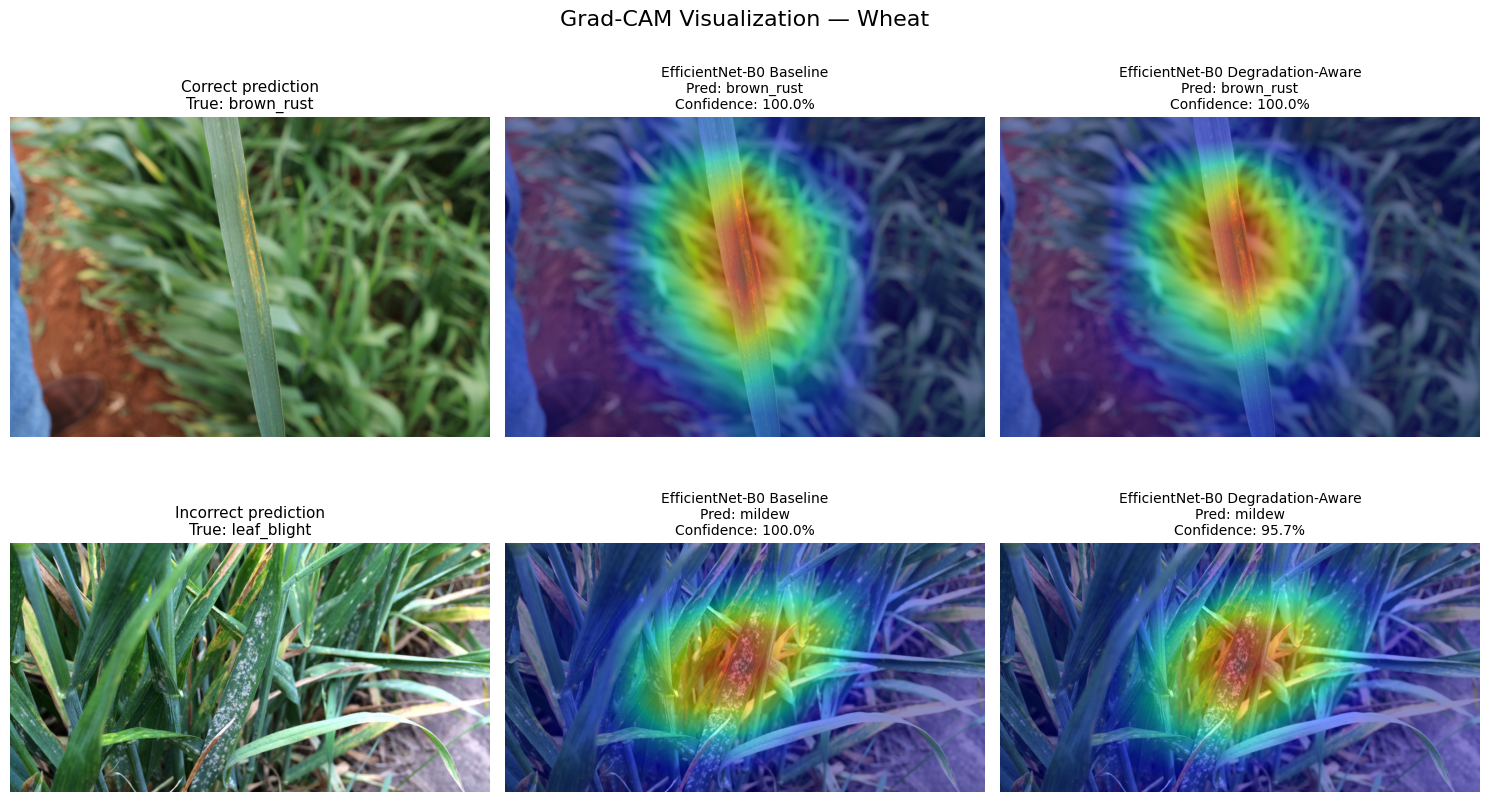


Saved: /kaggle/working/wheat_rice_journal/final_evaluation/paper_figures/Figure_8_Wheat_GradCAM.png
Saved: /kaggle/working/wheat_rice_journal/final_evaluation/paper_figures/Figure_8_Wheat_GradCAM.pdf


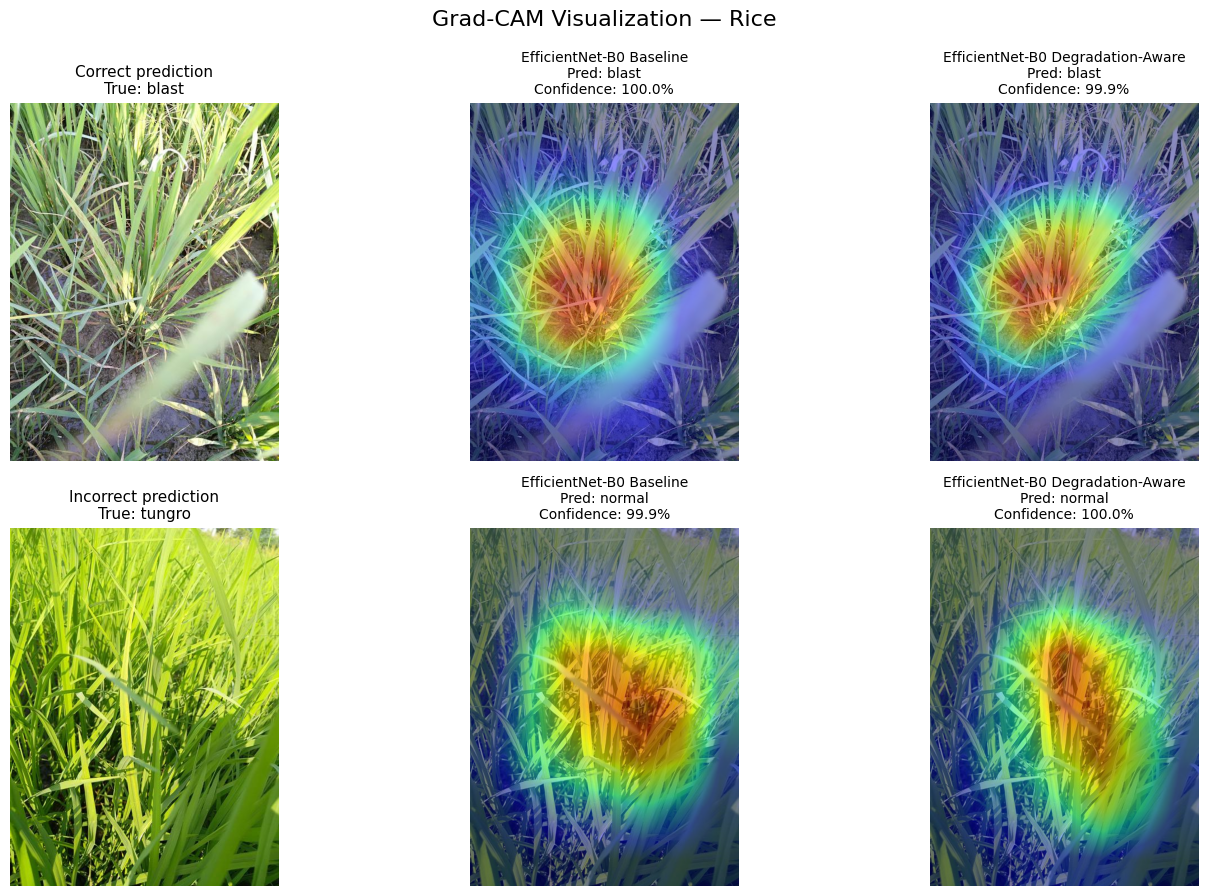


Saved: /kaggle/working/wheat_rice_journal/final_evaluation/paper_figures/Figure_8_Rice_GradCAM.png
Saved: /kaggle/working/wheat_rice_journal/final_evaluation/paper_figures/Figure_8_Rice_GradCAM.pdf

FIGURE 8 — GRAD-CAM COMPLETE


In [7]:
# ============================================================
# FIGURE 8 — GRAD-CAM EXPLAINABILITY
# Wheat + Rice
#
# EfficientNet-B0 Baseline vs Degradation-Aware
# 1 Correct + 1 Incorrect example per crop
#
# Uses RESTORED CHECKPOINTS
# ============================================================

from pathlib import Path
from collections.abc import Mapping
import json
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageOps

import torch
from torch import nn
from torchvision import models, transforms

# ------------------------------------------------------------
# DEVICE
# ------------------------------------------------------------
DEVICE = torch.device(
    "cuda:0" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------
ROOT = Path("/kaggle/working/wheat_rice_journal")

FIG_DIR = (
    ROOT
    / "final_evaluation"
    / "paper_figures"
)

XAI_DIR = (
    ROOT
    / "final_evaluation"
    / "xai"
)

FIG_DIR.mkdir(parents=True, exist_ok=True)
XAI_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# LOAD CLASS MAPS
# ============================================================

CLASS_MAPS_FILE = (
    ROOT
    / "data_audit"
    / "class_maps.json"
)

class_maps = json.loads(
    CLASS_MAPS_FILE.read_text()
)

# Reverse mapping
CLASS_NAMES = {}

for crop in ["wheat", "rice"]:
    CLASS_NAMES[crop] = {
        int(label_id): label
        for label, label_id in class_maps[crop].items()
    }


# ============================================================
# EVALUATION TRANSFORM
# Same 224x224 ImageNet normalization used in notebook
# ============================================================

evaluation_transform = transforms.Compose([
    transforms.Resize(
        256,
        interpolation=transforms.InterpolationMode.BILINEAR,
        antialias=True
    ),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# ============================================================
# MODEL FUNCTIONS
# Reproduced from notebook
# ============================================================

def extract_state_dict(checkpoint):

    if isinstance(checkpoint, Mapping):

        if checkpoint and all(
            torch.is_tensor(value)
            for value in checkpoint.values()
        ):
            state = checkpoint

        else:
            state = None

            for key in [
                "model_state_dict",
                "state_dict",
                "model",
                "model_state"
            ]:

                candidate = checkpoint.get(key)

                if (
                    isinstance(candidate, Mapping)
                    and candidate
                    and all(
                        torch.is_tensor(value)
                        for value in candidate.values()
                    )
                ):
                    state = candidate
                    break

            if state is None:
                raise RuntimeError(
                    "Unrecognised checkpoint structure. "
                    f"Keys: {list(checkpoint.keys())}"
                )

    else:
        raise RuntimeError(
            f"Unexpected checkpoint type: {type(checkpoint)}"
        )

    # DataParallel compatibility
    if all(key.startswith("module.") for key in state):
        state = {
            key.removeprefix("module."): value
            for key, value in state.items()
        }

    return state


def create_model(architecture, number_of_classes):

    if architecture == "torchvision_efficientnet_b0":

        model = models.efficientnet_b0(
            weights=None
        )

        model.classifier[1] = nn.Linear(
            model.classifier[1].in_features,
            number_of_classes
        )

    elif architecture == "torchvision_mobilenet_v2":

        model = models.mobilenet_v2(
            weights=None
        )

        model.classifier[1] = nn.Linear(
            model.classifier[1].in_features,
            number_of_classes
        )

    else:

        raise RuntimeError(
            f"Unsupported architecture: {architecture}"
        )

    return model


# ============================================================
# LOAD EFFICIENTNET CHECKPOINT
# ============================================================

def load_efficientnet(crop, experiment):

    run_name = (
        f"{crop}_{experiment}_seed42"
    )

    run_dir = (
        ROOT
        / "runs"
        / run_name
    )

    config_file = (
        run_dir
        / "config.json"
    )

    checkpoint_file = (
        run_dir
        / "best_model.pt"
    )

    if not config_file.exists():
        raise FileNotFoundError(
            f"Missing config:\n{config_file}"
        )

    if not checkpoint_file.exists():
        raise FileNotFoundError(
            f"Missing checkpoint:\n{checkpoint_file}"
        )

    config = json.loads(
        config_file.read_text()
    )

    checkpoint = torch.load(
        checkpoint_file,
        map_location="cpu",
        weights_only=False
    )

    state = extract_state_dict(
        checkpoint
    )

    model = create_model(
        config["architecture"],
        len(class_maps[crop])
    )

    model.load_state_dict(
        state,
        strict=True
    )

    model = model.to(DEVICE)
    model.eval()

    del checkpoint
    del state

    return model


# ============================================================
# LOAD TEST DATA
# ============================================================

def load_test_frame(crop):

    path = (
        ROOT
        / "splits"
        / f"{crop}_test.csv"
    )

    frame = pd.read_csv(path)

    required = {
        "path",
        "label",
        "label_id"
    }

    missing = required - set(frame.columns)

    if missing:
        raise RuntimeError(
            f"{crop}: missing columns {missing}"
        )

    return frame.reset_index(drop=True)


# ============================================================
# IMAGE LOADER
# ============================================================

def load_image(path):

    with Image.open(path) as source:

        image = (
            ImageOps
            .exif_transpose(source)
            .convert("RGB")
        )

    return image


# ============================================================
# PREDICT WHOLE TEST SET
# Used only to find correct + incorrect examples
# ============================================================

def predict_test_set(model, frame):

    predictions = []
    confidences = []

    model.eval()

    with torch.inference_mode():

        for start in range(
            0,
            len(frame),
            32
        ):

            batch_rows = frame.iloc[
                start:start + 32
            ]

            tensors = []

            for path in batch_rows["path"]:

                image = load_image(path)

                tensor = evaluation_transform(
                    image
                )

                tensors.append(tensor)

            images = torch.stack(
                tensors
            ).to(
                DEVICE,
                non_blocking=True
            )

            logits = model(images)

            probabilities = torch.softmax(
                logits,
                dim=1
            )

            conf, pred = probabilities.max(
                dim=1
            )

            predictions.extend(
                pred.cpu().numpy().tolist()
            )

            confidences.extend(
                conf.cpu().numpy().tolist()
            )

    return (
        np.array(predictions),
        np.array(confidences)
    )


# ============================================================
# GRAD-CAM
# EfficientNet-B0 final convolutional feature block
# ============================================================

def gradcam(
    model,
    image_path,
    target_class=None
):

    # Save activations and gradients
    activations = []
    gradients = []

    target_layer = model.features[-1]

    def forward_hook(module, inputs, output):

        activations.append(
            output
        )

        output.register_hook(
            lambda grad: gradients.append(
                grad
            )
        )

    handle = target_layer.register_forward_hook(
        forward_hook
    )

    try:

        original = load_image(
            image_path
        )

        input_tensor = (
            evaluation_transform(
                original
            )
            .unsqueeze(0)
            .to(DEVICE)
        )

        # Gradient is required
        model.zero_grad(
            set_to_none=True
        )

        output = model(
            input_tensor
        )

        probabilities = torch.softmax(
            output,
            dim=1
        )

        predicted_class = int(
            probabilities.argmax(dim=1).item()
        )

        confidence = float(
            probabilities[0, predicted_class].item()
        )

        if target_class is None:
            target_class = predicted_class

        score = output[
            0,
            target_class
        ]

        score.backward()

        activation = activations[0]
        gradient = gradients[0]

        # Global-average gradient weights
        weights = gradient.mean(
            dim=(2, 3),
            keepdim=True
        )

        cam = (
            weights * activation
        ).sum(
            dim=1,
            keepdim=True
        )

        cam = torch.relu(
            cam
        )

        cam = torch.nn.functional.interpolate(
            cam,
            size=original.size[::-1],
            mode="bilinear",
            align_corners=False
        )

        cam = cam[
            0,
            0
        ].detach().cpu().numpy()

        # Normalize
        cam -= cam.min()

        max_value = cam.max()

        if max_value > 0:
            cam /= max_value

        return (
            original,
            cam,
            predicted_class,
            confidence,
            target_class
        )

    finally:

        handle.remove()

        model.zero_grad(
            set_to_none=True
        )


# ============================================================
# OVERLAY CREATION
# ============================================================

def make_overlay(
    image,
    cam,
    alpha=0.45
):

    # Convert normalized CAM to 8-bit
    heat = np.uint8(
        np.clip(cam, 0, 1) * 255
    )

    # Use matplotlib's standard jet heatmap
    # only for the explanatory visualization.
    cmap = plt.get_cmap("jet")

    heat_rgba = cmap(
        heat / 255.0
    )

    heat_rgb = np.uint8(
        heat_rgba[:, :, :3] * 255
    )

    heat_image = Image.fromarray(
        heat_rgb
    ).convert("RGB")

    image = image.resize(
        heat_image.size
    )

    overlay = Image.blend(
        image,
        heat_image,
        alpha=alpha
    )

    return overlay


# ============================================================
# FIND ONE CORRECT + ONE INCORRECT EXAMPLE
# Based on EfficientNet-B0 Baseline
# ============================================================

selected = {}

for crop in ["wheat", "rice"]:

    print("\n" + "=" * 70)
    print(
        f"Finding Grad-CAM examples — {crop.upper()}"
    )
    print("=" * 70)

    frame = load_test_frame(
        crop
    )

    baseline = load_efficientnet(
        crop,
        "efficientnet_b0_baseline"
    )

    pred, conf = predict_test_set(
        baseline,
        frame
    )

    true = frame[
        "label_id"
    ].to_numpy(
        dtype=int
    )

    correct_indices = np.where(
        pred == true
    )[0]

    incorrect_indices = np.where(
        pred != true
    )[0]

    if len(correct_indices) == 0:
        raise RuntimeError(
            f"No correct example found for {crop}"
        )

    if len(incorrect_indices) == 0:
        raise RuntimeError(
            f"No incorrect example found for {crop}"
        )

    # Correct example:
    # choose highest-confidence correct prediction
    correct_idx = correct_indices[
        np.argmax(
            conf[correct_indices]
        )
    ]

    # Incorrect example:
    # choose highest-confidence incorrect prediction
    incorrect_idx = incorrect_indices[
        np.argmax(
            conf[incorrect_indices]
        )
    ]

    selected[crop] = {
        "correct_idx": int(correct_idx),
        "incorrect_idx": int(incorrect_idx)
    }

    print(
        "Correct example:",
        correct_idx,
        "| True:",
        CLASS_NAMES[crop][int(true[correct_idx])],
        "| Pred:",
        CLASS_NAMES[crop][int(pred[correct_idx])],
        "| Confidence:",
        f"{conf[correct_idx] * 100:.2f}%"
    )

    print(
        "Incorrect example:",
        incorrect_idx,
        "| True:",
        CLASS_NAMES[crop][int(true[incorrect_idx])],
        "| Pred:",
        CLASS_NAMES[crop][int(pred[incorrect_idx])],
        "| Confidence:",
        f"{conf[incorrect_idx] * 100:.2f}%"
    )

    del baseline
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


# ============================================================
# CREATE GRAD-CAM FIGURES
# ============================================================

def create_gradcam_figure(
    crop,
    frame,
    correct_idx,
    incorrect_idx
):

    baseline = load_efficientnet(
        crop,
        "efficientnet_b0_baseline"
    )

    degradation = load_efficientnet(
        crop,
        "efficientnet_b0_degradation"
    )

    examples = [
        ("Correct prediction", correct_idx),
        ("Incorrect prediction", incorrect_idx)
    ]

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(15, 9)
    )

    for row, (example_type, idx) in enumerate(
        examples
    ):

        image_path = frame.iloc[
            idx
        ]["path"]

        true_id = int(
            frame.iloc[idx]["label_id"]
        )

        true_name = CLASS_NAMES[
            crop
        ][true_id]

        # --------------------------------------------
        # Baseline Grad-CAM
        # --------------------------------------------
        (
            original_b,
            cam_b,
            pred_b,
            conf_b,
            _
        ) = gradcam(
            baseline,
            image_path
        )

        overlay_b = make_overlay(
            original_b,
            cam_b
        )

        # --------------------------------------------
        # Degradation-aware Grad-CAM
        # --------------------------------------------
        (
            original_d,
            cam_d,
            pred_d,
            conf_d,
            _
        ) = gradcam(
            degradation,
            image_path
        )

        overlay_d = make_overlay(
            original_d,
            cam_d
        )

        # --------------------------------------------
        # Original
        # --------------------------------------------
        axes[row, 0].imshow(
            original_b
        )

        axes[row, 0].axis("off")

        axes[row, 0].set_title(
            f"{example_type}\n"
            f"True: {true_name}",
            fontsize=11
        )

        # --------------------------------------------
        # Baseline Grad-CAM
        # --------------------------------------------
        axes[row, 1].imshow(
            overlay_b
        )

        axes[row, 1].axis("off")

        axes[row, 1].set_title(
            "EfficientNet-B0 Baseline\n"
            f"Pred: {CLASS_NAMES[crop][pred_b]}\n"
            f"Confidence: {conf_b * 100:.1f}%",
            fontsize=10
        )

        # --------------------------------------------
        # Degradation-aware Grad-CAM
        # --------------------------------------------
        axes[row, 2].imshow(
            overlay_d
        )

        axes[row, 2].axis("off")

        axes[row, 2].set_title(
            "EfficientNet-B0 Degradation-Aware\n"
            f"Pred: {CLASS_NAMES[crop][pred_d]}\n"
            f"Confidence: {conf_d * 100:.1f}%",
            fontsize=10
        )

    fig.suptitle(
        f"Grad-CAM Visualization — {crop.title()}",
        fontsize=16,
        y=0.99
    )

    plt.tight_layout()

    png_path = (
        FIG_DIR
        / f"Figure_8_{crop.title()}_GradCAM.png"
    )

    pdf_path = (
        FIG_DIR
        / f"Figure_8_{crop.title()}_GradCAM.pdf"
    )

    plt.savefig(
        png_path,
        dpi=600,
        bbox_inches="tight"
    )

    plt.savefig(
        pdf_path,
        bbox_inches="tight"
    )

    plt.show()

    plt.close(fig)

    print(
        "\nSaved:",
        png_path
    )

    print(
        "Saved:",
        pdf_path
    )

    del baseline
    del degradation

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


# ============================================================
# WHEAT
# ============================================================

wheat_frame = load_test_frame(
    "wheat"
)

create_gradcam_figure(
    "wheat",
    wheat_frame,
    selected["wheat"]["correct_idx"],
    selected["wheat"]["incorrect_idx"]
)


# ============================================================
# RICE
# ============================================================

rice_frame = load_test_frame(
    "rice"
)

create_gradcam_figure(
    "rice",
    rice_frame,
    selected["rice"]["correct_idx"],
    selected["rice"]["incorrect_idx"]
)


print("\n" + "=" * 75)
print("FIGURE 8 — GRAD-CAM COMPLETE")
print("=" * 75)

In [8]:
# ============================================================
# TABLE 7 — COMPUTATIONAL EFFICIENCY
# Parameters, FP32 model size, GPU inference time
# ============================================================

import os
import json
import time
import glob
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from torchvision import models, transforms
from PIL import Image, ImageOps

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

ROOT = "/kaggle/working/wheat_rice_journal"
RUNS_DIR = os.path.join(ROOT, "runs")
OUTPUT_DIR = os.path.join(ROOT, "final_evaluation", "paper_tables")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ------------------------------------------------------------
# 1. Model creation
# ------------------------------------------------------------

def create_model(architecture, number_of_classes):
    if architecture == "torchvision_efficientnet_b0":
        model = models.efficientnet_b0(weights=None)
        model.classifier[1] = nn.Linear(
            model.classifier[1].in_features,
            number_of_classes
        )

    elif architecture == "torchvision_mobilenet_v2":
        model = models.mobilenet_v2(weights=None)
        model.classifier[1] = nn.Linear(
            model.classifier[1].in_features,
            number_of_classes
        )

    else:
        raise ValueError(f"Unsupported architecture: {architecture}")

    return model


def extract_state_dict(checkpoint):
    if isinstance(checkpoint, dict):
        for key in [
            "model_state_dict",
            "state_dict",
            "model",
            "model_state"
        ]:
            if key in checkpoint and isinstance(checkpoint[key], dict):
                state = checkpoint[key]
                break
        else:
            state = checkpoint
    else:
        state = checkpoint

    # Remove DataParallel prefix if present
    state = {
        k.replace("module.", "", 1) if k.startswith("module.") else k: v
        for k, v in state.items()
    }

    return state


# ------------------------------------------------------------
# 2. Define the six restored models
# ------------------------------------------------------------

experiments = [
    {
        "crop": "Wheat",
        "model_name": "EfficientNet-B0 Baseline",
        "architecture": "torchvision_efficientnet_b0",
        "run_name": "wheat_efficientnet_b0_baseline_seed42"
    },
    {
        "crop": "Wheat",
        "model_name": "MobileNetV2 Baseline",
        "architecture": "torchvision_mobilenet_v2",
        "run_name": "wheat_mobilenet_v2_baseline_seed42"
    },
    {
        "crop": "Wheat",
        "model_name": "EfficientNet-B0 Degradation-Aware",
        "architecture": "torchvision_efficientnet_b0",
        "run_name": "wheat_efficientnet_b0_degradation_seed42"
    },
    {
        "crop": "Rice",
        "model_name": "EfficientNet-B0 Baseline",
        "architecture": "torchvision_efficientnet_b0",
        "run_name": "rice_efficientnet_b0_baseline_seed42"
    },
    {
        "crop": "Rice",
        "model_name": "MobileNetV2 Baseline",
        "architecture": "torchvision_mobilenet_v2",
        "run_name": "rice_mobilenet_v2_baseline_seed42"
    },
    {
        "crop": "Rice",
        "model_name": "EfficientNet-B0 Degradation-Aware",
        "architecture": "torchvision_efficientnet_b0",
        "run_name": "rice_efficientnet_b0_degradation_seed42"
    },
]


# ------------------------------------------------------------
# 3. Find checkpoint + number of classes
# ------------------------------------------------------------

results = []

for exp in experiments:

    run_dir = os.path.join(RUNS_DIR, exp["run_name"])
    checkpoint_path = os.path.join(run_dir, "best_model.pt")

    if not os.path.exists(checkpoint_path):
        print("MISSING:", checkpoint_path)
        continue

    # Look for config
    config_candidates = [
        os.path.join(run_dir, "config.json"),
        os.path.join(run_dir, "training_config.json"),
        os.path.join(run_dir, "experiment_config.json")
    ]

    config = None
    for c in config_candidates:
        if os.path.exists(c):
            with open(c, "r") as f:
                config = json.load(f)
            break

    # Determine number of classes from config where possible
    num_classes = None

    if isinstance(config, dict):
        for key in [
            "number_of_classes",
            "num_classes",
            "n_classes",
            "classes"
        ]:
            if key in config:
                value = config[key]
                if isinstance(value, list):
                    num_classes = len(value)
                elif isinstance(value, int):
                    num_classes = value
                break

    # Known class counts from the study
    if num_classes is None:
        num_classes = 15 if exp["crop"] == "Wheat" else 10

    # --------------------------------------------------------
    # Load checkpoint
    # --------------------------------------------------------

    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu"
    )

    state_dict = extract_state_dict(checkpoint)

    model = create_model(
        exp["architecture"],
        num_classes
    )

    model.load_state_dict(state_dict, strict=True)
    model = model.to(device)
    model.eval()

    # --------------------------------------------------------
    # Parameter count
    # --------------------------------------------------------

    total_params = sum(p.numel() for p in model.parameters())

    trainable_params = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    params_m = total_params / 1e6

    # FP32 architectural model size
    model_size_mb = (total_params * 4) / (1024 ** 2)

    # --------------------------------------------------------
    # Prepare a fixed batch
    # --------------------------------------------------------

    batch_size = 32

    x = torch.randn(
        batch_size,
        3,
        224,
        224,
        device=device
    )

    # --------------------------------------------------------
    # Warm-up
    # --------------------------------------------------------

    with torch.inference_mode():

        for _ in range(20):
            _ = model(x)

    if device.type == "cuda":
        torch.cuda.synchronize()

    # --------------------------------------------------------
    # Timed inference
    # --------------------------------------------------------

    repetitions = 100

    if device.type == "cuda":
        torch.cuda.synchronize()

    start = time.perf_counter()

    with torch.inference_mode():

        for _ in range(repetitions):
            _ = model(x)

    if device.type == "cuda":
        torch.cuda.synchronize()

    elapsed = time.perf_counter() - start

    total_images = repetitions * batch_size

    ms_per_image = (
        elapsed / total_images
    ) * 1000

    images_per_second = (
        total_images / elapsed
    )

    # --------------------------------------------------------
    # Peak GPU memory
    # --------------------------------------------------------

    peak_memory_mb = None

    if device.type == "cuda":

        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

        with torch.inference_mode():
            _ = model(x)

        torch.cuda.synchronize()

        peak_memory_mb = (
            torch.cuda.max_memory_allocated()
            / (1024 ** 2)
        )

    results.append({
        "Crop": exp["crop"],
        "Model": exp["model_name"],
        "Parameters (M)": round(params_m, 3),
        "Trainable Parameters (M)": round(trainable_params / 1e6, 3),
        "Model Size FP32 (MB)": round(model_size_mb, 2),
        "Inference Time (ms/image)": round(ms_per_image, 4),
        "Throughput (images/s)": round(images_per_second, 2),
        "Peak GPU Memory (MB)": (
            round(peak_memory_mb, 2)
            if peak_memory_mb is not None else None
        )
    })

    del model, x
    if device.type == "cuda":
        torch.cuda.empty_cache()


# ------------------------------------------------------------
# 4. Save results
# ------------------------------------------------------------

efficiency_df = pd.DataFrame(results)

csv_path = os.path.join(
    OUTPUT_DIR,
    "Table_7_Computational_Efficiency.csv"
)

efficiency_df.to_csv(
    csv_path,
    index=False
)

print("\n" + "=" * 80)
print("TABLE 7 — COMPUTATIONAL EFFICIENCY")
print("=" * 80)

display(efficiency_df)

print("\nSaved:")
print(csv_path)

Device: cuda
GPU: Tesla T4

TABLE 7 — COMPUTATIONAL EFFICIENCY


,Crop,Model,Parameters (M),Trainable Parameters (M),Model Size FP32 (MB),Inference Time (ms/image),Throughput (images/s),Peak GPU Memory (MB)
0,Wheat,EfficientNet-B0 Baseline,4.027,4.027,15.36,1.1253,888.65,373.04
1,Wheat,MobileNetV2 Baseline,2.243,2.243,8.56,0.8908,1122.61,366.44
2,Wheat,EfficientNet-B0 Degradation-Aware,4.027,4.027,15.36,1.1364,879.96,373.04
3,Rice,EfficientNet-B0 Baseline,4.020,4.020,15.34,1.1419,875.74,373.02
4,Rice,MobileNetV2 Baseline,2.237,2.237,8.53,0.9024,1108.22,366.42
5,Rice,EfficientNet-B0 Degradation-Aware,4.020,4.020,15.34,1.1546,866.11,373.02



Saved:
/kaggle/working/wheat_rice_journal/final_evaluation/paper_tables/Table_7_Computational_Efficiency.csv


In [10]:
# ============================================================
# CLOUD–EDGE DEPLOYMENT ANALYSIS
# Edge = CPU proxy
# Cloud = NVIDIA Tesla T4 GPU
# No retraining
# ============================================================

import os
import glob
import time
from io import BytesIO

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torchvision import models
from PIL import Image

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

ROOT = "/kaggle/working/wheat_rice_journal"
RUNS_DIR = os.path.join(ROOT, "runs")
OUT_DIR = os.path.join(ROOT, "final_evaluation", "paper_tables")
os.makedirs(OUT_DIR, exist_ok=True)

# ------------------------------------------------------------
# DEVICES
# ------------------------------------------------------------

cpu_device = torch.device("cpu")
gpu_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Edge proxy:", cpu_device)

if torch.cuda.is_available():
    print("Cloud proxy:", gpu_device)
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: CUDA GPU not available.")

# ------------------------------------------------------------
# MODEL CREATION
# ------------------------------------------------------------

def create_model(architecture, num_classes):

    if architecture == "torchvision_efficientnet_b0":
        model = models.efficientnet_b0(weights=None)
        model.classifier[1] = nn.Linear(
            model.classifier[1].in_features,
            num_classes
        )

    elif architecture == "torchvision_mobilenet_v2":
        model = models.mobilenet_v2(weights=None)
        model.classifier[1] = nn.Linear(
            model.classifier[1].in_features,
            num_classes
        )

    else:
        raise ValueError(f"Unsupported architecture: {architecture}")

    return model


def extract_state_dict(checkpoint):

    if isinstance(checkpoint, dict):

        for key in [
            "model_state_dict",
            "state_dict",
            "model",
            "model_state"
        ]:

            if key in checkpoint and isinstance(checkpoint[key], dict):
                checkpoint = checkpoint[key]
                break

    state_dict = {}

    for k, v in checkpoint.items():

        if k.startswith("module."):
            k = k.replace("module.", "", 1)

        state_dict[k] = v

    return state_dict


# ------------------------------------------------------------
# SIX MODELS
# ------------------------------------------------------------

experiments = [

    {
        "crop": "Wheat",
        "model": "EfficientNet-B0 Baseline",
        "arch": "torchvision_efficientnet_b0",
        "run": "wheat_efficientnet_b0_baseline_seed42",
        "classes": 15
    },

    {
        "crop": "Wheat",
        "model": "MobileNetV2 Baseline",
        "arch": "torchvision_mobilenet_v2",
        "run": "wheat_mobilenet_v2_baseline_seed42",
        "classes": 15
    },

    {
        "crop": "Wheat",
        "model": "EfficientNet-B0 Degradation-Aware",
        "arch": "torchvision_efficientnet_b0",
        "run": "wheat_efficientnet_b0_degradation_seed42",
        "classes": 15
    },

    {
        "crop": "Rice",
        "model": "EfficientNet-B0 Baseline",
        "arch": "torchvision_efficientnet_b0",
        "run": "rice_efficientnet_b0_baseline_seed42",
        "classes": 10
    },

    {
        "crop": "Rice",
        "model": "MobileNetV2 Baseline",
        "arch": "torchvision_mobilenet_v2",
        "run": "rice_mobilenet_v2_baseline_seed42",
        "classes": 10
    },

    {
        "crop": "Rice",
        "model": "EfficientNet-B0 Degradation-Aware",
        "arch": "torchvision_efficientnet_b0",
        "run": "rice_efficientnet_b0_degradation_seed42",
        "classes": 10
    }
]


# ------------------------------------------------------------
# BENCHMARK FUNCTION
# ------------------------------------------------------------

def benchmark_model(model, device, warmup=20, repetitions=100):

    model = model.to(device)
    model.eval()

    x = torch.randn(
        1,
        3,
        224,
        224,
        device=device
    )

    # Warm-up
    with torch.inference_mode():

        for _ in range(warmup):
            _ = model(x)

    if device.type == "cuda":
        torch.cuda.synchronize()

    start = time.perf_counter()

    with torch.inference_mode():

        for _ in range(repetitions):
            _ = model(x)

    if device.type == "cuda":
        torch.cuda.synchronize()

    elapsed = time.perf_counter() - start

    latency_ms = (
        elapsed / repetitions
    ) * 1000

    return latency_ms


# ------------------------------------------------------------
# FIND REPRESENTATIVE IMAGE FILES
# ------------------------------------------------------------

def find_images(crop, limit=100):

    possible_csvs = glob.glob(
        os.path.join(
            ROOT,
            "**",
            "*.csv"
        ),
        recursive=True
    )

    possible_columns = [
        "image_path",
        "path",
        "filepath",
        "file_path",
        "image",
        "filename",
        "file"
    ]

    found = []

    for csv_file in possible_csvs:

        try:
            df = pd.read_csv(
                csv_file,
                nrows=5000
            )
        except:
            continue

        selected_col = None

        for col in possible_columns:

            if col in df.columns:
                selected_col = col
                break

        if selected_col is None:
            continue

        for p in df[selected_col].dropna().astype(str):

            candidates = [
                p,
                os.path.join("/kaggle/input", p.lstrip("/"))
            ]

            for candidate in candidates:

                if os.path.exists(candidate):

                    if candidate.lower().endswith(
                        (".jpg", ".jpeg", ".png", ".webp")
                    ):

                        found.append(candidate)
                        break

            if len(found) >= limit:
                return list(dict.fromkeys(found))

    return list(dict.fromkeys(found))


# ------------------------------------------------------------
# JPEG PAYLOAD SIZE
# ------------------------------------------------------------

jpeg_payload = {}

for crop in ["Wheat", "Rice"]:

    image_paths = find_images(crop, limit=100)

    sizes = []

    for path in image_paths:

        try:

            with Image.open(path) as im:

                im = im.convert("RGB")

                buffer = BytesIO()

                im.save(
                    buffer,
                    format="JPEG",
                    quality=85,
                    optimize=True
                )

                size_kb = (
                    len(buffer.getvalue()) / 1024
                )

                sizes.append(size_kb)

        except:
            pass

    if sizes:

        jpeg_payload[crop] = float(np.mean(sizes))

        print(
            f"{crop}: {len(sizes)} images | "
            f"mean JPEG-85 size = "
            f"{jpeg_payload[crop]:.2f} KB"
        )

    else:

        jpeg_payload[crop] = np.nan

        print(
            f"{crop}: image size could not be measured."
        )


# ------------------------------------------------------------
# RUN BENCHMARK
# ------------------------------------------------------------

results = []

try:
    torch.set_num_threads(4)
except:
    pass


for exp in experiments:

    checkpoint_path = os.path.join(
        RUNS_DIR,
        exp["run"],
        "best_model.pt"
    )

    print("\n" + "=" * 80)
    print(exp["crop"], "|", exp["model"])

    if not os.path.exists(checkpoint_path):

        print("Checkpoint missing:")
        print(checkpoint_path)
        continue

    # Load checkpoint
    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu"
    )

    state_dict = extract_state_dict(checkpoint)

    # --------------------------------------------------------
    # CPU / EDGE
    # --------------------------------------------------------

    model_cpu = create_model(
        exp["arch"],
        exp["classes"]
    )

    model_cpu.load_state_dict(
        state_dict,
        strict=True
    )

    edge_latency = benchmark_model(
        model_cpu,
        cpu_device,
        warmup=10,
        repetitions=50
    )

    # --------------------------------------------------------
    # PARAMETERS
    # --------------------------------------------------------

    total_params = sum(
        p.numel()
        for p in model_cpu.parameters()
    )

    parameters_m = total_params / 1e6

    model_size_mb = (
        total_params * 4
    ) / (1024 ** 2)

    # --------------------------------------------------------
    # GPU / CLOUD
    # --------------------------------------------------------

    cloud_latency = np.nan

    if torch.cuda.is_available():

        model_gpu = create_model(
            exp["arch"],
            exp["classes"]
        )

        model_gpu.load_state_dict(
            state_dict,
            strict=True
        )

        cloud_latency = benchmark_model(
            model_gpu,
            gpu_device,
            warmup=20,
            repetitions=100
        )

        del model_gpu

        torch.cuda.empty_cache()

    # --------------------------------------------------------
    # UPLOAD ESTIMATES
    # --------------------------------------------------------

    size_kb = jpeg_payload.get(
        exp["crop"],
        np.nan
    )

    def upload_time(size_kb, bandwidth_mbps):

        if pd.isna(size_kb):
            return np.nan

        bits = (
            size_kb *
            1024 *
            8
        )

        seconds = (
            bits /
            (bandwidth_mbps * 1_000_000)
        )

        return seconds * 1000

    upload_5 = upload_time(
        size_kb,
        5
    )

    upload_10 = upload_time(
        size_kb,
        10
    )

    upload_20 = upload_time(
        size_kb,
        20
    )

    results.append({

        "Crop": exp["crop"],

        "Model": exp["model"],

        "Parameters (M)": round(
            parameters_m,
            3
        ),

        "Model Size FP32 (MB)": round(
            model_size_mb,
            2
        ),

        "Edge Proxy CPU (ms/image)": round(
            edge_latency,
            3
        ),

        "Cloud Tesla T4 (ms/image)": (
            round(cloud_latency, 3)
            if not pd.isna(cloud_latency)
            else np.nan
        ),

        "Mean JPEG-85 Payload (KB)": (
            round(size_kb, 2)
            if not pd.isna(size_kb)
            else np.nan
        ),

        "Estimated Upload @5 Mbps (ms)": (
            round(upload_5, 2)
            if not pd.isna(upload_5)
            else np.nan
        ),

        "Estimated Upload @10 Mbps (ms)": (
            round(upload_10, 2)
            if not pd.isna(upload_10)
            else np.nan
        ),

        "Estimated Upload @20 Mbps (ms)": (
            round(upload_20, 2)
            if not pd.isna(upload_20)
            else np.nan
        )
    })

    del model_cpu


# ------------------------------------------------------------
# SAVE TABLE
# ------------------------------------------------------------

cloud_edge_df = pd.DataFrame(results)

output_csv = os.path.join(
    OUT_DIR,
    "Table_8_Cloud_Edge_Deployment_Analysis.csv"
)

cloud_edge_df.to_csv(
    output_csv,
    index=False
)

print("\n")
print("=" * 100)
print("TABLE 8 — CLOUD–EDGE DEPLOYMENT ANALYSIS")
print("=" * 100)

display(cloud_edge_df)

print("\nSaved:")
print(output_csv)

print("\nIMPORTANT:")
print("CPU = edge proxy measurement.")
print("Tesla T4 = cloud/GPU proxy measurement.")
print("Upload times = calculated from measured JPEG payload size.")
print("No model retraining was performed.")

Edge proxy: cpu
Cloud proxy: cuda
GPU: Tesla T4
Wheat: 100 images | mean JPEG-85 size = 208.07 KB
Rice: 100 images | mean JPEG-85 size = 208.07 KB

Wheat | EfficientNet-B0 Baseline

Wheat | MobileNetV2 Baseline

Wheat | EfficientNet-B0 Degradation-Aware

Rice | EfficientNet-B0 Baseline

Rice | MobileNetV2 Baseline

Rice | EfficientNet-B0 Degradation-Aware


TABLE 8 — CLOUD–EDGE DEPLOYMENT ANALYSIS


,Crop,Model,Parameters (M),Model Size FP32 (MB),Edge Proxy CPU (ms/image),Cloud Tesla T4 (ms/image),Mean JPEG-85 Payload (KB),Estimated Upload @5 Mbps (ms),Estimated Upload @10 Mbps (ms),Estimated Upload @20 Mbps (ms)
0,Wheat,EfficientNet-B0 Baseline,4.027,15.36,33.005,7.862,208.07,340.89,170.45,85.22
1,Wheat,MobileNetV2 Baseline,2.243,8.56,27.368,5.013,208.07,340.89,170.45,85.22
2,Wheat,EfficientNet-B0 Degradation-Aware,4.027,15.36,32.545,7.742,208.07,340.89,170.45,85.22
3,Rice,EfficientNet-B0 Baseline,4.020,15.34,32.028,7.979,208.07,340.89,170.45,85.22
4,Rice,MobileNetV2 Baseline,2.237,8.53,24.871,5.328,208.07,340.89,170.45,85.22
5,Rice,EfficientNet-B0 Degradation-Aware,4.020,15.34,32.843,7.868,208.07,340.89,170.45,85.22



Saved:
/kaggle/working/wheat_rice_journal/final_evaluation/paper_tables/Table_8_Cloud_Edge_Deployment_Analysis.csv

IMPORTANT:
CPU = edge proxy measurement.
Tesla T4 = cloud/GPU proxy measurement.
Upload times = calculated from measured JPEG payload size.
No model retraining was performed.


In [1]:
from PIL import Image, ImageOps, ImageDraw
from pathlib import Path
import zipfile, io, os

zip_path = Path("/mnt/data/grpahs.zip")
out_dir = Path("/mnt/data/final_figures")
out_dir.mkdir(exist_ok=True)

def get_img(z, name):
    with zipfile.ZipFile(z) as f:
        return Image.open(io.BytesIO(f.read(name))).convert("RGB")

def make_two_panel(left, right, out_png, out_pdf, panel_gap=120, top_label=True):
    # Normalize heights while preserving aspect ratios
    target_h = min(left.height, right.height)
    def resize_h(im, h):
        return im.resize((round(im.width * h / im.height), h), Image.Resampling.LANCZOS)

    left_r = resize_h(left, target_h)
    right_r = resize_h(right, target_h)

    label_h = 90 if top_label else 0
    canvas_w = left_r.width + panel_gap + right_r.width
    canvas_h = target_h + label_h

    canvas = Image.new("RGB", (canvas_w, canvas_h), "white")
    canvas.paste(left_r, (0, label_h))
    canvas.paste(right_r, (left_r.width + panel_gap, label_h))

    if top_label:
        draw = ImageDraw.Draw(canvas)
        # Large, simple panel labels
        draw.text((20, 20), "(a) Wheat", fill="black")
        draw.text((left_r.width + panel_gap + 20, 20), "(b) Rice", fill="black")

    canvas.save(out_png, dpi=(300, 300))
    # Single-page PDF suitable for manuscript insertion
    canvas.save(out_pdf, "PDF", resolution=300.0)
    return canvas.size

# Figure 4 — Brightness
wheat = get_img(zip_path, "grpahs/wheat_brightness_macro_f1.png")
rice = get_img(zip_path, "grpahs/rice_brightness_macro_f1.png")
size4 = make_two_panel(
    wheat, rice,
    out_dir / "Figure_4_Brightness_Robustness.png",
    out_dir / "Figure_4_Brightness_Robustness.pdf"
)

# Figure 5 — JPEG
wheat = get_img(zip_path, "grpahs/wheat_jpeg_macro_f1.png")
rice = get_img(zip_path, "grpahs/rice_jpeg_macro_f1.png")
size5 = make_two_panel(
    wheat, rice,
    out_dir / "Figure_5_JPEG_Compression_Robustness.png",
    out_dir / "Figure_5_JPEG_Compression_Robustness.pdf"
)

# Figure 6 — Severe degradation performance drop
wheat = get_img(zip_path, "grpahs/wheat_severe_degradation_drop.png")
rice = get_img(zip_path, "grpahs/rice_severe_degradation_drop.png")
size6 = make_two_panel(
    wheat, rice,
    out_dir / "Figure_6_Severe_Degradation_Drop.png",
    out_dir / "Figure_6_Severe_Degradation_Drop.pdf"
)

# Figure 7 — Class-wise F1 (existing high-resolution figures)
wheat = get_img(zip_path, "grpahs/Figure_6A_Wheat_Classwise_F1.png")
rice = get_img(zip_path, "grpahs/Figure_6B_Rice_Classwise_F1.png")
size7 = make_two_panel(
    wheat, rice,
    out_dir / "Figure_7_Classwise_F1_Wheat_Rice.png",
    out_dir / "Figure_7_Classwise_F1_Wheat_Rice.pdf"
)

print("Created final combined figures:")
for p in sorted(out_dir.iterdir()):
    print(f"- {p}")


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data/final_figures'